# **SETUP**
Install library dan import semua yang dibutuhkan.

In [ ]:
!pip uninstall numpy -y -q

In [ ]:
!pip install numpy==1.26.4 -q
!pip install geopandas osmnx pyproj shapely openpyxl scikit-learn-extra -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 85.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is 

In [ ]:
!pip install numpy==1.26.4 pandas==2.2.2 --force-reinstall --no-cache-dir

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 93.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.1/510.1 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 23.8 MB/s eta 0:00:00
  Attempting uninstall: pytz
    Found existing installation: pytz 2025.2
    Uninstalling pytz-2025.2:
      Successfully uninstalled pytz-2025.2
  Attempting uninstall: tzdata
    Found existing installation: tzdata 2026.1
    Uninstalling tzdata-2026.1:
      Successfully uninstalled tzdata-2026.1
  Attempting uninstall: six
    Found existing installation: six 1.17.0
    Uninstalling six-1.17.0:
      Successfully uninstalled six-1.17.0
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.

In [ ]:
import re
import os
import time
import pickle
import warnings
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
from pyproj import Transformer
from shapely.geometry import LineString
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score

from google.colab import files

warnings.filterwarnings('ignore')
os.makedirs('models', exist_ok=True)

# **EXTRACT**

## **Parse SK Jalan**

**Input** : File teks SK Walikota Semarang No. 621/490 Tahun 2016  
**Output** : `df_sk` berisi 1012 baris, berisi nama jalan, kecamatan, dimensi, koordinat UTM, dan fungsi jalan  


In [ ]:
# Upload file SK
uploaded = files.upload()
SK_FILE  = list(uploaded.keys())[0]
print(f'\nFile terupload: {SK_FILE}')

Saving Sk-Jalan-Kota-Semarang-1012.txt to Sk-Jalan-Kota-Semarang-1012.txt

File terupload: Sk-Jalan-Kota-Semarang-1012.txt


In [ ]:
# Parse baris per baris dengan regex
PATTERN = re.compile(
    r'^\d+\s+[\d\.]+\s+Jl\.\s+(.+?)\s{2,}'
    r'(Semarang\s+\w+|Gajahmungkur|Gunungpati|Banyumanik|'
    r'Candisari|Gayamsari|Genuk|Mijen|Ngaliyan|Pedurungan|Tembalang|Tugu)\s+'
    r'([\d,\.]+)\s+([\d,\.]+)\s+'
    r'([\d,\.]+)\s+([\d,\.]+)\s+'
    r'([\d,\.]+)\s+([\d,\.]+)\s+'
    r'(Arteri Primer|Arteri Sekunder|Kolektor Primer|Kolektor Sekunder|Lokal Primer|Lokal Sekunder)'
)

def parse_angka(s):
    """Konversi string angka format Indonesia ke float."""
    return float(s.replace('.', '').replace(',', '.'))

rows = []
with open(SK_FILE, 'r', errors='ignore') as f:
    for line in f:
        m = PATTERN.match(line.strip())
        if m:
            rows.append({
                'nama_jalan'  : 'Jl. ' + m.group(1).strip(),
                'kecamatan'   : re.sub(r'\s+', ' ', m.group(2)).strip(),
                'panjang_m'   : parse_angka(m.group(3)),
                'lebar_m'     : parse_angka(m.group(4)),
                'x1_utm'      : parse_angka(m.group(5)),
                'y1_utm'      : parse_angka(m.group(6)),
                'x2_utm'      : parse_angka(m.group(7)),
                'y2_utm'      : parse_angka(m.group(8)),
                'fungsi_jalan': m.group(9),
            })

df_sk = pd.DataFrame(rows)

In [ ]:
# Ringkasan
print(f'Hasil parse: {len(df_sk)} ruas jalan')
print(f'\nDistribusi fungsi jalan:')
print(df_sk['fungsi_jalan'].value_counts().to_string())
print(f'\nKecamatan ({df_sk["kecamatan"].nunique()} kecamatan):')
print(df_sk['kecamatan'].value_counts().to_string())
df_sk

Hasil parse: 1012 ruas jalan

Distribusi fungsi jalan:
fungsi_jalan
Kolektor Sekunder    825
Lokal Primer         107
Arteri Sekunder       60
Kolektor Primer       19
Arteri Primer          1

Kecamatan (16 kecamatan):
kecamatan
Tembalang           134
Banyumanik          112
Pedurungan          100
Semarang Tengah      95
Semarang Selatan     86
Semarang Barat       82
Semarang Utara       60
Gunungpati           56
Semarang Timur       46
Ngaliyan             44
Genuk                42
Gajahmungkur         41
Mijen                40
Gayamsari            29
Candisari            29
Tugu                 16


,nama_jalan,kecamatan,panjang_m,lebar_m,x1_utm,y1_utm,x2_utm,y2_utm,fungsi_jalan
0,Jl. Abimanyu,Semarang Tengah,240.40,4.0,434880.92280,9.228610e+06,434750.03976,9.228805e+06,Kolektor Sekunder
1,Jl. Ade Irma Suryani Nasution,Semarang Tengah,529.71,7.0,435363.09059,9.228976e+06,435447.45040,9.229021e+06,Lokal Primer
2,Jl. Alun-Alun Barat,Semarang Tengah,216.76,3.0,436280.68684,9.229236e+06,436349.16460,9.229387e+06,Kolektor Sekunder
3,Jl. Alun-Alun Timur,Semarang Tengah,168.21,10.0,436421.98226,9.229382e+06,436370.30127,9.229516e+06,Kolektor Sekunder
4,Jl. Anggrek,Semarang Tengah,338.87,5.5,436242.55732,9.227506e+06,436471.70676,9.227370e+06,Lokal Primer
...,...,...,...,...,...,...,...,...,...
1007,Jl. Pulau Tirang Tapak,Tugu,2029.33,3.0,427538.71739,9.228537e+06,428027.78487,9.230366e+06,Lokal Primer
1008,Jl. Stasiun Jraka,Tugu,706.21,3.5,429528.11729,9.227662e+06,429766.56212,9.228316e+06,Lokal Primer
1009,Jl. Stasiun Mangkang,Tugu,253.06,3.5,423082.82064,9.229153e+06,423195.06570,9.229373e+06,Kolektor Primer
1010,Jl. Tapak,Tugu,864.77,4.0,427750.61099,9.227775e+06,427538.71739,9.228537e+06,Lokal Primer


## **Konversi Koordinat UTM ke Latitude dan Longitude**

**Input** : `df_sk` dengan koordinat UTM

**Output** : `gdf_jalan` (GeoDataFrame dengan geometri LineString per ruas jalan)

In [ ]:
transformer = Transformer.from_crs('EPSG:32749', 'EPSG:4326', always_xy=True)

def utm_to_latlon(x, y):
    lon, lat = transformer.transform(x, y)
    return lat, lon

df_sk[['lat1', 'lon1']] = df_sk.apply(
    lambda r: pd.Series(utm_to_latlon(r.x1_utm, r.y1_utm)), axis=1
)
df_sk[['lat2', 'lon2']] = df_sk.apply(
    lambda r: pd.Series(utm_to_latlon(r.x2_utm, r.y2_utm)), axis=1
)

df_sk['geometry'] = df_sk.apply(
    lambda r: LineString([(r.lon1, r.lat1), (r.lon2, r.lat2)]), axis=1
)

# Buat GeoDataFrame
gdf_jalan = gpd.GeoDataFrame(df_sk, geometry='geometry', crs='EPSG:4326')

# Hitung centroid tiap ruas jalan
gdf_jalan['centroid']     = gdf_jalan.geometry.centroid
gdf_jalan['lat_centroid'] = gdf_jalan['centroid'].y
gdf_jalan['lng_centroid'] = gdf_jalan['centroid'].x

print(f'Geometri dibuat: {len(gdf_jalan)} LineString')
print(f'\nContoh koordinat ruas pertama:')
print(f'  Titik awal  : ({gdf_jalan.lat1.iloc[0]:.14f}, {gdf_jalan.lon1.iloc[0]:.14f})')
print(f'  Titik akhir : ({gdf_jalan.lat2.iloc[0]:.14f}, {gdf_jalan.lon2.iloc[0]:.14f})')
print(f'  Centroid    : ({gdf_jalan.lat_centroid.iloc[0]:.14f}, {gdf_jalan.lng_centroid.iloc[0]:.14f})')

Geometri dibuat: 1012 LineString

Contoh koordinat ruas pertama:
  Titik awal  : (-6.97829747054884, 110.41046314925647)
  Titik akhir : (-6.97653047236209, 110.40928049319346)
  Centroid    : (-6.97741397145546, 110.40987182122497)


In [ ]:
df_sk.to_excel('df_sk.xlsx', index=False)

## **Spatial Join Nama Kelurahan**

**Input** : Centroid tiap ruas jalan + polygon batas kelurahan Semarang  
**Output** : Kolom `kelurahan` terisi di `gdf_jalan`  
**Metode** : Centroid jalan di-assign ke kelurahan di mana titik tengahnya berada  
**Catatan** : Untuk jalan yang melintasi >1 kelurahan, digunakan kelurahan tempat centroid jatuh

In [ ]:
try:
    # Gunakan level ADM4 untuk Kelurahan/Desa
    URL_GEO = 'https://github.com/wmgeolab/geoBoundaries/raw/main/releaseData/gbOpen/IDN/ADM4/geoBoundaries-IDN-ADM4.geojson'
    resp = requests.get(URL_GEO, timeout=120)
    gdf_idn = gpd.read_file(BytesIO(resp.content))

    # Filter hanya untuk Kota Semarang
    gdf_kel = gdf_idn[gdf_idn['shapeGroup'] == 'IDN'].copy() # Filter dasar

    # Untuk ADM4, shapeName adalah nama Kelurahan
    gdf_kel = gdf_idn[gdf_idn['shapeName'].str.contains('Semarang', case=False, na=False)].to_crs('EPSG:4326')
    gdf_kel = gdf_kel.rename(columns={'shapeName': 'kelurahan'})[['kelurahan', 'geometry']]

except Exception as e:
    # Menggunakan OSM, ubah admin_level menjadi 8 untuk Kelurahan
    gdf_kel = ox.features_from_place(
        'Kota Semarang, Indonesia',
        tags={'admin_level': '8', 'boundary': 'administrative'}
    ).to_crs('EPSG:4326')
    gdf_kel = gdf_kel.rename(columns={'name': 'kelurahan'})[['kelurahan', 'geometry']]

In [ ]:
# Download polygon kelurahan dari GeoBoundaries
try:
    URL_GEO = (
        'https://github.com/wmgeolab/geoBoundaries/raw/main/'
        'releaseData/gbOpen/IDN/ADM4/geoBoundaries-IDN-ADM4.geojson'
    )
    resp = requests.get(URL_GEO, timeout=120)
    gdf_idn = gpd.read_file(BytesIO(resp.content))

    # Filter hanya Kota Semarang
    gdf_kel = (
        gdf_idn[gdf_idn['shapeName']
        .str.contains('Semarang', case=False, na=False)]
        .copy()
        .to_crs('EPSG:4326')
        .rename(columns={'shapeName': 'kelurahan'})
        [['kelurahan', 'geometry']]
    )
    print(f'GeoBoundaries berhasil: {len(gdf_kel)} kelurahan')

except Exception as e:
    # Fallback: OSM via osmnx
    print(f'GeoBoundaries gagal ({e}), mencoba OSM...')
    gdf_kel = ox.features_from_place(
        'Kota Semarang, Jawa Tengah, Indonesia',
        tags={'admin_level': '7', 'boundary': 'administrative'}
    ).to_crs('EPSG:4326')
    gdf_kel = gdf_kel.rename(columns={'name': 'kelurahan'})[['kelurahan', 'geometry']]
    print(f'OSM fallback: {len(gdf_kel)} kelurahan')

GeoBoundaries gagal (name 'BytesIO' is not defined), mencoba OSM...
OSM fallback: 6359 kelurahan


In [ ]:
# Spatial join: centroid jalan ke polygon kelurahan
gdf_centroid = gdf_jalan.set_geometry('centroid').copy()

gdf_joined = gpd.sjoin(
    gdf_centroid[['nama_jalan', 'centroid']],
    gdf_kel,
    how='left',
    predicate='within'
)

kelurahan_map = gdf_joined.groupby('nama_jalan')['kelurahan'].first()

# Assign ke gdf_jalan
gdf_jalan['kelurahan'] = gdf_jalan['nama_jalan'].map(kelurahan_map)

ter_assign = gdf_jalan['kelurahan'].notna().sum()
tidak_assign = gdf_jalan['kelurahan'].isna().sum()

print(f'Ter-assign kelurahan : {ter_assign} ruas ({ter_assign/len(gdf_jalan)*100:.1f}%)')
print(f'Tidak ter-assign     : {tidak_assign} ruas')

if tidak_assign > 0:
    print(f'\n   Jalan tidak ter-assign (centroid di luar polygon kelurahan):')
    print(gdf_jalan[gdf_jalan['kelurahan'].isna()][['nama_jalan','kecamatan']].to_string())

Ter-assign kelurahan : 1012 ruas (100.0%)
Tidak ter-assign     : 0 ruas


## **Scraping POI dari OSM**

**Variabel yang di-scraping:**
- 12 kompetitor (cafe, fnb, laundry, gym, fashion, stationery, carwash, photostudio, barbershop, salon, bengkel, elektronik)
- 6 demand/POI (university, college, school, office, mall, hospital)
- 4 transit (bus stop, bus station, train station, public transport)

In [ ]:
TAGS_POI = {

    # Kompetitor
    'competitor_cafe'       : {'amenity': ['cafe']},
    'competitor_fnb'        : {'amenity': ['restaurant', 'fast_food', 'food_court']},
    'competitor_laundry'    : {'shop': ['laundry', 'dry_cleaning']},
    'competitor_gym'        : {'leisure': ['fitness_centre', 'sports_centre']},
    'competitor_fashion'    : {'shop': ['clothes', 'fashion', 'boutique']},
    'competitor_stationery' : {'shop': 'stationery'},
    'competitor_carwash'    : {'amenity': 'car_wash'},
    'competitor_photostudio': {'shop': ['photo', 'photo_studio']},
    'competitor_barbershop' : {'shop': ['barber', 'hairdresser']},
    'competitor_salon'      : {'shop': ['beauty', 'nail_salon']},
    'competitor_bengkel'    : {'shop': ['car_repair', 'motorcycle_repair', 'vehicle']},
    'competitor_elektronik' : {'shop': ['electronics', 'computer', 'mobile_phone']},

    # Demand
    'demand_university'     : {'amenity': 'university'},
    'demand_college'        : {'amenity': 'college'},
    'demand_school'         : {'amenity': 'school'},
    'demand_office'         : {'office': True},
    'demand_mall'           : {'shop': 'mall'},
    'demand_hospital'       : {'amenity': ['hospital', 'clinic']},

    # Transit
    'transit_bus_stop'         : {'highway': 'bus_stop'},
    'transit_bus_station'      : {'amenity': 'bus_station'},
    'transit_train_station'    : {'railway': ['station', 'halt']},
    'transit_public_transport' : {'public_transport': 'stop_position'},
}

POI_COLS = list(TAGS_POI.keys())
print(f'Total variabel POI: {len(POI_COLS)}')
print(f'  Kompetitor : {len([c for c in POI_COLS if c.startswith("competitor")])}')
print(f'  Demand     : {len([c for c in POI_COLS if c.startswith("demand")])}')
print(f'  Transit    : {len([c for c in POI_COLS if c.startswith("transit")])}')

Total variabel POI: 22
  Kompetitor : 12
  Demand     : 6
  Transit    : 4


In [ ]:
PLACE = 'Kota Semarang, Jawa Tengah, Indonesia'

print(f'Scraping POI dari OSM untuk: {PLACE}')

all_poi = []

for variabel, tags in TAGS_POI.items():
    try:
        gdf = ox.features_from_place(PLACE, tags=tags)

        # Untuk polygon/bangunan, ambil centroidnya
        gdf = gdf[gdf.geometry.geom_type.isin(
            ['Point', 'Polygon', 'MultiPolygon']
        )].copy()
        gdf['geometry'] = gdf.geometry.apply(
            lambda g: g.centroid if g.geom_type != 'Point' else g
        )

        gdf = gdf[['geometry']].copy()
        gdf['variabel'] = variabel
        all_poi.append(gdf)
        print(f' {variabel:35s}: {len(gdf):5,} POI')

    except Exception:
        print(f' {variabel:35s}: tidak ada data di OSM')

    time.sleep(1)

# Gabung semua POI
gdf_poi_all = gpd.GeoDataFrame(
    pd.concat(all_poi, ignore_index=True),
    geometry='geometry',
    crs='EPSG:4326'
)

print('─' * 55)
print(f'Total seluruh POI Kota Semarang: {len(gdf_poi_all):,}')

Scraping POI dari OSM untuk: Kota Semarang, Jawa Tengah, Indonesia
 competitor_cafe                    :    72 POI
 competitor_fnb                     :   342 POI
 competitor_laundry                 :    16 POI
 competitor_gym                     :    38 POI
 competitor_fashion                 :    21 POI
 competitor_stationery              :     9 POI
 competitor_carwash                 :     3 POI
 competitor_photostudio             :     2 POI
 competitor_barbershop              :    37 POI
 competitor_salon                   :    30 POI
 competitor_bengkel                 :    32 POI
 competitor_elektronik              :    23 POI
 demand_university                  :    44 POI
 demand_college                     :    51 POI
 demand_school                      :   910 POI
 demand_office                      :   878 POI
 demand_mall                        :    16 POI
 demand_hospital                    :   593 POI
 transit_bus_stop                   :   258 POI
 transit_bus_station 

## **Hitung POI per Ruas Jalan**

**Metode**: Setiap ruas jalan (berbentuk garis/LineString) diperlebar sejauh 30m ke kiri dan kanan membentuk polygon buffer. Kemudian setiap titik POI yang koordinatnya jatuh di dalam polygon buffer tersebut dihitung sebagai POI yang berada di ruas jalan itu (Spatial join).

**Kenapa 30m?** POI yang secara alamat berada di suatu jalan, koordinatnya tidak tepat di atas garis jalan, melainkan offset ke bangunan di pinggir jalan sejauh 15–30m.

In [ ]:
BUFFER_M = 30  # meter

# Proyeksi ke UTM untuk buffer dalam satuan meter
gdf_jalan_utm = gdf_jalan.set_geometry('geometry').to_crs('EPSG:32749').copy()
gdf_poi_utm   = gdf_poi_all.to_crs('EPSG:32749').copy()

# Buat buffer di kiri-kanan garis jalan
gdf_jalan_utm['buffer_30m'] = gdf_jalan_utm.geometry.buffer(BUFFER_M)

# Spatial join
joined = gpd.sjoin(
    gdf_poi_utm,
    gdf_jalan_utm.set_geometry('buffer_30m')[['nama_jalan', 'buffer_30m']],
    how='inner',
    predicate='within'
)

# Pivot jumlah per variabel per jalan
poi_count = (
    joined
    .groupby(['nama_jalan', 'variabel'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

for col in POI_COLS:
    if col not in poi_count.columns:
        poi_count[col] = 0
poi_count = poi_count[['nama_jalan'] + POI_COLS]

print(f'Jalan dengan minimal 1 POI : {len(poi_count)}')
print(f'Jalan tanpa POI sama sekali: {len(gdf_jalan) - len(poi_count)}')

Jalan dengan minimal 1 POI : 473
Jalan tanpa POI sama sekali: 539


In [ ]:
# Ambil wilayah level 7 & 8 (Kelurahan)
gdf_wilayah = ox.features_from_place(
    "Kota Semarang, Indonesia",
    tags={"admin_level": ["7", "8"], "boundary": "administrative"}
)

# Buang objek yang bukan kelurahan resmi
blacklist = [
    'Taman', 'Universitas', 'Kawasan', 'Industri', 'Lahan', 'Perkebunan',
    'Komplek', 'Pergudangan', 'Kampus', 'Mall', 'Bandara', 'Pelabuhan',
    'Jawa Tengah', 'Semarang', 'RW', 'RT', 'Dusun'
]

pattern_blacklist = '|'.join(blacklist)

gdf_kel = gdf_wilayah[
    (gdf_wilayah.index.get_level_values(0) == 'relation') &
    (~gdf_wilayah['name'].str.contains(r'\d', na=False)) & # Buang yang ada angka
    (~gdf_wilayah['name'].str.contains(pattern_blacklist, case=False, na=False))
].copy()

gdf_kel = gdf_kel[['name', 'geometry']].reset_index(drop=True)
gdf_kel = gdf_kel.rename(columns={'name': 'kelurahan'})
gdf_kel = gdf_kel.to_crs("EPSG:4326")

print(f"Filter {len(gdf_kel)} poligon Kelurahan resmi.")

if 'kelurahan' in gdf_jalan.columns:
    gdf_jalan = gdf_jalan.drop(columns=['kelurahan'])

# Spatial Join Kelurahan dengan Centroid
gdf_centroid = gdf_jalan.set_geometry('centroid').copy()
gdf_joined = gpd.sjoin(gdf_centroid, gdf_kel, how='left', predicate='within')

# Atasi Duplikat
gdf_joined_clean = gdf_joined.groupby(gdf_joined.index).first()

# Masukkan ke dataframe utama
gdf_jalan['kelurahan'] = gdf_joined_clean['kelurahan']

print(gdf_jalan[['nama_jalan', 'kelurahan']].head(10))

print("\nTop 5 Kelurahan terbanyak:")
print(gdf_jalan['kelurahan'].value_counts().head(5))

Filter 207 poligon Kelurahan resmi.
                      nama_jalan        kelurahan
0                   Jl. Abimanyu    Pendrikan Lor
1  Jl. Ade Irma Suryani Nasution           Sekayu
2            Jl. Alun-Alun Barat           Kauman
3            Jl. Alun-Alun Timur           Kauman
4                    Jl. Anggrek         Pekunden
5         Jl. Arief Rahman Hakim      Bangunharjo
6                     Jl. Arjuna  Pendrikan Kidul
7              Jl. Batan Selatan           Miroto
8                    Jl. Bedagan           Sekayu
9                   Jl. Beringin           Sekayu

Top 5 Kelurahan terbanyak:
kelurahan
Pedalangan         22
Ngaliyan           20
Tlogosari Kulon    20
Srondol Wetan      19
Sumurboto          19
Name: count, dtype: int64


In [ ]:
# Gabungkan SK dan POI ke df_jalan
SK_COLS = [
    'nama_jalan', 'kecamatan', 'kelurahan',
    'lat_centroid', 'lng_centroid',
    'fungsi_jalan', 'panjang_m', 'lebar_m',
    ]

df_jalan = (
    gdf_jalan[SK_COLS]
    .merge(poi_count, on='nama_jalan', how='left')
)

# Jalan tanpa POI → isi 0
df_jalan[POI_COLS] = df_jalan[POI_COLS].fillna(0).astype(int)

print(f'df_jalan terbentuk: {df_jalan.shape[0]} baris × {df_jalan.shape[1]} kolom')
print(f'\nTop 5 jalan terbanyak POI:')
df_jalan['total_poi'] = df_jalan[POI_COLS].sum(axis=1)
print(df_jalan.nlargest(5, 'total_poi')[['nama_jalan','kecamatan','total_poi']].to_string(index=False))
df_jalan = df_jalan.drop(columns='total_poi')

df_jalan terbentuk: 1012 baris × 30 kolom

Top 5 jalan terbanyak POI:
                nama_jalan        kecamatan  total_poi
           Jl. Imam Bonjol  Semarang Tengah         17
Jl. Inspeksi Kali Semarang  Semarang Tengah         15
            Jl. Pandanaran Semarang Selatan         15
               Jl. A. Yani Semarang Selatan         14
                Jl. Pemuda  Semarang Tengah         13


In [ ]:
df_jalan

,nama_jalan,kecamatan,kelurahan,lat_centroid,lng_centroid,fungsi_jalan,panjang_m,lebar_m,competitor_cafe,competitor_fnb,...,demand_university,demand_college,demand_school,demand_office,demand_mall,demand_hospital,transit_bus_stop,transit_bus_station,transit_train_station,transit_public_transport
0,Jl. Abimanyu,Semarang Tengah,Pendrikan Lor,-6.977414,110.409872,Kolektor Sekunder,240.40,4.0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,Jl. Ade Irma Suryani Nasution,Semarang Tengah,Sekayu,-6.974783,110.415214,Lokal Primer,529.71,7.0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Jl. Alun-Alun Barat,Semarang Tengah,Kauman,-6.971964,110.423453,Kolektor Sekunder,216.76,3.0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Jl. Alun-Alun Timur,Semarang Tengah,Kauman,-6.970721,110.424190,Kolektor Sekunder,168.21,10.0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Jl. Anggrek,Semarang Tengah,Pekunden,-6.988915,110.423814,Lokal Primer,338.87,5.5,0,1,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1007,Jl. Pulau Tirang Tapak,Tugu,Tugurejo,-6.970596,110.346220,Lokal Primer,2029.33,3.0,0,0,...,0,0,0,0,0,0,0,0,0,0
1008,Jl. Stasiun Jraka,Tugu,Jerakah,-6.983850,110.363077,Lokal Primer,706.21,3.5,0,0,...,0,0,1,0,0,1,0,0,0,0
1009,Jl. Stasiun Mangkang,Tugu,Mangkang Wetan,-6.972243,110.304174,Kolektor Primer,253.06,3.5,0,0,...,0,0,0,0,0,0,1,0,0,1
1010,Jl. Tapak,Tugu,Tugurejo,-6.982313,110.344949,Lokal Primer,864.77,4.0,0,0,...,0,0,2,0,0,0,1,0,0,1


In [ ]:
poi_totals = df_jalan[POI_COLS].sum().sort_values(ascending=False)
print("Total POI per kategori:")
poi_totals

Total POI per kategori:


,0
demand_office,268
demand_school,227
competitor_fnb,164
demand_hospital,136
transit_bus_stop,92
transit_public_transport,64
competitor_cafe,35
competitor_bengkel,22
competitor_salon,19
competitor_barbershop,15


In [ ]:
df_jalan.to_excel('df_jalan.xlsx', index=False)

# **TRANSFORM**

### Load Data

In [ ]:
#df_jalan = pd.read_excel('https://docs.google.com/spreadsheets/d/-uLaHiiyu/export?format=xlsx')
df_jalan

,nama_jalan,kecamatan,kelurahan,lat_centroid,lng_centroid,fungsi_jalan,panjang_m,lebar_m,competitor_cafe,competitor_fnb,...,demand_university,demand_college,demand_school,demand_office,demand_mall,demand_hospital,transit_bus_stop,transit_bus_station,transit_train_station,transit_public_transport
0,Jl. Abimanyu,Semarang Tengah,Pendrikan Lor,-6.977414,110.409872,Kolektor Sekunder,240.40,4.0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,Jl. Ade Irma Suryani Nasution,Semarang Tengah,Sekayu,-6.974783,110.415214,Lokal Primer,529.71,7.0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Jl. Alun-Alun Barat,Semarang Tengah,Kauman,-6.971964,110.423453,Kolektor Sekunder,216.76,3.0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Jl. Alun-Alun Timur,Semarang Tengah,Kauman,-6.970721,110.424190,Kolektor Sekunder,168.21,10.0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Jl. Anggrek,Semarang Tengah,Pekunden,-6.988915,110.423814,Lokal Primer,338.87,5.5,0,1,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1007,Jl. Pulau Tirang Tapak,Tugu,Tugurejo,-6.970596,110.346220,Lokal Primer,2029.33,3.0,0,0,...,0,0,0,0,0,0,0,0,0,0
1008,Jl. Stasiun Jraka,Tugu,Jerakah,-6.983850,110.363077,Lokal Primer,706.21,3.5,0,0,...,0,0,1,0,0,1,0,0,0,0
1009,Jl. Stasiun Mangkang,Tugu,Mangkang Wetan,-6.972243,110.304174,Kolektor Primer,253.06,3.5,0,0,...,0,0,0,0,0,0,1,0,0,1
1010,Jl. Tapak,Tugu,Tugurejo,-6.982313,110.344949,Lokal Primer,864.77,4.0,0,0,...,0,0,2,0,0,0,1,0,0,1


## Shape

In [ ]:
print(f'{df_jalan.shape[0]} baris × {df_jalan.shape[1]} kolom')
if df_jalan.shape[0] != 1012:
    print(f'Harusnya 1012 baris (sesuai SK). Selisih: {df_jalan.shape[0] - 1012}')
else:
    print(f'Jumlah baris sesuai SK (1012 ruas)')

1012 baris × 30 kolom
Jumlah baris sesuai SK (1012 ruas)


## Data Type

In [ ]:
df_jalan[POI_COLS].dtypes.value_counts()

,count
int64,22


## Validasi Data

In [ ]:
negatif = (df_jalan[POI_COLS] < 0).sum()
negatif = negatif[negatif > 0]
if negatif.empty:
    print(f'Tidak ada nilai negatif')
else:
    print(f'Kolom dengan nilai negatif:')
    print(negatif.to_string())

Tidak ada nilai negatif


In [ ]:
# Bounding Box Semarang
LAT_MIN, LAT_MAX = -7.20, -6.85
LNG_MIN, LNG_MAX = 110.25, 110.55

luar = df_jalan[
    (df_jalan['lat_centroid'] < LAT_MIN) | (df_jalan['lat_centroid'] > LAT_MAX) |
    (df_jalan['lng_centroid'] < LNG_MIN) | (df_jalan['lng_centroid'] > LNG_MAX)
]
if len(luar) > 0:
    print(f'{len(luar)} jalan di luar bounding box Semarang:')
    print(luar[['nama_jalan', 'kecamatan', 'lat_centroid', 'lng_centroid']].to_string(index=False))
else:
    print(f'Semua koordinat dalam bounding box Semarang')

Semua koordinat dalam bounding box Semarang


## Missing Value

In [ ]:
df_jalan.isnull().sum()

,0
nama_jalan,0
kecamatan,0
kelurahan,16
lat_centroid,0
lng_centroid,0
fungsi_jalan,0
panjang_m,0
lebar_m,0
competitor_cafe,0
competitor_fnb,0


In [ ]:
df_jalan[df_jalan['kelurahan'].isna()][['nama_jalan', 'kelurahan', 'kecamatan']]

,nama_jalan,kelurahan,kecamatan
27,Jl. Gelatik,None,Semarang Tengah
34,Jl. Jalak,None,Semarang Tengah
35,Jl. K.H. Agus Salim,None,Semarang Tengah
46,Jl. Kenari,None,Semarang Tengah
47,Jl. Kepodang,None,Semarang Tengah
63,Jl. Pekojan,None,Semarang Tengah
68,Jl. Petolongan,None,Semarang Tengah
69,Jl. Petudungan,None,Semarang Tengah
89,Jl. Suari,None,Semarang Tengah
107,Jl. Dorang,None,Semarang Utara


**Step to take:**
- Isi manual

In [ ]:
dup_koordinat = df_jalan[
    df_jalan.duplicated(subset=['lat_centroid', 'lng_centroid'], keep=False)
].sort_values(['lat_centroid', 'lng_centroid'])

if len(dup_koordinat) == 0:
    print(f'Tidak ada duplikat koordinat')
else:
    print(f'{len(dup_koordinat)} baris dengan koordinat duplikat:')
    print(dup_koordinat[['nama_jalan', 'kecamatan', 'panjang_m', 'lat_centroid', 'lng_centroid', 'fungsi_jalan']].to_string(index=False))

2 baris dengan koordinat duplikat:
       nama_jalan    kecamatan  panjang_m  lat_centroid  lng_centroid      fungsi_jalan
   Jl. Papandayan Gajahmungkur    1639.74     -7.012533    110.403993 Kolektor Sekunder
Jl. Watu Lawang 4 Gajahmungkur    1202.18     -7.012533    110.403993 Kolektor Sekunder


In [ ]:
cek = df_sk[df_sk['nama_jalan'].str.contains('Watu lawang|Papandayan', case=False)]
cek[['nama_jalan', 'x1_utm', 'y1_utm', 'x2_utm', 'y2_utm', 'panjang_m']]

,nama_jalan,x1_utm,y1_utm,x2_utm,y2_utm,panjang_m
510,Jl. Papandayan,434646.06999,9.224648e+06,433696.02574,9.225000e+06,1639.74
526,Jl. Watu Lawang 4,433696.02574,9.225000e+06,434646.06999,9.224648e+06,1202.18


**Step to take:**
- Karena kedua jalan sama-sama tidak mempunyai POI, maka jika dilakukan pembetulan x1_utm, y1_utm, x2_utm, dan y2_dm serta lat_centorid dan lng_centroid tidak menimbulkan masalah besar.

In [ ]:
print(f'\n Jumlah kecamatan pada df_jalan: {df_jalan["kecamatan"].nunique()}')
df_jalan['kecamatan'].value_counts()


 Jumlah kecamatan pada df_jalan: 16


,count
kecamatan,
Tembalang,134
Banyumanik,112
Pedurungan,100
Semarang Tengah,95
Semarang Selatan,86
Semarang Barat,82
Semarang Utara,60
Gunungpati,56
Semarang Timur,46


In [ ]:
df_jalan[POI_COLS].describe().round(2)

,competitor_cafe,competitor_fnb,competitor_laundry,competitor_gym,competitor_fashion,competitor_stationery,competitor_carwash,competitor_photostudio,competitor_barbershop,competitor_salon,...,demand_university,demand_college,demand_school,demand_office,demand_mall,demand_hospital,transit_bus_stop,transit_bus_station,transit_train_station,transit_public_transport
count,1012.00,1012.00,1012.00,1012.00,1012.00,1012.00,1012.00,1012.00,1012.00,1012.00,...,1012.00,1012.00,1012.00,1012.00,1012.00,1012.00,1012.00,1012.00,1012.0,1012.00
mean,0.03,0.16,0.01,0.00,0.01,0.00,0.00,0.00,0.01,0.02,...,0.01,0.01,0.22,0.26,0.00,0.13,0.09,0.00,0.0,0.06
std,0.26,0.67,0.08,0.06,0.14,0.08,0.04,0.07,0.19,0.14,...,0.10,0.09,0.51,0.69,0.03,0.39,0.43,0.06,0.0,0.40
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00
25%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00
50%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00
75%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00
max,5.00,10.00,1.00,1.00,2.00,2.00,1.00,1.00,5.00,2.00,...,1.00,1.00,3.00,9.00,1.00,3.00,5.00,1.00,0.0,5.00


## Sparsity Check (Jalan yang jaran/tidak punya titik)

In [ ]:
# Sparsity: persentase jalan dengan nilai titik adalah 0
sparsity = (df_jalan[POI_COLS] == 0).mean() * 100
sparsity.sort_values(ascending=False)

,0
transit_train_station,100.000000
demand_mall,99.901186
competitor_carwash,99.802372
competitor_stationery,99.703557
competitor_gym,99.604743
transit_bus_station,99.604743
competitor_photostudio,99.505929
competitor_laundry,99.407115
competitor_fashion,99.209486
demand_college,99.110672


**Step to take:**
- Lakukan data enrichment dengan spatial median imputation
- Stasiun di Kota Semarang ada 3

In [ ]:
df_jalan['total_poi'] = df_jalan[POI_COLS].sum(axis=1)
kec_poi = df_jalan.groupby('kecamatan')['total_poi'].agg(['sum','mean','count'])
kec_poi.columns = ['total_poi', 'rata_poi_per_jalan', 'n_jalan']
kec_poi = kec_poi.sort_values('total_poi', ascending=False)
kec_poi.round(2)

,total_poi,rata_poi_per_jalan,n_jalan
kecamatan,,,
Semarang Tengah,245,2.58,95
Banyumanik,117,1.04,112
Semarang Selatan,106,1.23,86
Pedurungan,74,0.74,100
Semarang Barat,74,0.90,82
Semarang Utara,68,1.13,60
Semarang Timur,65,1.41,46
Tembalang,65,0.49,134
Gunungpati,63,1.12,56


**Step to take:**
- Lakukan data enrichment

## Correlation

In [ ]:
corr_panjang = df_jalan[['panjang_m', 'total_poi']].corr().iloc[0, 1]
corr_lebar   = df_jalan[['lebar_m',   'total_poi']].corr().iloc[0, 1]

status_p = '✅' if corr_panjang > 0.1 else '⚠️  lemah/negatif — perlu investigasi'
status_l = '✅' if corr_lebar   > 0.1 else '⚠️  lemah/negatif — perlu investigasi'

print(f'     Korelasi panjang_m vs total POI : {corr_panjang:.3f}  {status_p}')
print(f'     Korelasi lebar_m   vs total POI : {corr_lebar:.3f}  {status_l}')

     Korelasi panjang_m vs total POI : 0.198  ✅
     Korelasi lebar_m   vs total POI : 0.330  ✅


In [ ]:
# Rata-rata POI per fungsi jalan
fungsi_poi = (
    df_jalan.groupby('fungsi_jalan')['total_poi']
    .agg(['mean', 'median', 'count'])
    .rename(columns={'mean': 'rata2', 'median': 'median', 'count': 'n_jalan'})
    .sort_values('rata2', ascending=False)
    .round(2)
)
fungsi_poi

,rata2,median,n_jalan
fungsi_jalan,,,
Arteri Primer,11.00,11.0,1
Arteri Sekunder,2.68,1.0,60
Kolektor Primer,1.42,1.0,19
Lokal Primer,1.09,1.0,107
Kolektor Sekunder,0.96,0.0,825


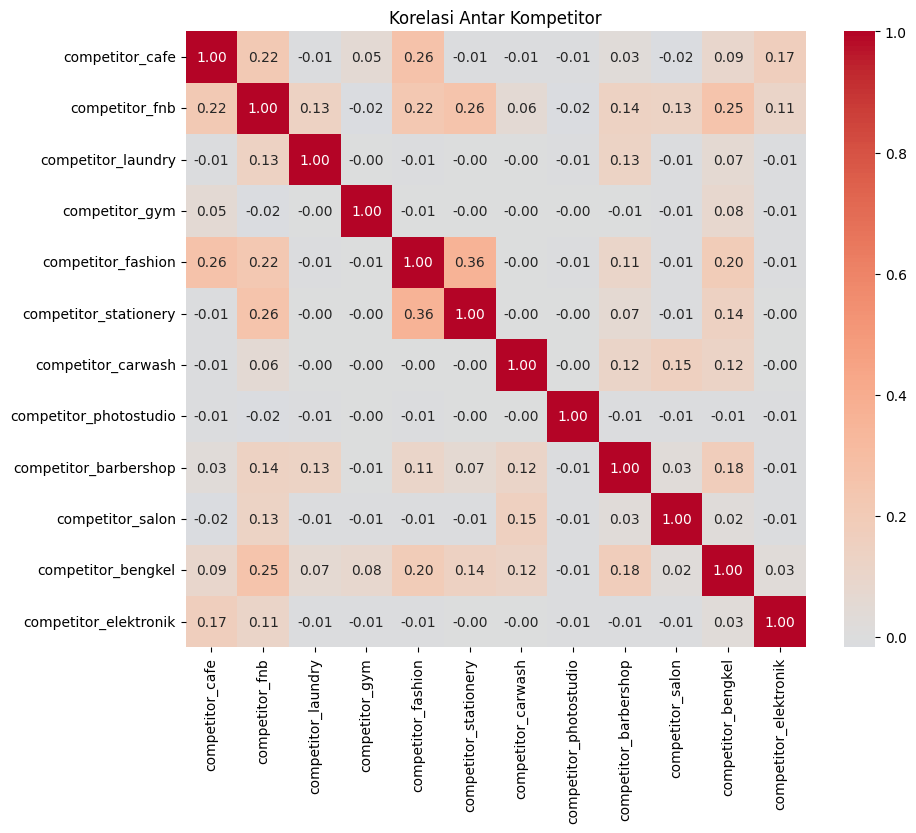


Top 3 Korelasi Terkuat:
competitor_fashion  competitor_stationery    0.362587
competitor_cafe     competitor_fashion       0.257473
competitor_fnb      competitor_stationery    0.255758
dtype: float64


In [ ]:
# Filter kolom kompetitor & hitung korelasi
comp_cols = [c for c in POI_COLS if 'competitor' in c]
corr = df_jalan[comp_cols].corr()

# Plot Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Korelasi Antar Kompetitor')
plt.show()

# Top 3 Korelasi
print("\nTop 3 Korelasi Terkuat:")
pairs = corr.unstack().drop_duplicates().sort_values(ascending=False)
print(pairs[pairs < 1].head(3))

In [ ]:
jalan_nol = df_jalan[df_jalan['total_poi'] == 0]
print(f'Total jalan tanpa POI: {len(jalan_nol)} ({len(jalan_nol)/len(df_jalan)*100:.1f}%)')

nol_per_fungsi = jalan_nol.groupby('fungsi_jalan').size()

nol_per_fungsi

Total jalan tanpa POI: 532 (52.6%)


,0
fungsi_jalan,
Arteri Sekunder,19
Kolektor Primer,8
Kolektor Sekunder,452
Lokal Primer,53


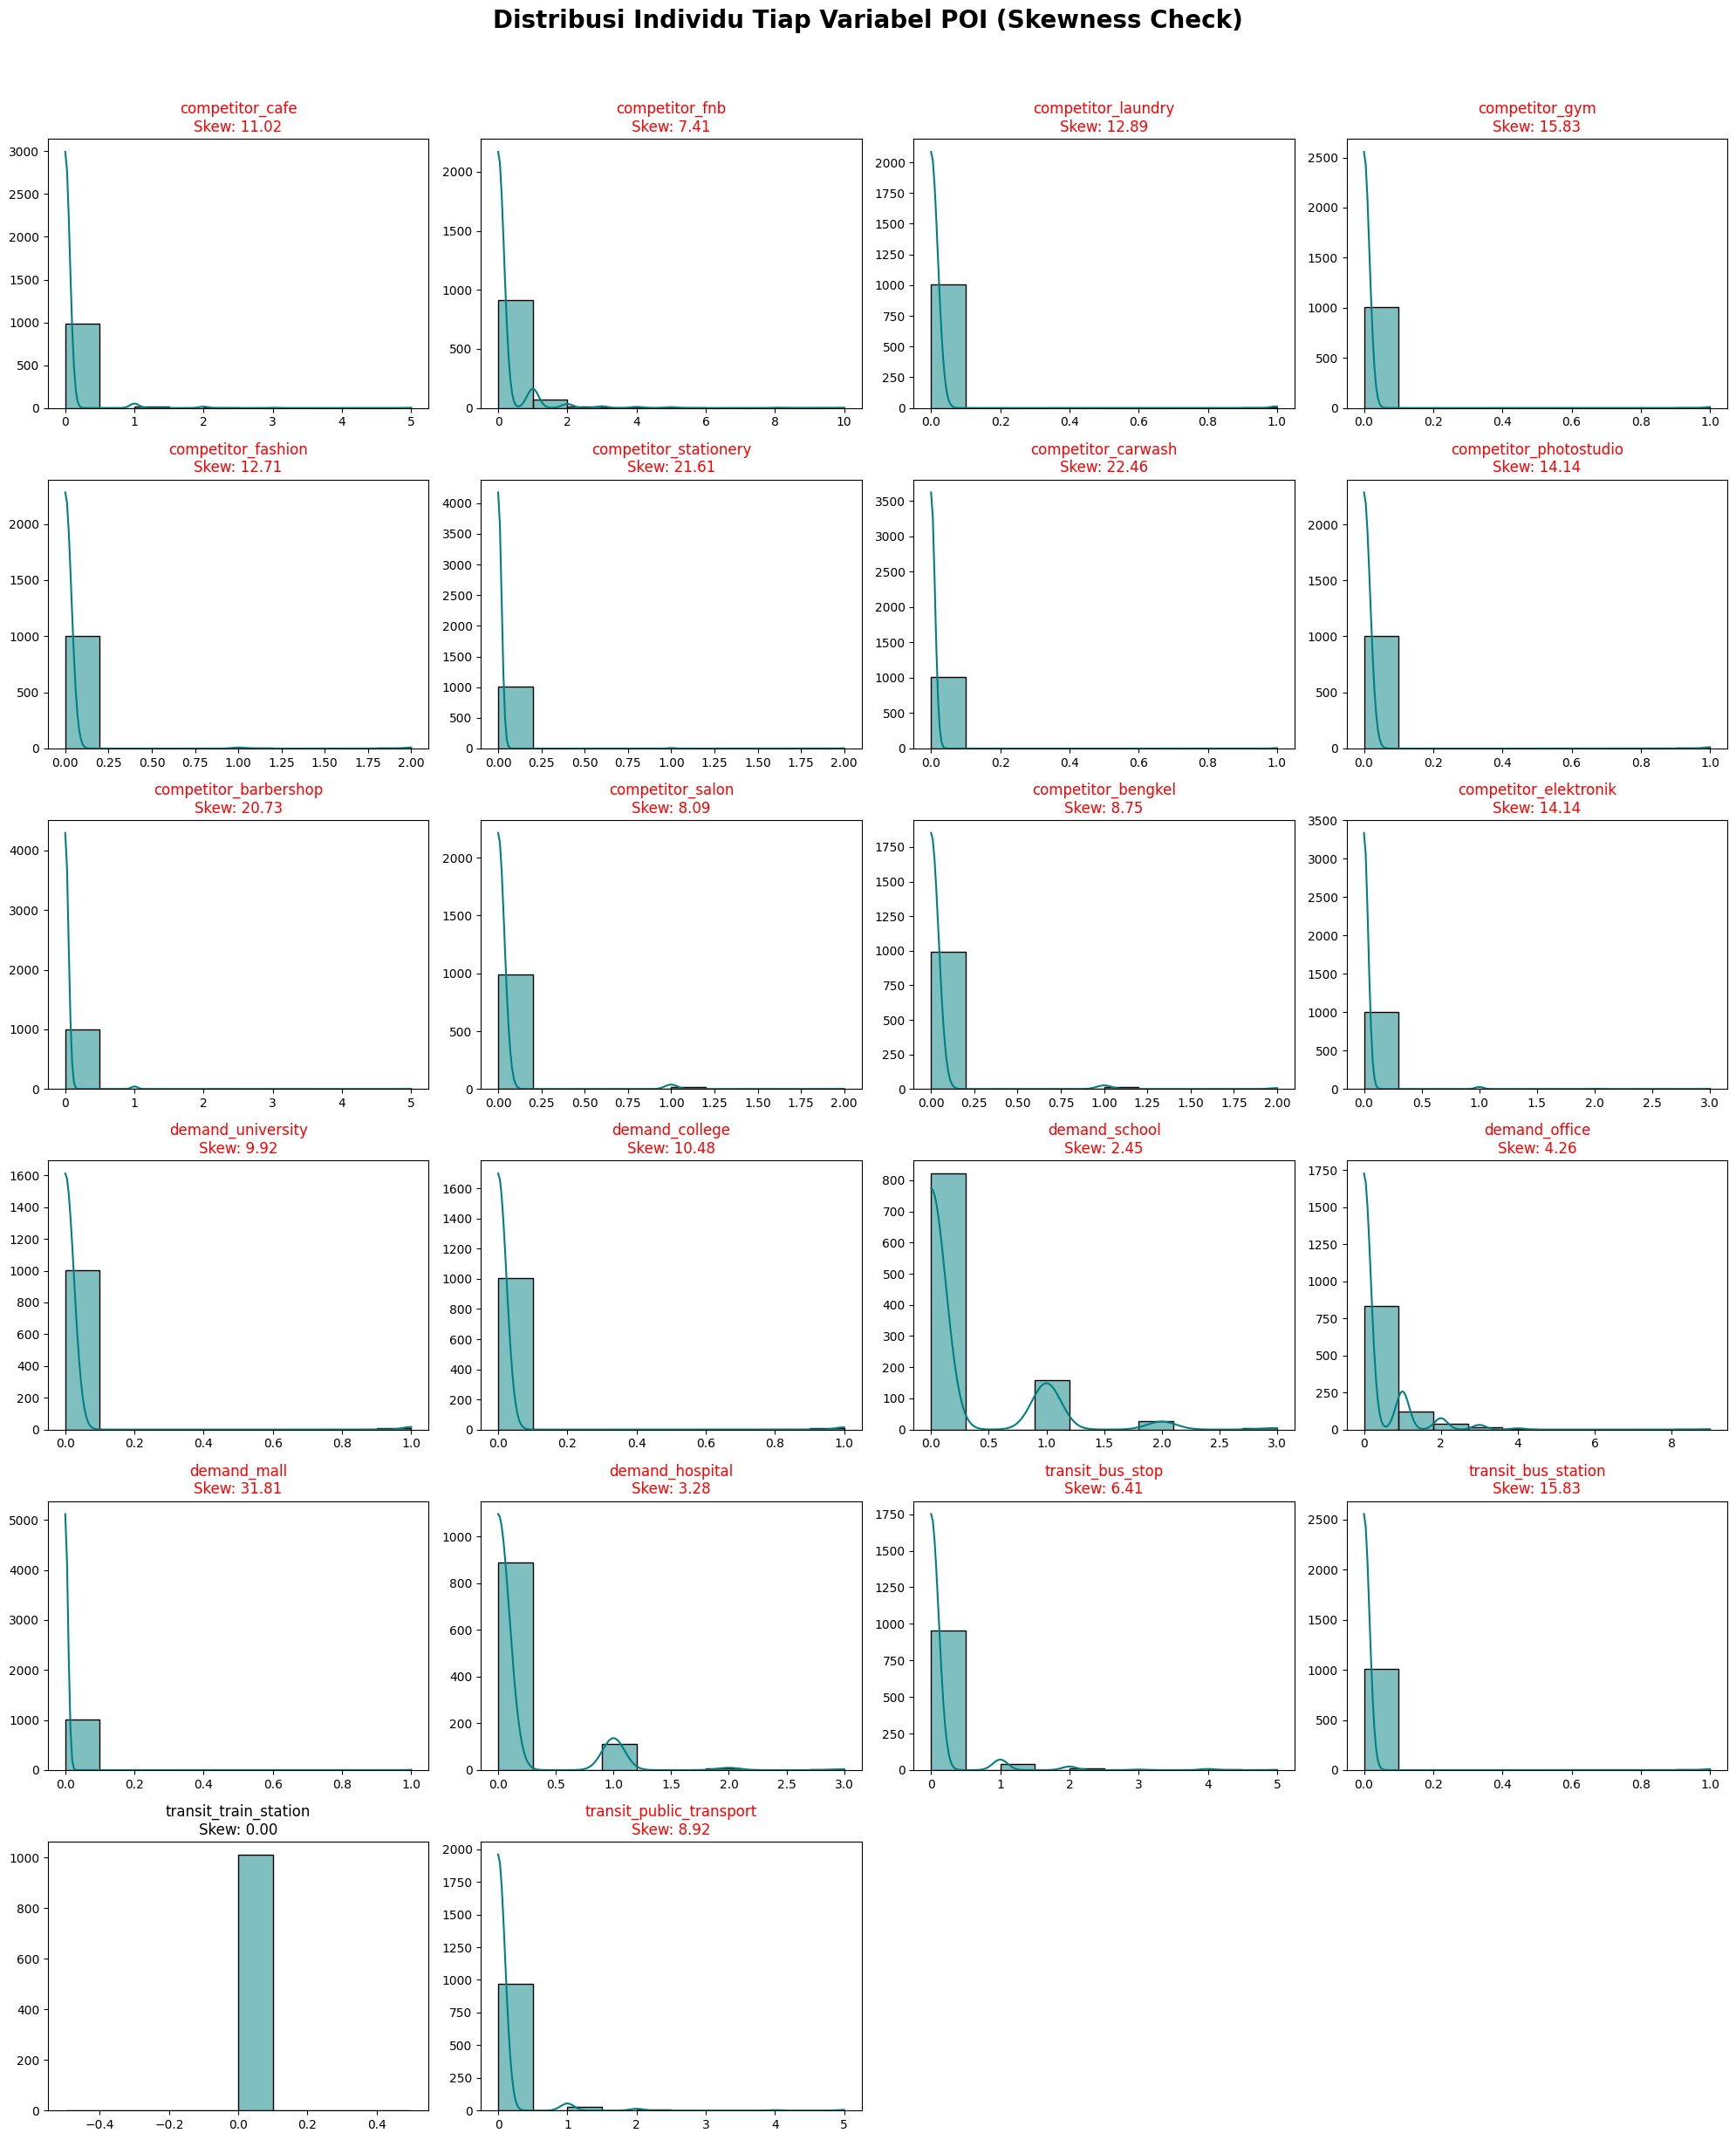

In [ ]:
n_cols = 4
n_rows = math.ceil(len(POI_COLS) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
fig.suptitle('Distribusi Individu Tiap Variabel POI (Skewness Check)', fontsize=20, fontweight='bold', y=1.02)

axes = axes.flatten()

for i, col in enumerate(POI_COLS):
    sns.histplot(df_jalan[col], kde=True, ax=axes[i], color='teal', bins=10)

    skew_val = df_jalan[col].skew()

    axes[i].set_title(f'{col}\nSkew: {skew_val:.2f}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

    # Highlight jika sangat menceng
    if skew_val > 2:
        axes[i].title.set_color('red')

# Hapus sisa subplot yang kosong
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
df_jalan = df_jalan.drop(columns='total_poi')

## Koreksi Nama Jalan dan Kelurahan

In [ ]:
# Imputasi Kelurahan yang NaN
KOREKSI_KELURAHAN = {
    'Jl. Gelatik'       : 'Purwodinatan',
    'Jl. Jalak'         : 'Purwodinatan',
    'Jl. K.H. Agus Salim': 'Purwodinatan',
    'Jl. Kenari'        : 'Purwodinatan',
    'Jl. Kepodang'      : 'Purwodinatan',
    'Jl. Pekojan'       : 'Purwodinatan',
    'Jl. Petolongan'    : 'Purwodinatan',
    'Jl. Petudungan'    : 'Purwodinatan',
    'Jl. Suari'         : 'Purwodinatan',
    'Jl. Dorang'        : 'Purwosari',
    'Jl. Patriot'       : 'Purwosari',
    'Jl. Peres'         : 'Bandarharjo',
    'Jl. Poncol'        : 'Purwosari',
    'Jl. Sendowo Barat' : 'Bulu Lor',
    'Jl. Sendowo Timur' : 'Bulu Lor',
    'Jl. Tambra'        : 'Kuningan',
}

for nama, kelurahan in KOREKSI_KELURAHAN.items():
    mask = df_jalan['nama_jalan'].str.contains(
        nama.replace('Jl. ', ''), case=False, na=False
    )
    df_jalan.loc[mask, 'kelurahan'] = kelurahan

# Verifikasi
print(f'NaN kelurahan setelah koreksi: {df_jalan["kelurahan"].isna().sum()}')
print(df_jalan[df_jalan['nama_jalan'].isin(list(KOREKSI_KELURAHAN.keys()))][
    ['nama_jalan', 'kecamatan', 'kelurahan']
].to_string(index=False))

NaN kelurahan setelah koreksi: 0
         nama_jalan       kecamatan    kelurahan
        Jl. Gelatik Semarang Tengah Purwodinatan
          Jl. Jalak Semarang Tengah Purwodinatan
Jl. K.H. Agus Salim Semarang Tengah Purwodinatan
         Jl. Kenari Semarang Tengah Purwodinatan
       Jl. Kepodang Semarang Tengah Purwodinatan
        Jl. Pekojan Semarang Tengah Purwodinatan
     Jl. Petolongan Semarang Tengah Purwodinatan
     Jl. Petudungan Semarang Tengah Purwodinatan
          Jl. Suari Semarang Tengah Purwodinatan
         Jl. Dorang  Semarang Utara    Purwosari
        Jl. Patriot  Semarang Utara    Purwosari
          Jl. Peres  Semarang Utara  Bandarharjo
         Jl. Poncol  Semarang Utara    Purwosari
  Jl. Sendowo Barat  Semarang Utara     Bulu Lor
  Jl. Sendowo Timur  Semarang Utara     Bulu Lor
         Jl. Tambra  Semarang Utara     Kuningan


## Koreksi Centorid Coordinat Lat dan Long

In [ ]:
# Koreksi manual berdasarkan Google Maps
KOREKSI_KOORDINAT = {
    'Jalan Papandayan'  : (-7.012865360355601, 110.40558203089724),
    'Jalan Watu Lawang 4': (-7.01061112194918, 110.4023390524358),
}

for nama, (lat, lng) in KOREKSI_KOORDINAT.items():
    mask = df_jalan['nama_jalan'].str.contains(
        nama.replace('Jalan ', ''), case=False
    )
    df_jalan.loc[mask, 'lat_centroid'] = lat
    df_jalan.loc[mask, 'lng_centroid'] = lng
    print(f'Dikoreksi: {nama} → ({lat}, {lng})')

# Verifikasi tidak ada duplikat lagi
dup = df_jalan.duplicated(subset=['lat_centroid', 'lng_centroid']).sum()
print(f'\nDuplikat koordinat setelah koreksi: {dup}')

Dikoreksi: Jalan Papandayan → (-7.012865360355601, 110.40558203089724)
Dikoreksi: Jalan Watu Lawang 4 → (-7.01061112194918, 110.4023390524358)

Duplikat koordinat setelah koreksi: 0


## Koreksi Mall dan Train Station

In [ ]:
# Koreksi Mall dan Trains Station
MALL_DATA = {
    'Jl. Bunderan Simpang Lima': 2,
    'Jl. Pemuda': 3,
    'Jl. M.T. Haryono': 1,
    'Jl. R.M. Hadi Subeno Sosrowardoyo': 1,
    'Jl. Taman Setia Budi': 1,
    'Jl. Gajahmada': 1,
    'Jl. Madukoro': 1,
    'Jl. Taman Majapahit': 1,
    'Jl. Anjasmoro': 1
}

STATION_DATA = {
    'Jl. Imam Bonjol': 1,
    'Jl. Tawang 1': 1
}

# Update demand_mall
for street, count in MALL_DATA.items():
    df_jalan.loc[df_jalan['nama_jalan'] == street, 'demand_mall'] = count

# Update transit_train_station
for street, count in STATION_DATA.items():
    df_jalan.loc[df_jalan['nama_jalan'] == street, 'transit_train_station'] = count

print("Data for 'demand_mall' and 'transit_train_station' has been updated in df_jalan_final.")

Data for 'demand_mall' and 'transit_train_station' has been updated in df_jalan_final.


In [ ]:
df_jalan.to_excel('df_jalan.xlsx', index=False)


## **Data Enrichment**

`VERSI_0`

`Selective spatial median imputation`

**Tujuan** :

Data OpenStreetMap (OSM) bersifat crowdsourced sehingga coverage antar wilayah tidak selalu merata. Pada beberapa ruas jalan strategis di Kota Semarang ditemukan kondisi:

* jalan memiliki kapasitas tinggi
* fungsi jalan bersifat arteri/kolektor
* namun seluruh kategori POI bernilai nol

Kondisi ini belum tentu merepresentasikan keadaan riil, tetapi dapat disebabkan oleh:

* under-mapping OSM
* belum adanya contributor
* ketidakkonsistenan tagging

Jika dibiarkan, kondisi tersebut dapat menyebabkan:

* bias pada clustering
* area strategis dianggap “sepi”
* rekomendasi bisnis menjadi misleading

Karena itu dilakukan pendekatan selective spatial median imputation.

**Konsep** :
- Nilai `0` tidak otomatis dianggap missing
- Imputasi hanya dilakukan pada ruas “suspicious”
- Suspicious = jalan besar / strategis / traffic tinggi tetapi POI kategori tertentu = 0
- Nilai pengganti menggunakan median ruas serupa berdasarkan:
  - `kecamatan`
  - `fungsi_jalan`

**Kenapa median?**
- Lebih stabil dibanding mean pada distribusi skewed
- Tidak terlalu terpengaruh hotspot ekstrem
- Menjaga distribusi spasial tetap realistis

**Contoh** :
- `Semarang Tengah + Arteri Sekunder + competitor_fnb = 0`
→ diisi median `competitor_fnb` dari ruas serupa di Semarang Tengah

**Keunggulan** :
- Koreksi undercount OSM
- Tidak overestimate global
- Distribusi lebih natural
- Metodologi lebih defensible
- Tetap mempertahankan true zero



**1. Jalan Arteri**

> Jalan ini melayani angkutan utama dengan ciri perjalanan jarak jauh, kecepatan rata-rata tinggi, dan jumlah jalan masuk (akses) dibatasi secara efisien.

a. Arteri Primer: Menghubungkan antar pusat kegiatan nasional atau antar ibukota provinsi.

- Karakteristik: Lebar jalan minimal 11 meter, kecepatan minimal 60 km/jam. Lalu lintas tidak boleh terganggu oleh kegiatan lokal.

- Contoh: Jalan Pantura (Pantai Utara Jawa), Jalan Tol Trans Jawa.

b. Arteri Sekunder: Menghubungkan kawasan primer dengan kawasan sekunder ke-1 atau antar kawasan sekunder ke-1 dalam kota.

- Karakteristik: Kecepatan minimal 30 km/jam, lebar minimal 11 meter.

- Contoh: Jalan Protokol di tengah kota besar (seperti Jl. Sudirman di Jakarta atau Jl. Pandanaran di Semarang).

**2. Jalan Kolektor**
Jalan ini melayani angkutan pengumpul atau pembagi dengan ciri perjalanan jarak sedang, kecepatan rata-rata sedang, dan akses dibatasi.

a. Kolektor Primer: Menghubungkan antar pusat kegiatan wilayah atau antara pusat kegiatan nasional dengan wilayah.

- Karakteristik: Kecepatan minimal 40 km/jam, lebar jalan minimal 9 meter.

- Contoh: Jalan yang menghubungkan kabupaten satu ke kabupaten lainnya yang bukan jalur utama nasional.

b. Kolektor Sekunder: Menghubungkan antar kawasan sekunder kedua.

- Karakteristik: Kecepatan minimal 20 km/jam, lebar minimal 9 meter.

- Contoh: Jalan utama yang menghubungkan antar kecamatan atau antar pusat perdagangan di dalam kota.

**3. Jalan Lokal**

Jalan ini melayani angkutan setempat dengan ciri perjalanan jarak dekat, kecepatan rendah, dan akses tidak dibatasi.

a. Lokal Primer: Menghubungkan pusat kegiatan nasional/wilayah dengan pusat kegiatan lingkungan.

- Karakteristik: Kecepatan minimal 20 km/jam, lebar jalan minimal 7.5 meter.

- Contoh: Jalan yang menghubungkan kota dengan desa atau daerah terpencil.

b. Lokal Sekunder: Menghubungkan antar kawasan sekunder ketiga atau kawasan pemukiman.

- Karakteristik: Kecepatan minimal 10 km/jam, lebar minimal 7.5 meter.

- Contoh: Jalan-jalan di area perumahan atau kompleks.

In [ ]:
df_jalan_final = df_jalan.copy()

# Hitung total POI awal
df_jalan['total_poi_asli'] = df_jalan[POI_COLS].sum(axis=1)
df_jalan_final['total_poi_asli'] = df_jalan['total_poi_asli'] # Add to df_jalan_final as well

### Spatial Feature Engineering

In [ ]:
# Tambahkan bobot fungsi jalan
BOBOT_FUNGSI = {
    'Arteri Primer'    : 4,
    'Arteri Sekunder'  : 3,
    'Kolektor Primer'  : 3,
    'Kolektor Sekunder': 2,
    'Lokal Primer'     : 1,
    'Lokal Sekunder'   : 1,
}

df_jalan_final['bobot_fungsi'] = (
    df_jalan_final['fungsi_jalan']
    .map(BOBOT_FUNGSI)
    .fillna(1)
)

# Proxy traffic
df_jalan_final['traffic_score'] = (
    df_jalan_final['panjang_m'] *
    df_jalan_final['lebar_m'] *
    df_jalan_final['bobot_fungsi']
)

# Threshold median traffic
traffic_threshold = df_jalan_final['traffic_score'].median()

In [ ]:
# Variabel transit_score
df_jalan_final['transit_score'] = (
    df_jalan_final['transit_train_station']    * 3 +
    df_jalan_final['transit_bus_station']      * 2 +
    df_jalan_final['transit_bus_stop']         * 1 +
    df_jalan_final['transit_public_transport'] * 1
)

### Imputasi

In [ ]:
# Definisi
TAGS_POI_IMPUTATION = {

    # Kompetitor
    'competitor_cafe'       : {'amenity': ['cafe']},
    'competitor_fnb'        : {'amenity': ['restaurant', 'fast_food', 'food_court']},
    'competitor_laundry'    : {'shop': ['laundry', 'dry_cleaning']},
    'competitor_gym'        : {'leisure': ['fitness_centre', 'sports_centre']},
    'competitor_fashion'    : {'shop': ['clothes', 'fashion', 'boutique']},
    'competitor_stationery' : {'shop': 'stationery'},
    'competitor_carwash'    : {'amenity': 'car_wash'},
    'competitor_photostudio': {'shop': ['photo', 'photo_studio']},
    'competitor_barbershop' : {'shop': ['barber', 'hairdresser']},
    'competitor_salon'      : {'shop': ['beauty', 'nail_salon']},
    'competitor_bengkel'    : {'shop': ['car_repair', 'motorcycle_repair', 'vehicle']},
    'competitor_elektronik' : {'shop': ['electronics', 'computer', 'mobile_phone']},

    # Demand
    'demand_school'         : {'amenity': 'school'},
    'demand_office'         : {'office': True},
    'demand_hospital'       : {'amenity': ['hospital', 'clinic']},

    # Transit
    'transit_bus_stop'         : {'highway': 'bus_stop'},
    'transit_bus_station'      : {'amenity': 'bus_station'},
    'transit_public_transport' : {'public_transport': 'stop_position'},
}

POI_COLS_IMPUTATION = list(TAGS_POI_IMPUTATION.keys())

In [ ]:
# IMPUTASI PER POI
for col in POI_COLS_IMPUTATION:

    # Median grup spasial
    median_group = (
        df_jalan_final[df_jalan_final[col] > 0]
        .groupby(['kecamatan', 'fungsi_jalan'])[col]
        .median()
    )

    # Median fallback fungsi jalan
    median_fungsi = (
        df_jalan_final[df_jalan_final[col] > 0]
        .groupby('fungsi_jalan')[col]
        .median()
    )

    # Iterasi tiap ruas
    for idx, row in df_jalan_final.iterrows():

        suspicious_zero = (
            row[col] == 0 and
            row['fungsi_jalan'] in [
                'Arteri Sekunder',
                'Kolektor Primer',
                'Kolektor Sekunder'
            ] and
            row['traffic_score'] >= traffic_threshold
        )

        if suspicious_zero:

            key = (row['kecamatan'], row['fungsi_jalan'])

            # Prioritas median kecamatan + fungsi
            if key in median_group.index:
                nilai_imputasi = median_group.loc[key]

            # Fallback median fungsi
            elif row['fungsi_jalan'] in median_fungsi.index:
                nilai_imputasi = median_fungsi.loc[row['fungsi_jalan']]

            else:
                nilai_imputasi = 0

            # Isi hanya jika valid
            if pd.notna(nilai_imputasi) and nilai_imputasi > 0:
                df_jalan_final.at[idx, col] = round(nilai_imputasi)

In [ ]:
total_asli = df_jalan['total_poi_asli'].sum()
df_jalan_final['total_poi_imputed'] = df_jalan_final[POI_COLS].sum(axis=1)
total_imputed = df_jalan_final['total_poi_imputed'].sum()

selisih = total_imputed - total_asli
persen = (
    (selisih / total_asli) * 100
    if total_asli > 0 else 0
)

print(f"Total POI Asli                : {total_asli:,}")
print(f"Total POI Setelah Imputasi    : {total_imputed:,}")
print(f"Kenaikan Total POI            : {selisih:,}")
print(f"Persentase Kenaikan           : {persen:.2f}%")

Total POI Asli                : 1,126
Total POI Setelah Imputasi    : 9,601
Kenaikan Total POI            : 8,475
Persentase Kenaikan           : 752.66%


# **LOAD**

In [ ]:
df_jalan_final

,nama_jalan,kecamatan,kelurahan,lat_centroid,lng_centroid,fungsi_jalan,panjang_m,lebar_m,competitor_cafe,competitor_fnb,...,demand_hospital,transit_bus_stop,transit_bus_station,transit_train_station,transit_public_transport,total_poi_asli,bobot_fungsi,traffic_score,transit_score,total_poi_imputed
0,Jl. Abimanyu,Semarang Tengah,Pendrikan Lor,-6.977414,110.409872,Kolektor Sekunder,240.40,4.0,0,0,...,0,0,0,0,0,1,2,1923.200,0,1
1,Jl. Ade Irma Suryani Nasution,Semarang Tengah,Sekayu,-6.974783,110.415214,Lokal Primer,529.71,7.0,0,0,...,0,0,0,0,0,0,1,3707.970,0,0
2,Jl. Alun-Alun Barat,Semarang Tengah,Kauman,-6.971964,110.423453,Kolektor Sekunder,216.76,3.0,0,0,...,0,0,0,0,0,0,2,1300.560,0,0
3,Jl. Alun-Alun Timur,Semarang Tengah,Kauman,-6.970721,110.424190,Kolektor Sekunder,168.21,10.0,0,0,...,0,0,0,0,0,0,2,3364.200,0,0
4,Jl. Anggrek,Semarang Tengah,Pekunden,-6.988915,110.423814,Lokal Primer,338.87,5.5,0,1,...,0,0,0,0,0,3,1,1863.785,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1007,Jl. Pulau Tirang Tapak,Tugu,Tugurejo,-6.970596,110.346220,Lokal Primer,2029.33,3.0,0,0,...,0,0,0,0,0,0,1,6087.990,0,0
1008,Jl. Stasiun Jraka,Tugu,Jerakah,-6.983850,110.363077,Lokal Primer,706.21,3.5,0,0,...,1,0,0,0,0,2,1,2471.735,0,2
1009,Jl. Stasiun Mangkang,Tugu,Mangkang Wetan,-6.972243,110.304174,Kolektor Primer,253.06,3.5,0,0,...,0,1,0,0,1,2,3,2657.130,2,2
1010,Jl. Tapak,Tugu,Tugurejo,-6.982313,110.344949,Lokal Primer,864.77,4.0,0,0,...,0,1,0,0,1,4,1,3459.080,2,4


In [ ]:
df_jalan_final.to_excel("Dataset_Jalan_Semarang_Imputasi.xlsx",index=False)

# **BUSINESS UNDERSTANDING**

## Identifikasi Stakeholder

## Pertanyaan Bisnis

## Metrik Kesuksesan

# **DATA UNDERSTANDING/EDA**

## Struktur Data

In [ ]:
df_jalan_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1012 entries, 0 to 1011
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   nama_jalan                1012 non-null   object 
 1   kecamatan                 1012 non-null   object 
 2   kelurahan                 1012 non-null   object 
 3   lat_centroid              1012 non-null   float64
 4   lng_centroid              1012 non-null   float64
 5   fungsi_jalan              1012 non-null   object 
 6   panjang_m                 1012 non-null   float64
 7   lebar_m                   1012 non-null   float64
 8   competitor_cafe           1012 non-null   int64  
 9   competitor_fnb            1012 non-null   int64  
 10  competitor_laundry        1012 non-null   int64  
 11  competitor_gym            1012 non-null   int64  
 12  competitor_fashion        1012 non-null   int64  
 13  competitor_stationery     1012 non-null   int64  
 14  competit

## Statistik Deskriptif

In [ ]:
df_jalan_final.describe()

,lat_centroid,lng_centroid,panjang_m,lebar_m,competitor_cafe,competitor_fnb,competitor_laundry,competitor_gym,competitor_fashion,competitor_stationery,...,demand_hospital,transit_bus_stop,transit_bus_station,transit_train_station,transit_public_transport,total_poi_asli,bobot_fungsi,traffic_score,transit_score,total_poi_imputed
count,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000,...,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000
mean,-7.010591,110.420599,829.943123,4.708004,0.565217,0.621542,0.458498,0.398221,0.546443,0.425889,...,0.586957,0.620553,0.474308,0.001976,0.625494,1.112648,1.974308,10164.146438,0.167984,9.487154
std,0.037312,0.042906,963.134371,2.373916,0.679425,0.830936,0.498521,0.489774,0.651269,0.547850,...,0.626917,0.735084,0.499586,0.044433,0.773614,1.947673,0.432749,23855.484934,0.817370,9.467464
min,-7.110280,110.286128,22.790000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,136.740000,0.000000,0.000000
25%,-7.034740,110.404134,307.867500,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2167.430000,0.000000,0.000000
50%,-7.001291,110.425540,525.320000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,3992.760000,0.000000,3.000000
75%,-6.981966,110.447186,958.750000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,2.000000,8576.550000,0.000000,19.000000
max,-6.942240,110.503316,10006.070000,20.000000,5.000000,10.000000,1.000000,1.000000,2.000000,2.000000,...,3.000000,5.000000,1.000000,1.000000,5.000000,18.000000,4.000000,420254.940000,10.000000,31.000000


## Univariate Analysis

### Distribusi Jumlah Jalan per Kecamatan

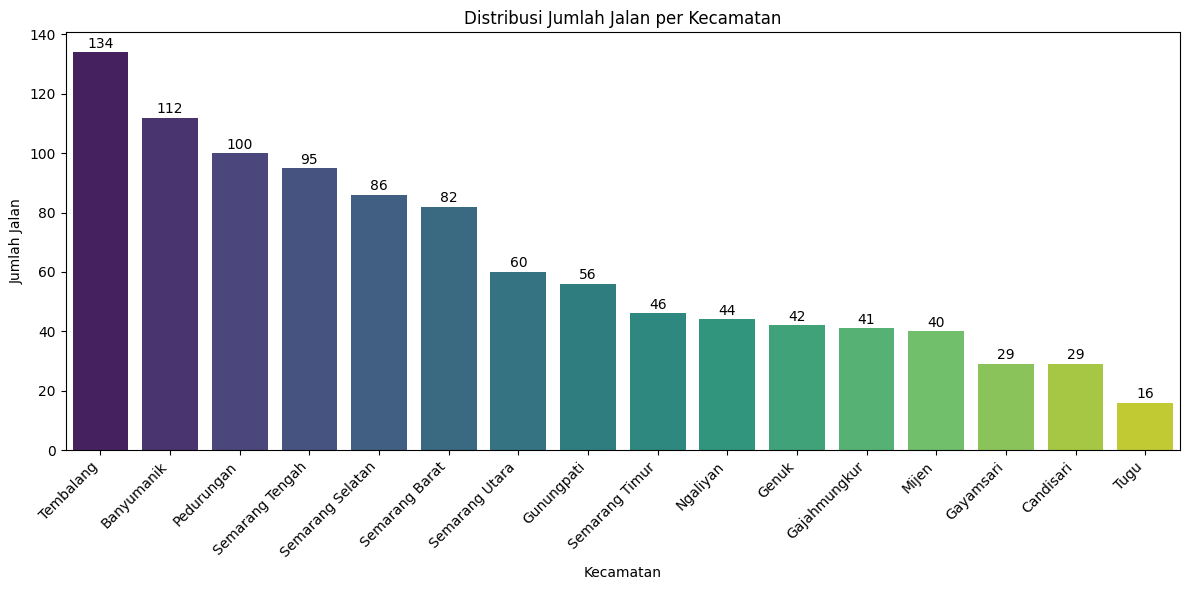

In [ ]:
kecamatan_counts = df_jalan_final['kecamatan'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=kecamatan_counts.index, y=kecamatan_counts.values, palette='viridis', hue=kecamatan_counts.index, legend=False)
plt.title('Distribusi Jumlah Jalan per Kecamatan')
plt.xlabel('Kecamatan')
plt.ylabel('Jumlah Jalan')
plt.xticks(rotation=45, ha='right')

# Add counts on top of bars
for index, value in enumerate(kecamatan_counts.values):
    plt.text(index, value + 0.5, str(value), ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Distribusi Jumlah Jalan per Kelurahan (Top 10)

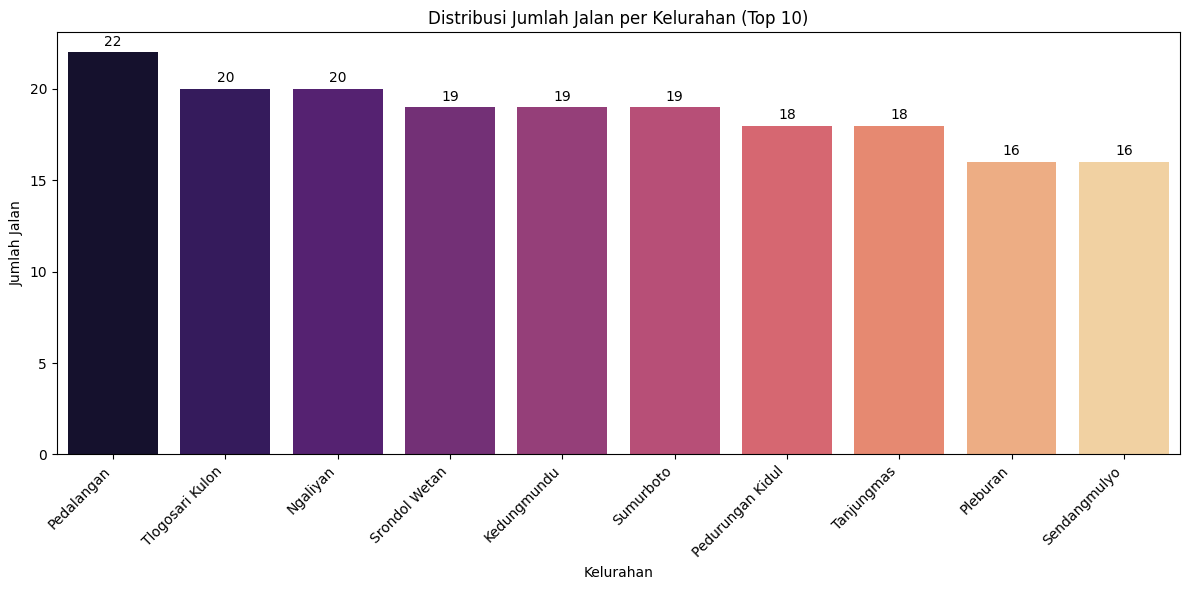

In [ ]:
kelurahan_counts = df_jalan_final['kelurahan'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=kelurahan_counts.index, y=kelurahan_counts.values, palette='magma', hue=kelurahan_counts.index, legend=False)
plt.title('Distribusi Jumlah Jalan per Kelurahan (Top 10)')
plt.xlabel('Kelurahan')
plt.ylabel('Jumlah Jalan')
plt.xticks(rotation=45, ha='right')

# Add counts on top of bars
for index, value in enumerate(kelurahan_counts.values):
    plt.text(index, value + 0.2, str(value), ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Distribusi Fungsi Jalan

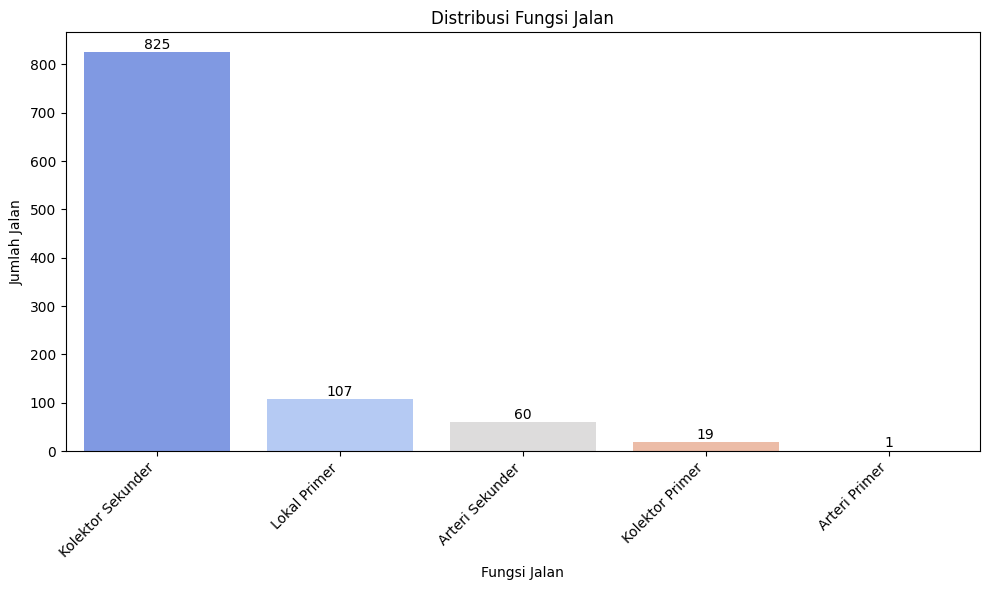

In [ ]:
fungsi_jalan_counts = df_jalan_final['fungsi_jalan'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=fungsi_jalan_counts.index, y=fungsi_jalan_counts.values, palette='coolwarm', hue=fungsi_jalan_counts.index, legend=False)
plt.title('Distribusi Fungsi Jalan')
plt.xlabel('Fungsi Jalan')
plt.ylabel('Jumlah Jalan')
plt.xticks(rotation=45, ha='right')

# Add counts on top of bars
for index, value in enumerate(fungsi_jalan_counts.values):
    plt.text(index, value + 0.2, str(value), ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Distribusi POI Kompetitor

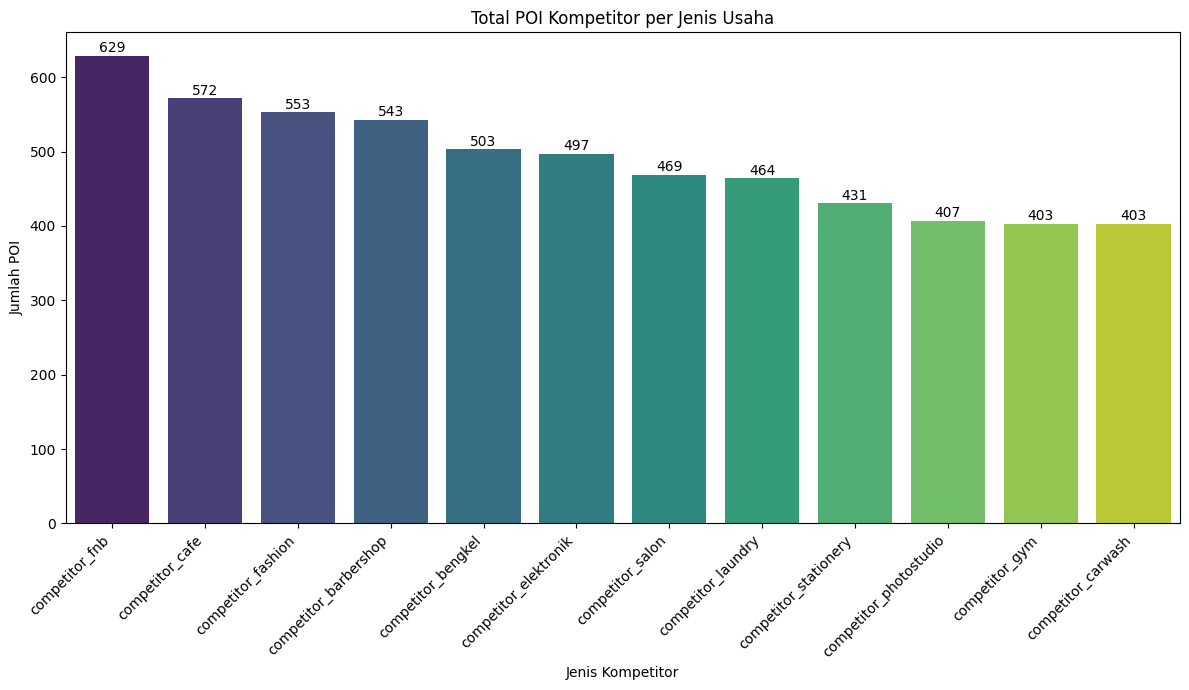

In [ ]:
competitor_cols = [col for col in POI_COLS if col.startswith('competitor')]
competitor_counts = df_jalan_final[competitor_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=competitor_counts.index, y=competitor_counts.values, palette='viridis', hue=competitor_counts.index, legend=False)
plt.title('Total POI Kompetitor per Jenis Usaha')
plt.xlabel('Jenis Kompetitor')
plt.ylabel('Jumlah POI')
plt.xticks(rotation=45, ha='right')

for index, value in enumerate(competitor_counts.values):
    plt.text(index, value + 0.5, str(int(value)), ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Distribusi POI Demand

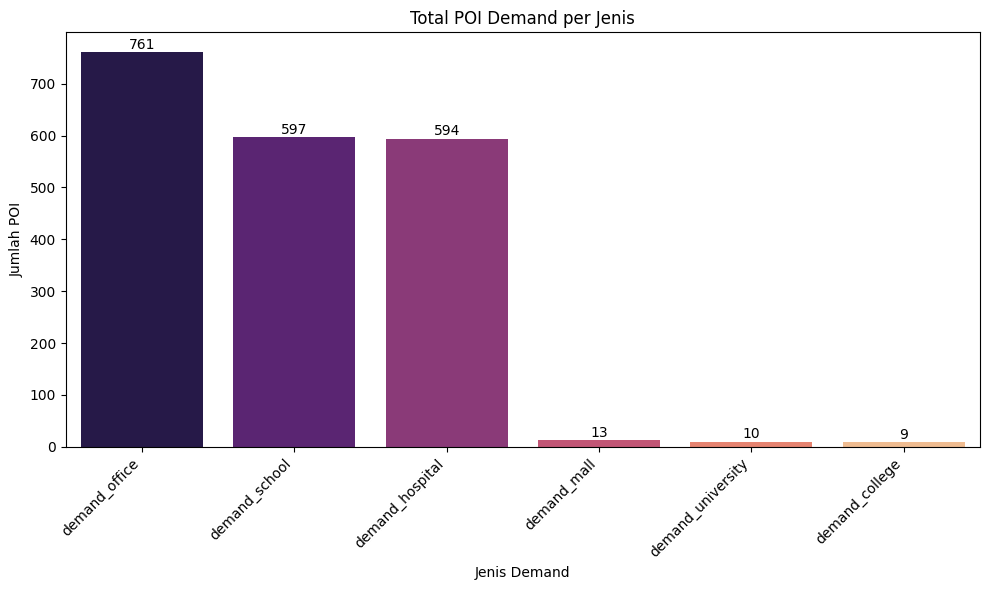

In [ ]:
demand_cols = [col for col in POI_COLS if col.startswith('demand')]
demand_counts = df_jalan_final[demand_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=demand_counts.index, y=demand_counts.values, palette='magma', hue=demand_counts.index, legend=False)
plt.title('Total POI Demand per Jenis')
plt.xlabel('Jenis Demand')
plt.ylabel('Jumlah POI')
plt.xticks(rotation=45, ha='right')

for index, value in enumerate(demand_counts.values):
    plt.text(index, value + 0.5, str(int(value)), ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Distribusi POI Transit

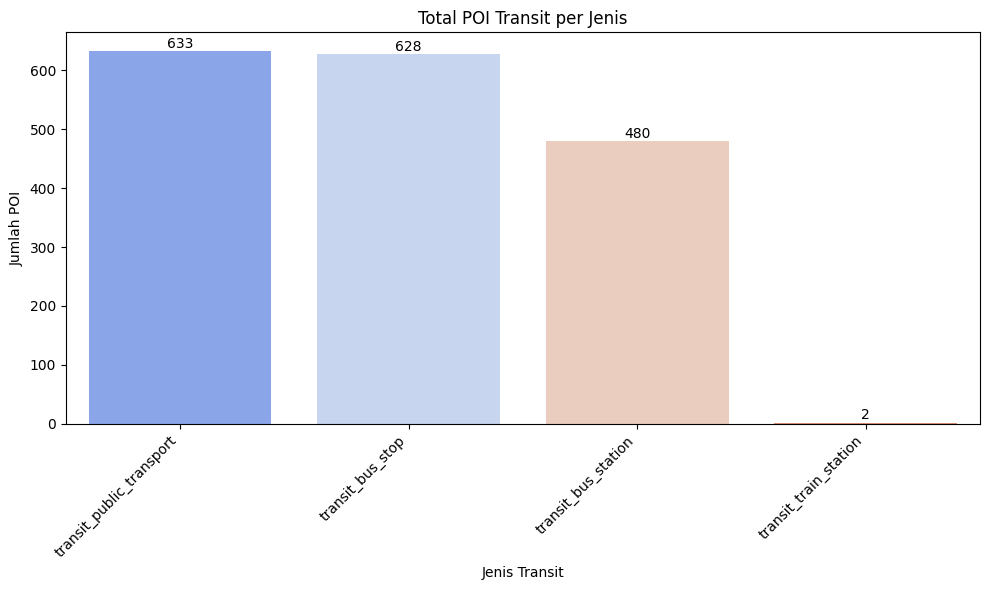

In [ ]:
transit_cols = [col for col in POI_COLS if col.startswith('transit')]
transit_counts = df_jalan_final[transit_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=transit_counts.index, y=transit_counts.values, palette='coolwarm', hue=transit_counts.index, legend=False)
plt.title('Total POI Transit per Jenis')
plt.xlabel('Jenis Transit')
plt.ylabel('Jumlah POI')
plt.xticks(rotation=45, ha='right')

for index, value in enumerate(transit_counts.values):
    plt.text(index, value + 0.5, str(int(value)), ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Distribusi Traffic Score

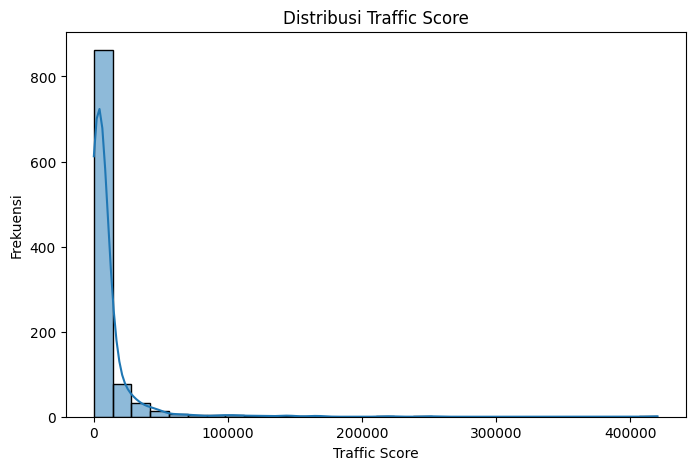

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_jalan_final['traffic_score'],
    bins=30,
    kde=True
)

plt.title('Distribusi Traffic Score')
plt.xlabel('Traffic Score')
plt.ylabel('Frekuensi')

plt.show()

### Distribusi Total POI

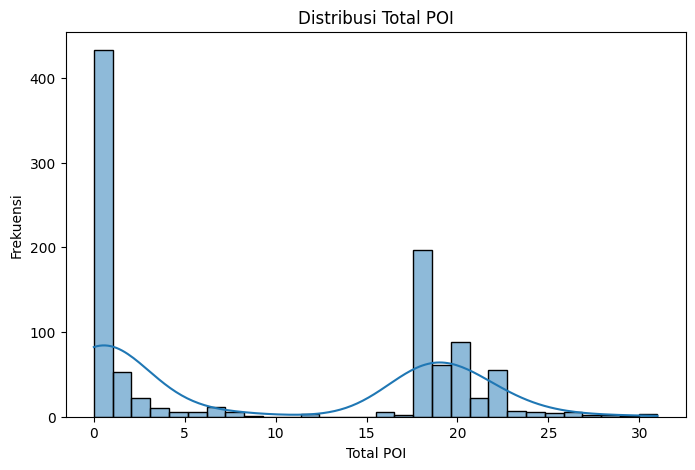

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_jalan_final['total_poi_imputed'],
    bins=30,
    kde=True
)

plt.title('Distribusi Total POI')
plt.xlabel('Total POI')
plt.ylabel('Frekuensi')

plt.show()

### Distribusi Panjang Jalan

<Axes: xlabel='panjang_m', ylabel='Count'>

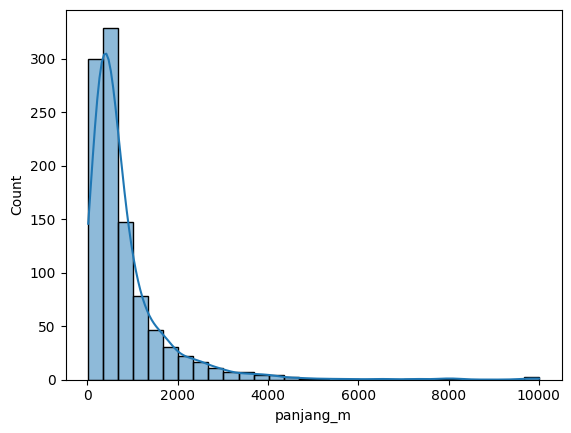

In [ ]:
sns.histplot(df_jalan_final['panjang_m'], bins=30, kde=True)

### Distribusi Lebar Jalan

<Axes: xlabel='lebar_m', ylabel='Count'>

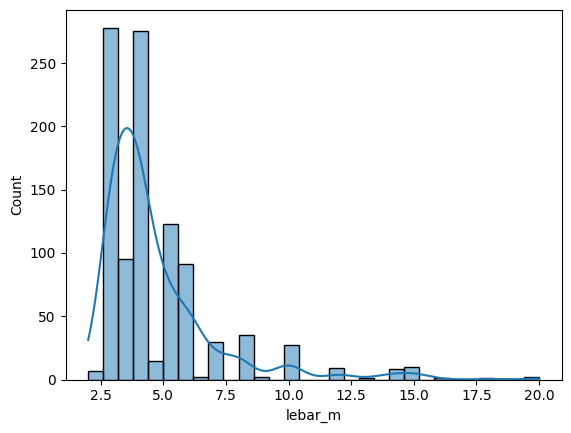

In [ ]:
sns.histplot(df_jalan_final['lebar_m'], bins=30, kde=True)

### Sparsity Global

In [ ]:
poi_cols = [
    c for c in df_jalan_final.columns
    if (
        c.startswith('competitor_') or
        c.startswith('demand_') or
        c.startswith('transit_')
    )
]

df_jalan_final['total_poi'] = (
    df_jalan_final[poi_cols]
    .sum(axis=1)
)

sparsity_rate = (
    (df_jalan_final['total_poi'] == 0)
    .mean()
) * 100

print(f"Sparsity Rate Global: {sparsity_rate:.2f}%")

Sparsity Rate Global: 30.93%


## Bivariate Analysis

### Kecamatan vs Total POI

Melihat kecamatan mana paling aktif bisnisnya

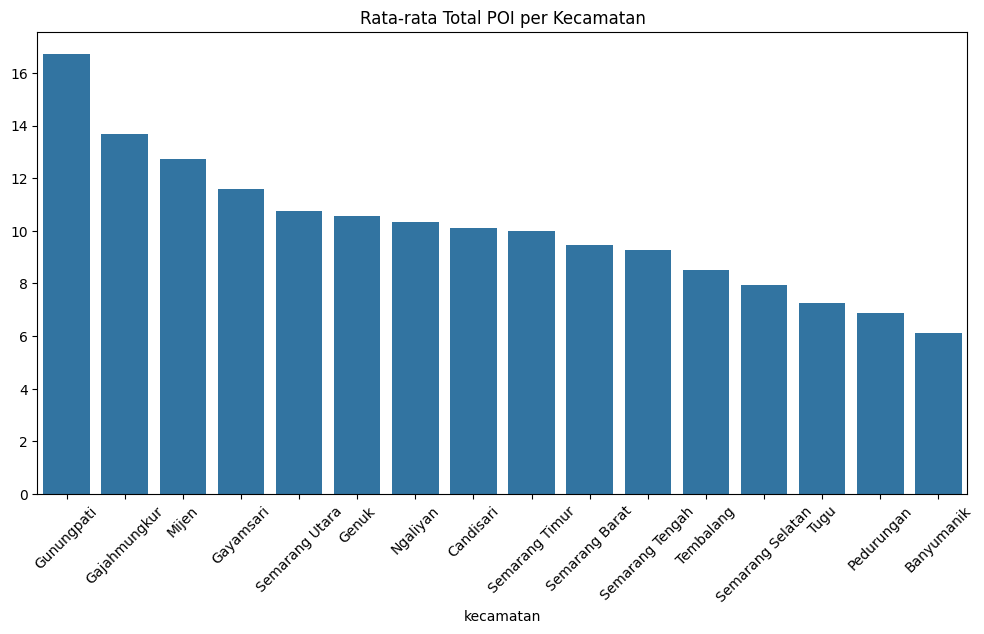

In [ ]:
kec_stats = (
    df_jalan_final
    .groupby('kecamatan')['total_poi_imputed']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=kec_stats.index,
    y=kec_stats.values
)

plt.xticks(rotation=45)
plt.title('Rata-rata Total POI per Kecamatan')

plt.show()

### Kelurahan vs Total POI

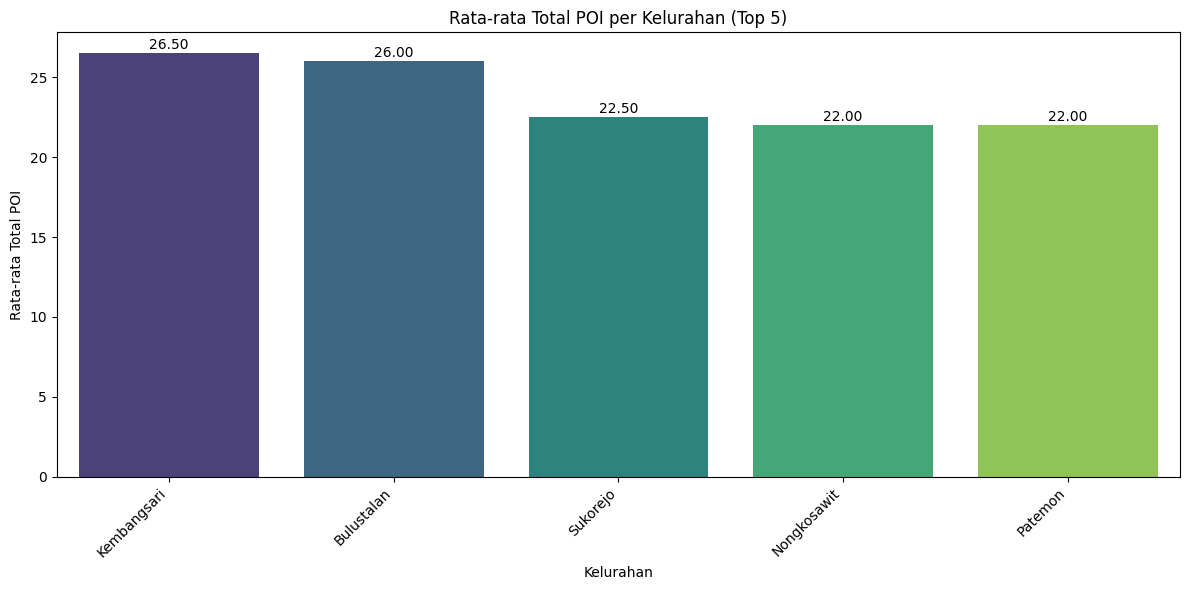

In [ ]:
kel_stats = (
    df_jalan_final
    .groupby('kelurahan')['total_poi_imputed']
    .mean()
    .nlargest(5)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=kel_stats.index,
    y=kel_stats.values,
    palette='viridis'
)

plt.xticks(rotation=45, ha='right')
plt.title('Rata-rata Total POI per Kelurahan (Top 5)')
plt.xlabel('Kelurahan')
plt.ylabel('Rata-rata Total POI')

for index, value in enumerate(kel_stats.values):
    plt.text(index, value + 0.1, f'{value:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Distribusi Kompetitor per Kecamatan



Mencari hotspot bisnis pada masing-masing jenis usaha

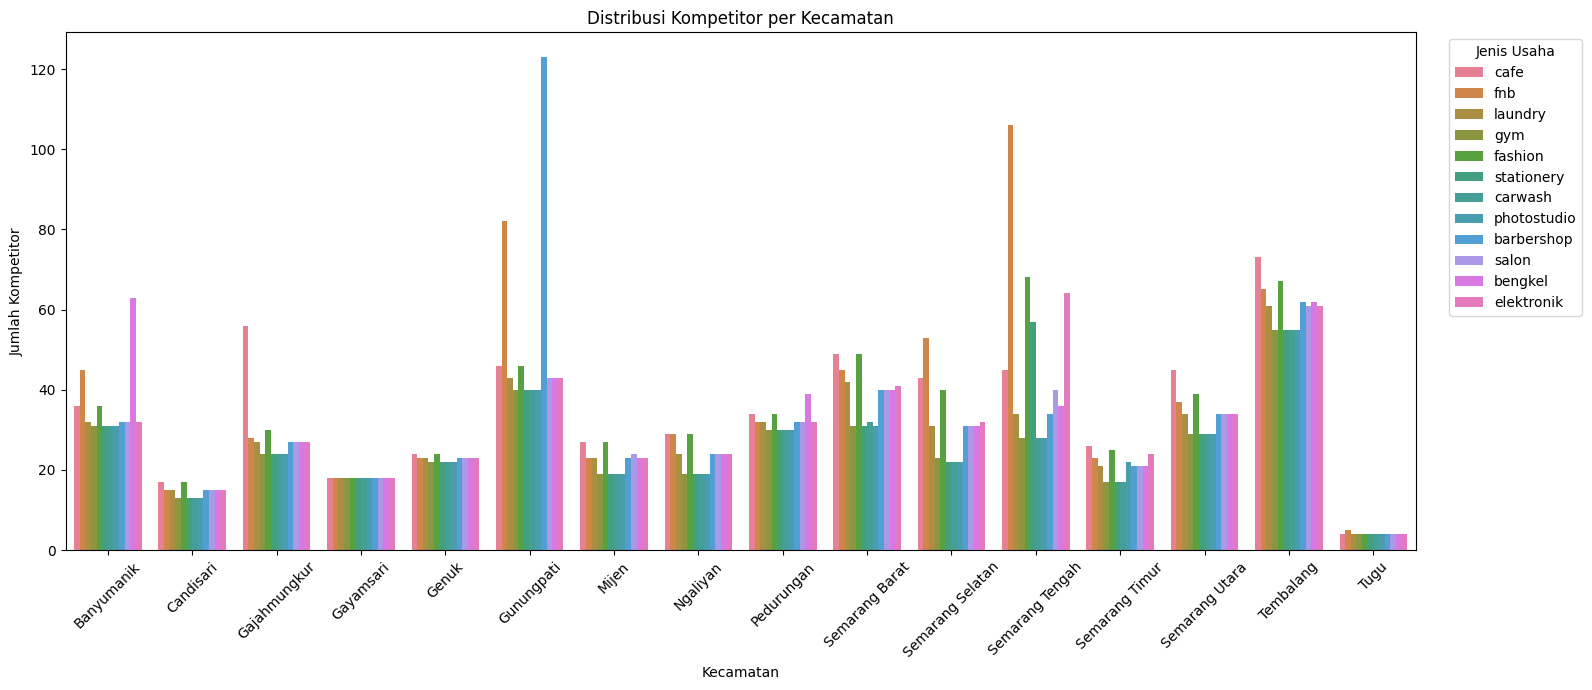

In [ ]:
# Semua kolom kompetitor
competitor_cols = [c for c in df_jalan_final.columns if c.startswith('competitor_')]

# Agregasi total kompetitor per kecamatan
kec_comp = (
    df_jalan_final
    .groupby('kecamatan')[competitor_cols]
    .sum()
)

# Ubah ke format long biar gampang diplot
kec_comp_long = (
    kec_comp
    .reset_index()
    .melt(
        id_vars='kecamatan',
        var_name='jenis_usaha',
        value_name='jumlah'
    )
)

# Rapihin nama
kec_comp_long['jenis_usaha'] = (
    kec_comp_long['jenis_usaha']
    .str.replace('competitor_', '', regex=False)
)

plt.figure(figsize=(16,7))

sns.barplot(
    data=kec_comp_long,
    x='kecamatan',
    y='jumlah',
    hue='jenis_usaha'
)

plt.xticks(rotation=45)
plt.title('Distribusi Kompetitor per Kecamatan')
plt.xlabel('Kecamatan')
plt.ylabel('Jumlah Kompetitor')

plt.legend(
    title='Jenis Usaha',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

### Distribusi Kompetitor per Kelurahan


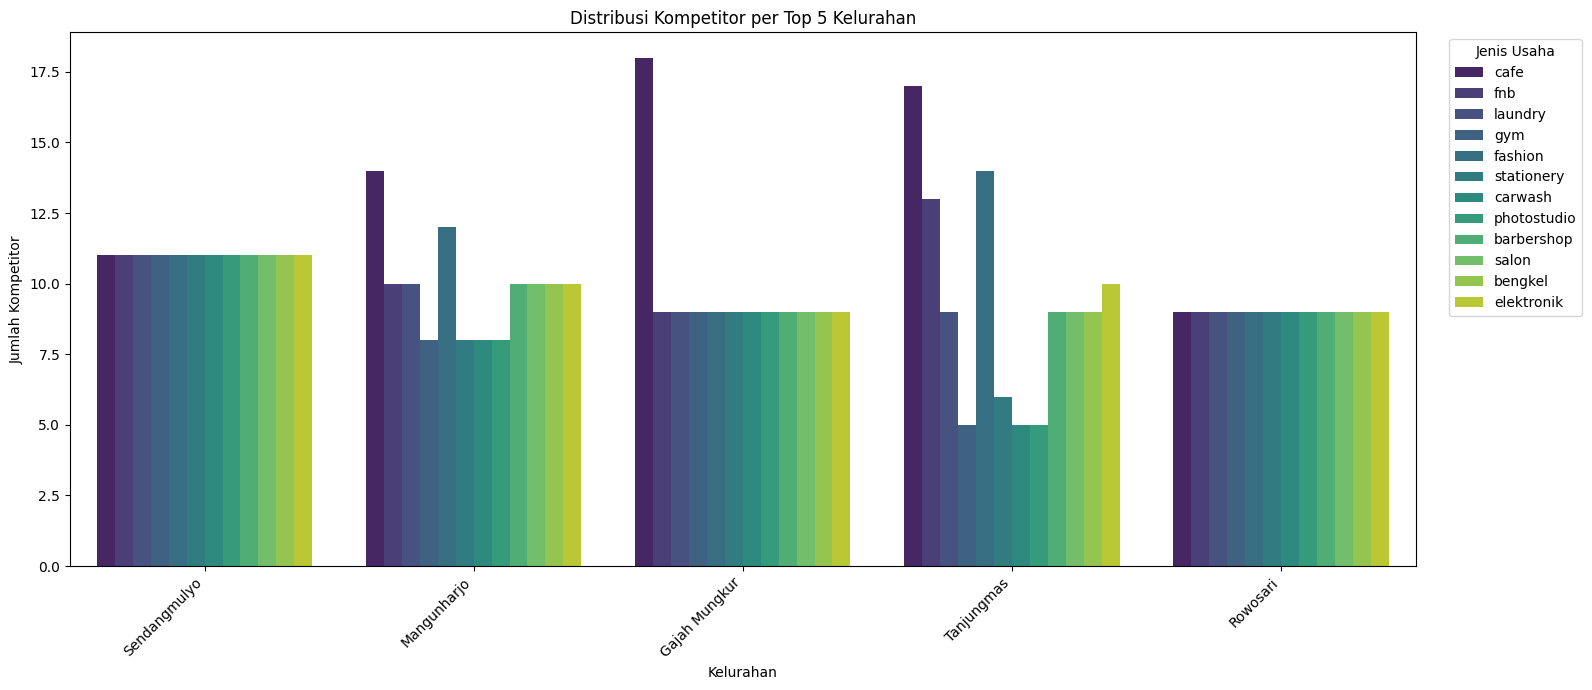

In [ ]:
competitor_cols = [c for c in df_jalan_final.columns if c.startswith('competitor_')]

# Agregasi total kompetitor per kelurahan
kel_comp = (
    df_jalan_final
    .groupby('kelurahan')[competitor_cols]
    .sum()
)

# Hitung total kompetitor untuk masing-masing kelurahan
kel_comp['total_competitors'] = kel_comp.sum(axis=1)

# Ambil top 5 kelurahan berdasarkan total kompetitor
top_5_kelurahan = kel_comp.nlargest(5, 'total_competitors').index.tolist()

# Filter kel_comp untuk hanya menyertakan top 5 kelurahan
kel_comp_top_5 = kel_comp.loc[top_5_kelurahan].drop(columns='total_competitors')

# Ubah ke format long biar gampang diplot
kel_comp_long = (
    kel_comp_top_5
    .reset_index()
    .melt(
        id_vars='kelurahan',
        var_name='jenis_usaha',
        value_name='jumlah'
    )
)

# Rapihin nama
kel_comp_long['jenis_usaha'] = (
    kel_comp_long['jenis_usaha']
    .str.replace('competitor_', '', regex=False)
)

plt.figure(figsize=(16,7))

sns.barplot(
    data=kel_comp_long,
    x='kelurahan',
    y='jumlah',
    hue='jenis_usaha',
    palette='viridis'
)

plt.xticks(rotation=45, ha='right')
plt.title('Distribusi Kompetitor per Top 5 Kelurahan')
plt.xlabel('Kelurahan')
plt.ylabel('Jumlah Kompetitor')

plt.legend(
    title='Jenis Usaha',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

### Fungsi Jalan vs Total POI





apakah jalan arteri memang punya aktivitas bisnis lebih tinggi dibanding lokal

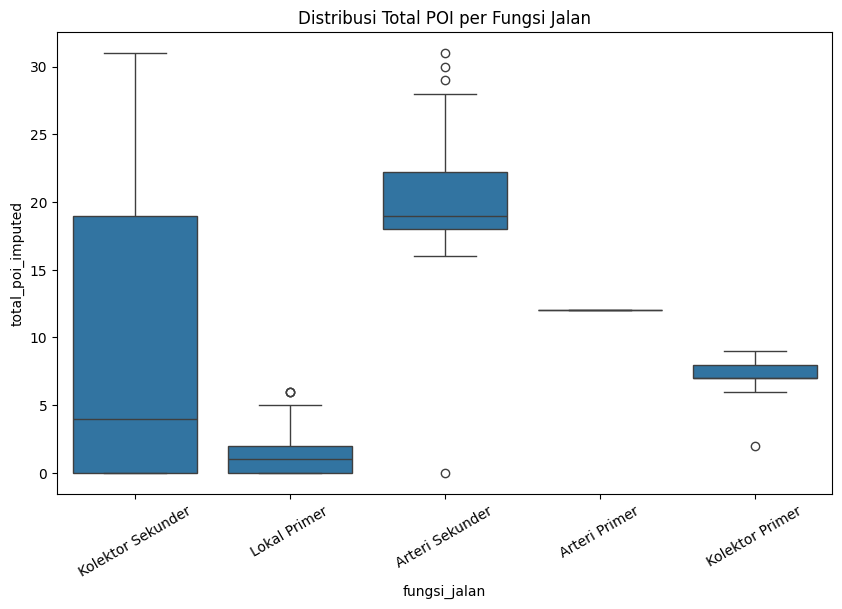

,mean,median,max
fungsi_jalan,,,
Arteri Sekunder,20.416667,19.0,31
Arteri Primer,12.000000,12.0,12
Kolektor Sekunder,9.832727,4.0,31
Kolektor Primer,7.105263,7.0,9
Lokal Primer,1.093458,1.0,6


In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_jalan_final,
    x='fungsi_jalan',
    y='total_poi_imputed'
)

plt.xticks(rotation=30)
plt.title('Distribusi Total POI per Fungsi Jalan')
plt.show()

# Statistik
fungsi_stats = (
    df_jalan_final
    .groupby('fungsi_jalan')['total_poi_imputed']
    .agg(['mean','median','max'])
    .sort_values('mean', ascending=False)
)

fungsi_stats

### Panjang Jalan vs Total POI

Untuk melihat apakah semakin panjang jalan, maka semakin banyak POI?

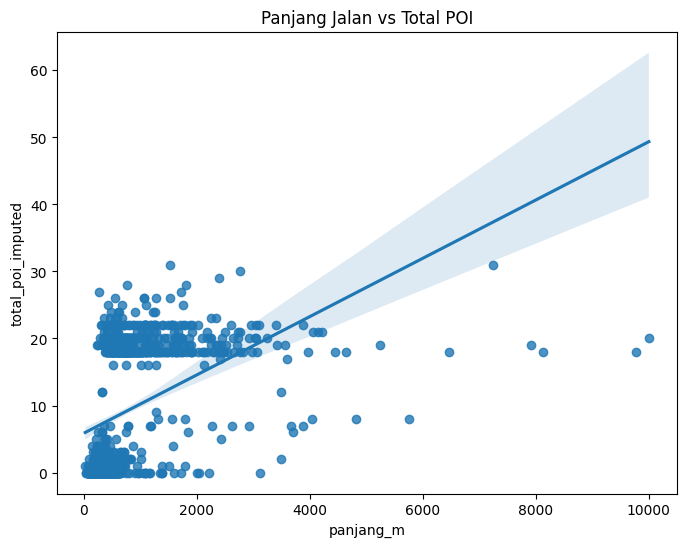

Korelasi: 0.442


In [ ]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df_jalan_final,
    x='panjang_m',
    y='total_poi_imputed'
)

plt.title('Panjang Jalan vs Total POI')
plt.show()

corr = df_jalan_final[['panjang_m','total_poi_imputed']].corr().iloc[0,1]

print(f'Korelasi: {corr:.3f}')

### Lebar Jalan vs Total POI

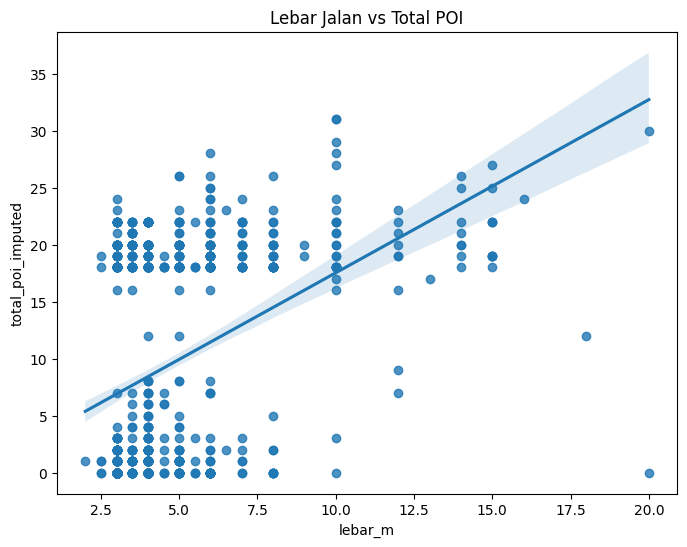

Korelasi: 0.381


In [ ]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df_jalan_final,
    x='lebar_m',
    y='total_poi_imputed'
)

plt.title('Lebar Jalan vs Total POI')
plt.show()

corr = df_jalan_final[['lebar_m','total_poi_imputed']].corr().iloc[0,1]

print(f'Korelasi: {corr:.3f}')

### Demand vs Kompetitor

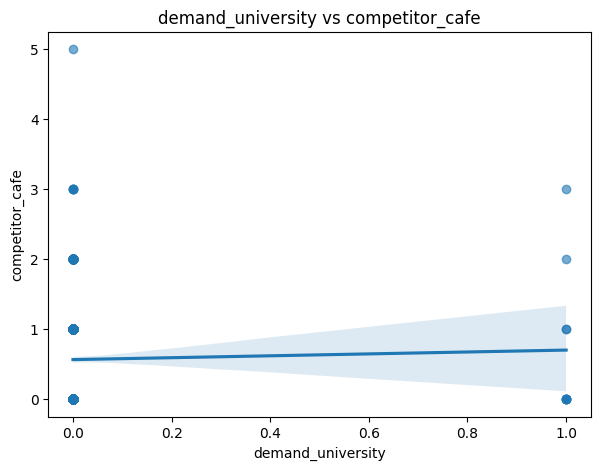

Korelasi demand_university vs competitor_cafe: 0.020
------------------------------------------------------------


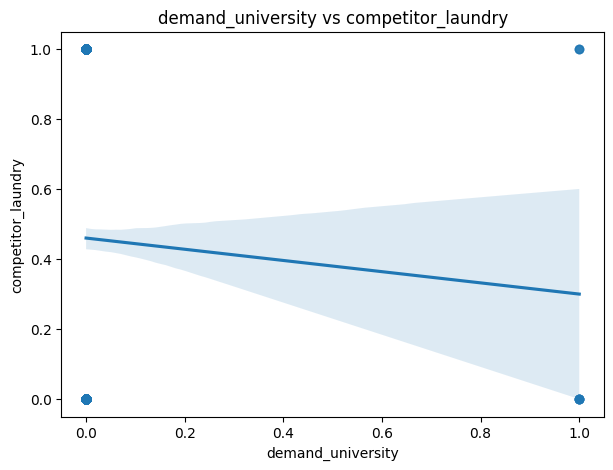

Korelasi demand_university vs competitor_laundry: -0.032
------------------------------------------------------------


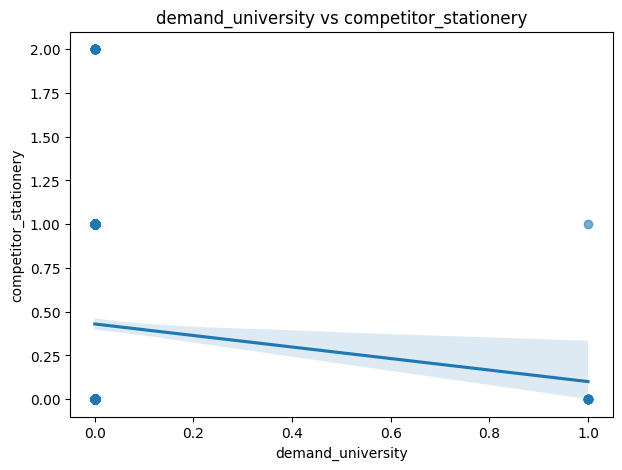

Korelasi demand_university vs competitor_stationery: -0.059
------------------------------------------------------------


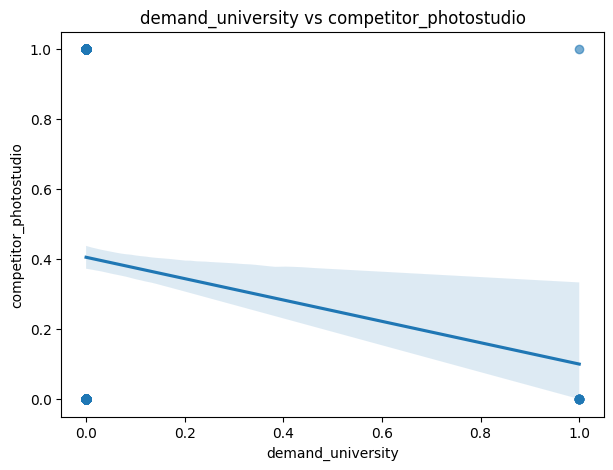

Korelasi demand_university vs competitor_photostudio: -0.062
------------------------------------------------------------


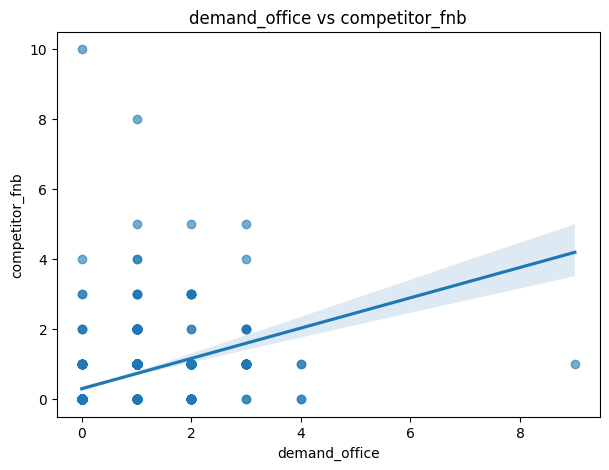

Korelasi demand_office vs competitor_fnb: 0.446
------------------------------------------------------------


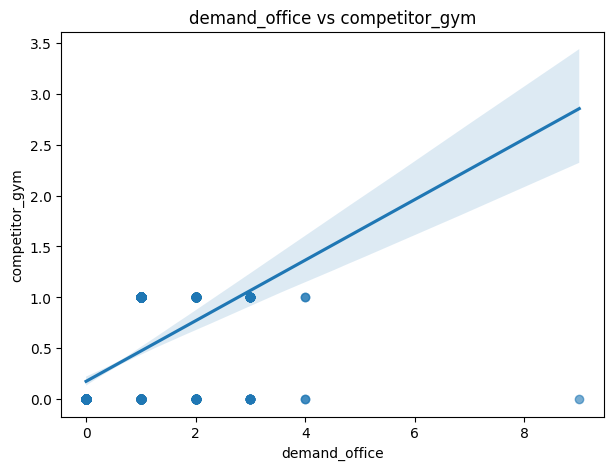

Korelasi demand_office vs competitor_gym: 0.520
------------------------------------------------------------


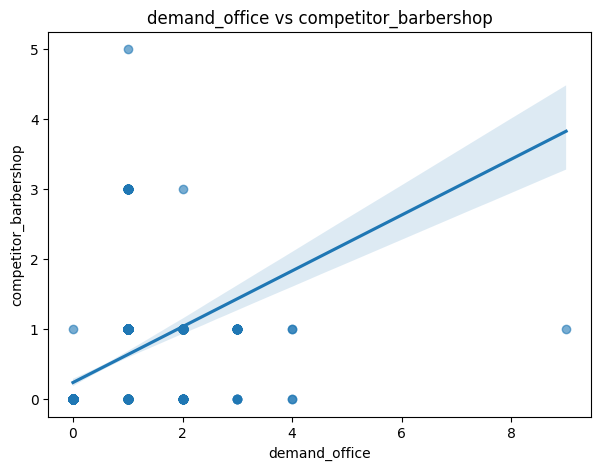

Korelasi demand_office vs competitor_barbershop: 0.485
------------------------------------------------------------


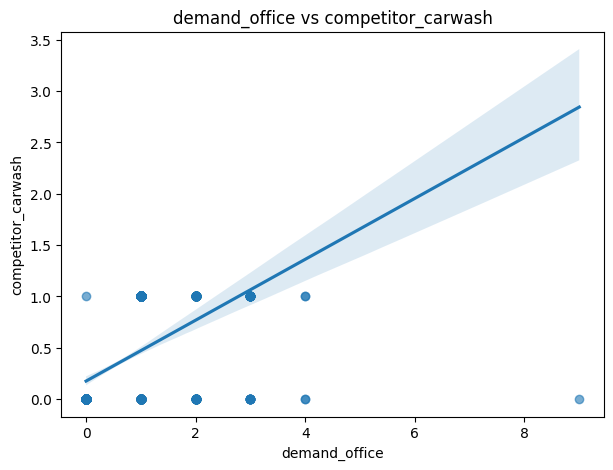

Korelasi demand_office vs competitor_carwash: 0.517
------------------------------------------------------------


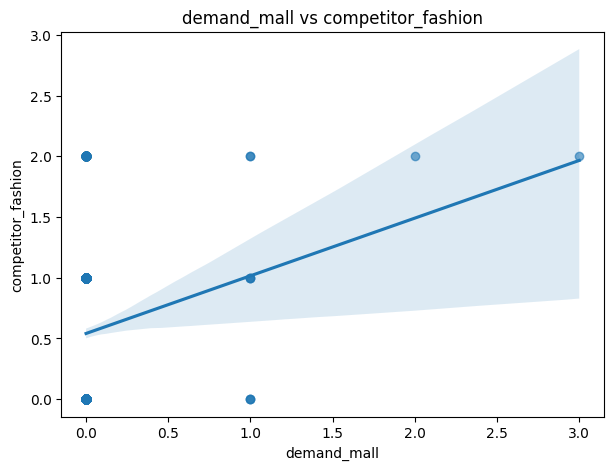

Korelasi demand_mall vs competitor_fashion: 0.105
------------------------------------------------------------


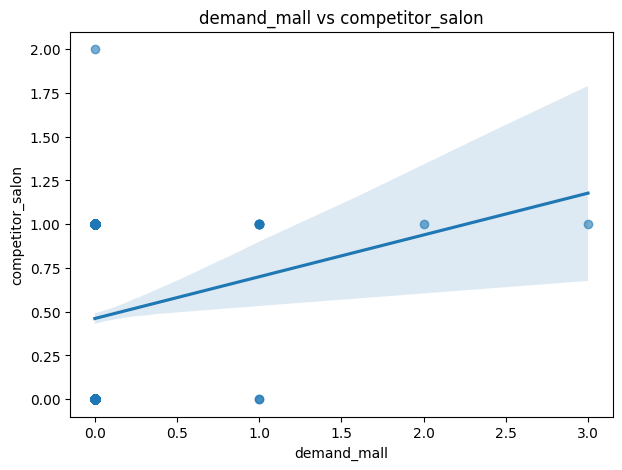

Korelasi demand_mall vs competitor_salon: 0.068
------------------------------------------------------------


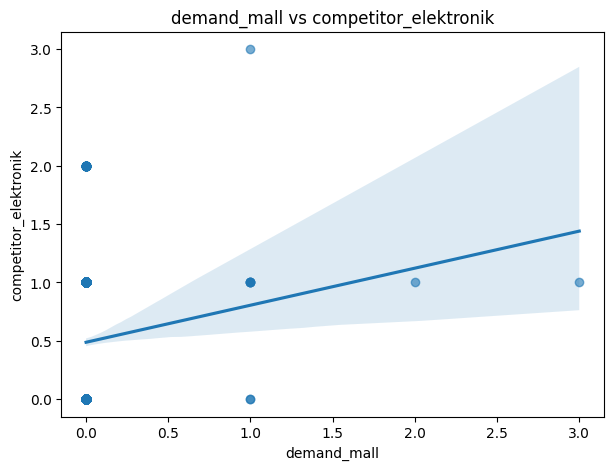

Korelasi demand_mall vs competitor_elektronik: 0.081
------------------------------------------------------------


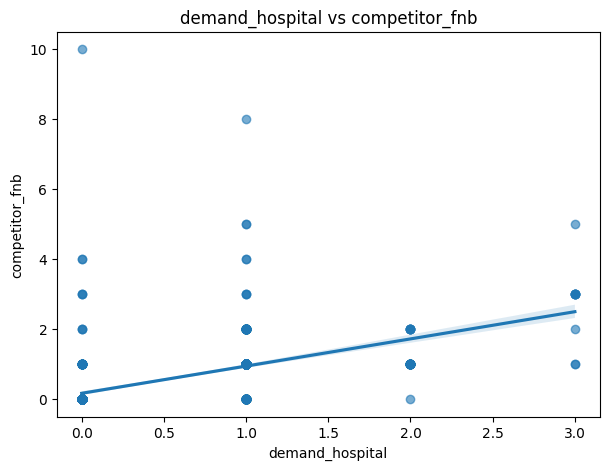

Korelasi demand_hospital vs competitor_fnb: 0.586
------------------------------------------------------------


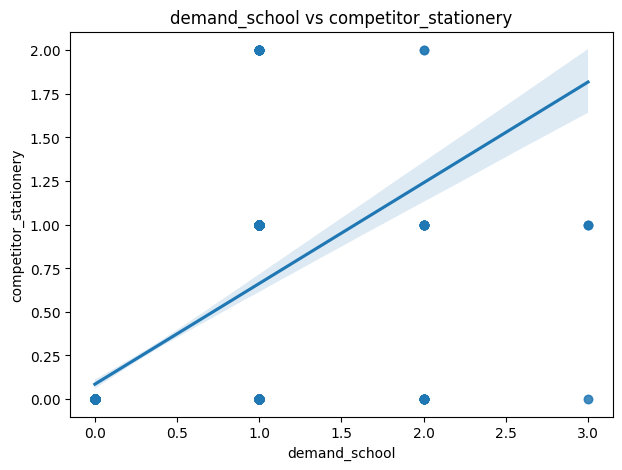

Korelasi demand_school vs competitor_stationery: 0.623
------------------------------------------------------------


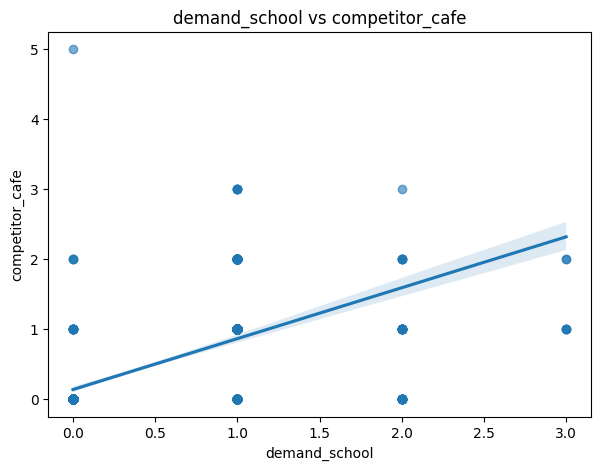

Korelasi demand_school vs competitor_cafe: 0.632
------------------------------------------------------------


In [ ]:
pair_analysis = [

    # Area kampus
    ('demand_university', 'competitor_cafe'),
    ('demand_university', 'competitor_laundry'),
    ('demand_university', 'competitor_stationery'),
    ('demand_university', 'competitor_photostudio'),

    # Area kantor / komersial
    ('demand_office', 'competitor_fnb'),
    ('demand_office', 'competitor_gym'),
    ('demand_office', 'competitor_barbershop'),
    ('demand_office', 'competitor_carwash'),

    # Area mall / retail
    ('demand_mall', 'competitor_fashion'),
    ('demand_mall', 'competitor_salon'),
    ('demand_mall', 'competitor_elektronik'),

    # Area hospital
    ('demand_hospital', 'competitor_fnb'),

    # Area sekolah
    ('demand_school', 'competitor_stationery'),
    ('demand_school', 'competitor_cafe'),
]

for demand, comp in pair_analysis:

    plt.figure(figsize=(7,5))

    sns.regplot(
        data=df_jalan_final,
        x=demand,
        y=comp,
        scatter_kws={'alpha':0.6}
    )

    plt.title(f'{demand} vs {comp}')
    plt.xlabel(demand)
    plt.ylabel(comp)

    plt.show()

    corr = df_jalan_final[[demand, comp]].corr().iloc[0,1]

    print(f'Korelasi {demand} vs {comp}: {corr:.3f}')
    print('-' * 60)

In [ ]:
pair_analysis = [

    ('demand_university', 'competitor_cafe'),
    ('demand_university', 'competitor_stationery'),
    ('demand_office', 'competitor_fnb'),
    ('demand_mall', 'competitor_fashion'),
    ('demand_hospital', 'competitor_fnb'),
]

## Multivariate Analysis

### Korelasi anatara Demand dan Competitor Jenis Usaha (Heatmap)

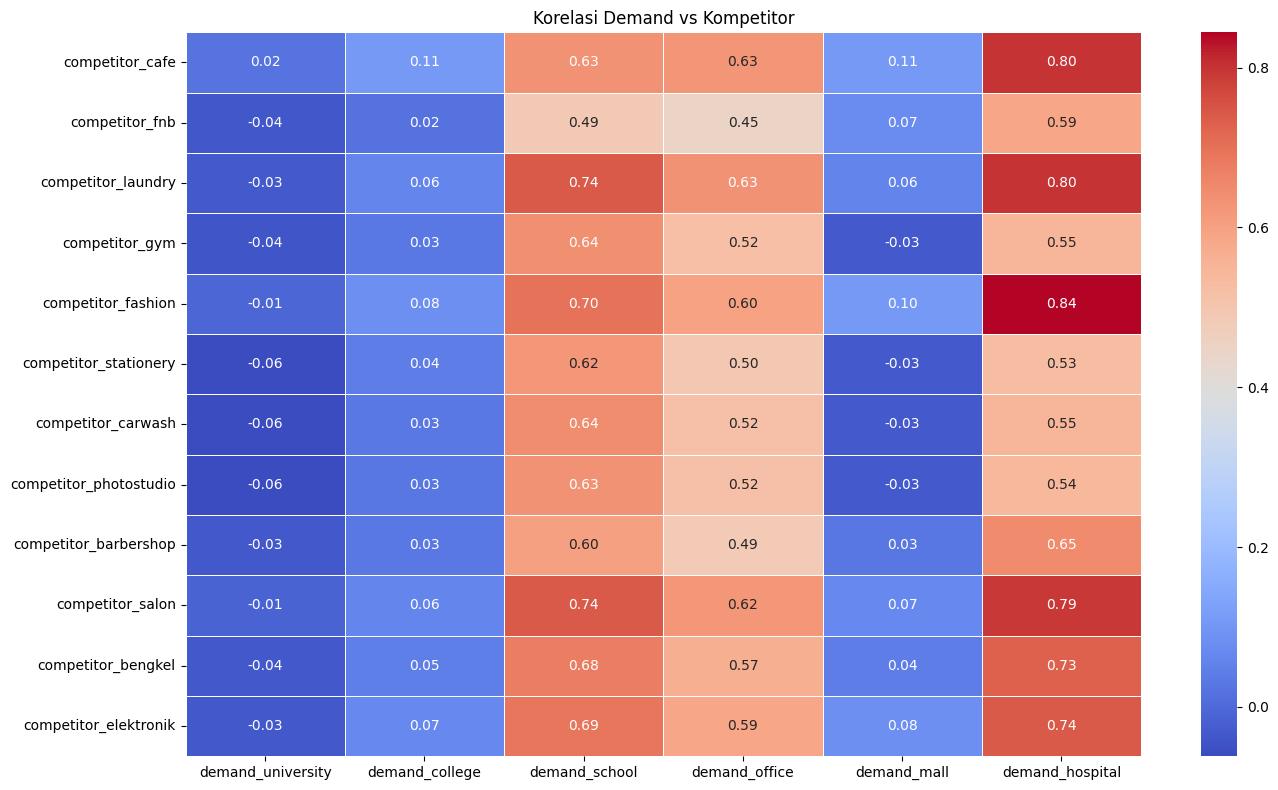

In [ ]:
# Kolom demand & competitor (pilih yang tersedia)
demand_cols = ['demand_university', 'demand_college', 'demand_school',
               'demand_office', 'demand_mall', 'demand_hospital']
usaha_cols = [c for c in df_jalan_final.columns if c.startswith('competitor_')]

# Hitung korelasi
corr_matrix = df_jalan_final[demand_cols + usaha_cols].corr()

# Plot heatmap (subset: demand vs competitor)
plt.figure(figsize=(14, 8))
sns.heatmap(corr_matrix.loc[usaha_cols, demand_cols],
            annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Korelasi Demand vs Kompetitor')
plt.tight_layout()
plt.show()

### Korelasi Panjang Jalan vs Total Kompetitor (Deteksi Bias)

Korelasi panjang jalan dengan kompetitor:
panjang_m                1.000000
competitor_fashion       0.445828
competitor_cafe          0.436846
competitor_laundry       0.406405
competitor_salon         0.405958
competitor_elektronik    0.381204
competitor_bengkel       0.363616
competitor_barbershop    0.361541
competitor_fnb           0.268758
competitor_carwash       0.242672
Name: panjang_m, dtype: float64


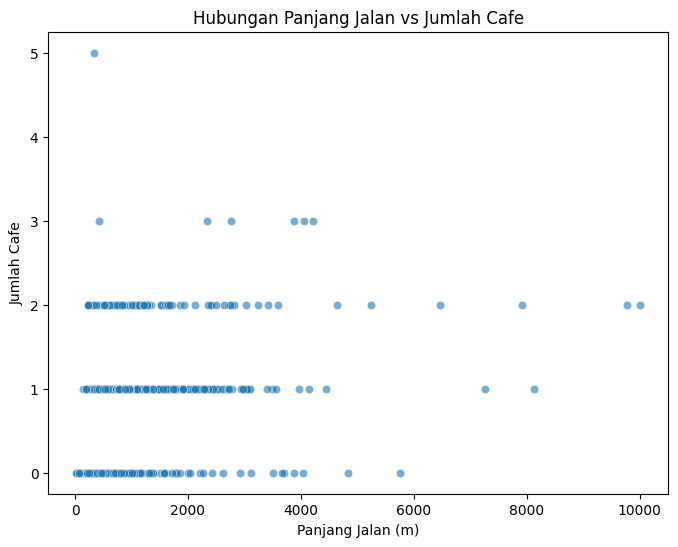

In [ ]:
# Cek korelasi panjang jalan dengan semua competitor
panjang_corr = df_jalan_final[['panjang_m'] + usaha_cols].corr()['panjang_m'].sort_values(ascending=False)
print("Korelasi panjang jalan dengan kompetitor:")
print(panjang_corr.head(10))

# Scatter plot untuk visualisasi
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_jalan_final, x='panjang_m', y='competitor_cafe', alpha=0.6)
plt.title('Hubungan Panjang Jalan vs Jumlah Cafe')
plt.xlabel('Panjang Jalan (m)')
plt.ylabel('Jumlah Cafe')
plt.show()

### Analisis Density Kompetitor vs Fungsi Jalan (Boxplot)

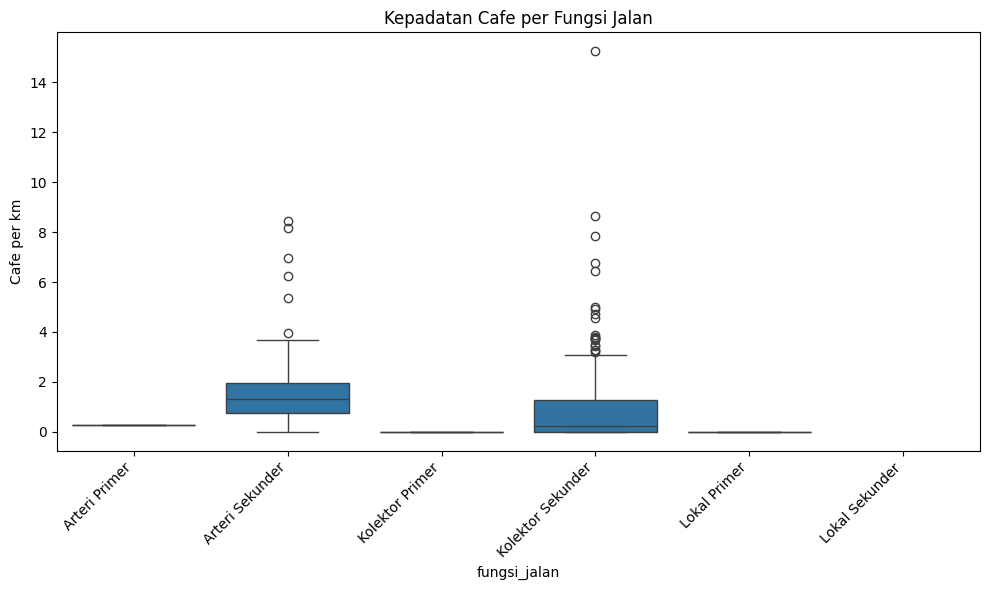

In [ ]:
# Buat density competitor (per km)
df_jalan_final['density_cafe'] = df_jalan_final['competitor_cafe'] / (df_jalan_final['panjang_m'] / 1000)  # per km

# Boxplot density per fungsi jalan
plt.figure(figsize=(10,6))
sns.boxplot(data=df_jalan_final, x='fungsi_jalan', y='density_cafe', order=[
    'Arteri Primer', 'Arteri Sekunder', 'Kolektor Primer',
    'Kolektor Sekunder', 'Lokal Primer', 'Lokal Sekunder'
])
plt.xticks(rotation=45, ha='right')
plt.title('Kepadatan Cafe per Fungsi Jalan')
plt.ylabel('Cafe per km')
plt.tight_layout()
plt.show()

### Hubungan Traffic Score vs Jumlah Kompetitor (Scatter + Regresi)

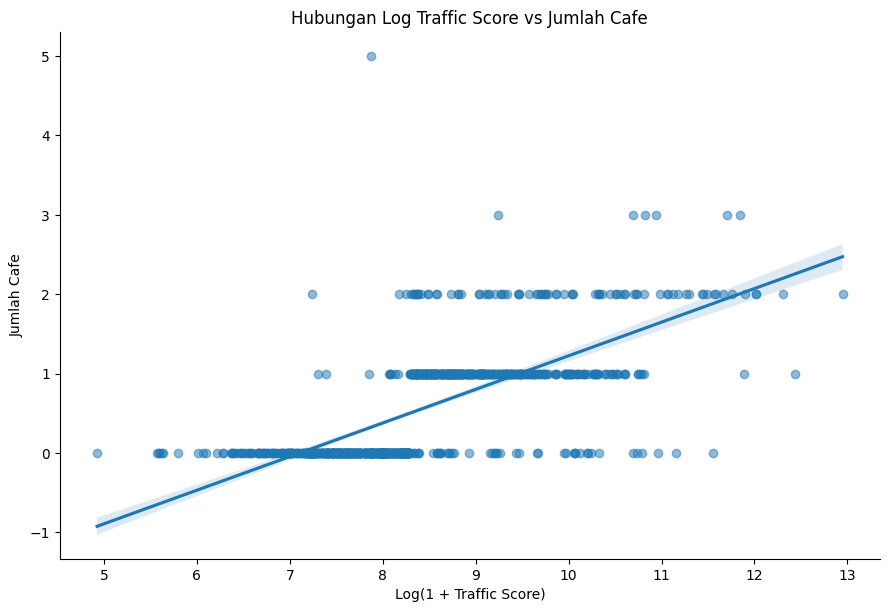

In [ ]:
# Log transform traffic_score untuk visualisasi yang lebih baik
df_jalan_final['log_traffic'] = np.log1p(df_jalan_final['traffic_score'])

sns.lmplot(data=df_jalan_final, x='log_traffic', y='competitor_cafe',
           height=6, aspect=1.5, scatter_kws={'alpha':0.5})
plt.title('Hubungan Log Traffic Score vs Jumlah Cafe')
plt.xlabel('Log(1 + Traffic Score)')
plt.ylabel('Jumlah Cafe')
plt.show()

### Analisis Transit Score vs Density Kompetitor (Pairwise Correlations)

Korelasi transit_score dengan kompetitor:
transit_score            1.000000
competitor_fashion       0.135836
competitor_cafe          0.129866
competitor_fnb           0.127194
competitor_elektronik    0.107014
competitor_barbershop    0.097747
competitor_laundry       0.063248
competitor_salon         0.060920
competitor_bengkel       0.054944
competitor_stationery   -0.018557
Name: transit_score, dtype: float64


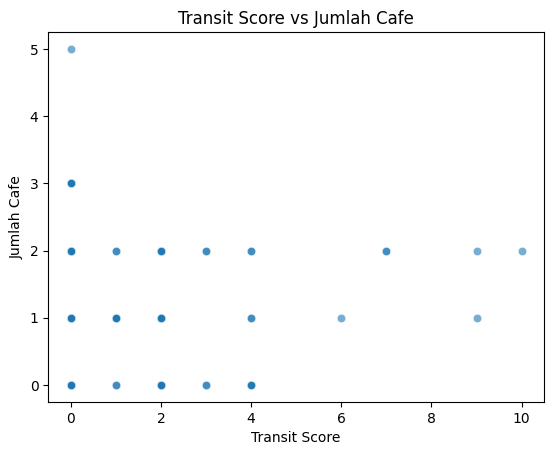

In [ ]:
# Korelasi transit_score dengan semua kompetitor
transit_corr = df_jalan_final[['transit_score'] + usaha_cols].corr()['transit_score'].sort_values(ascending=False)
print("Korelasi transit_score dengan kompetitor:")
print(transit_corr.head(10))

# Scatter plot untuk cafe
sns.scatterplot(data=df_jalan_final, x='transit_score', y='competitor_cafe', alpha=0.6)
plt.title('Transit Score vs Jumlah Cafe')
plt.xlabel('Transit Score')
plt.ylabel('Jumlah Cafe')
plt.show()

### Coretan

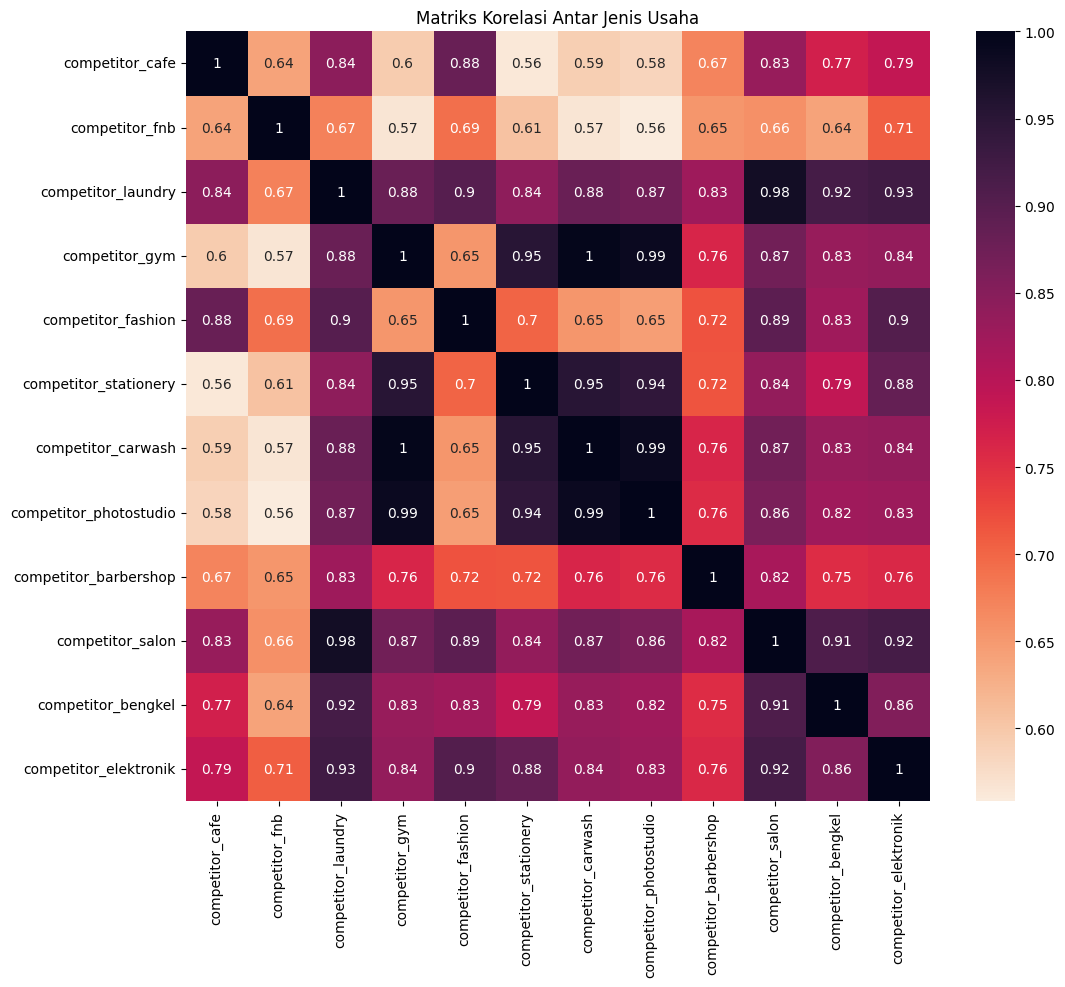

In [ ]:
competitor_cols = [col for col in df_jalan_final.columns if 'competitor_' in col]

plt.figure(figsize=(12, 10))
sns.heatmap(df_jalan_final[competitor_cols].corr(), annot=True, cmap='rocket_r')
plt.title('Matriks Korelasi Antar Jenis Usaha')
plt.show()

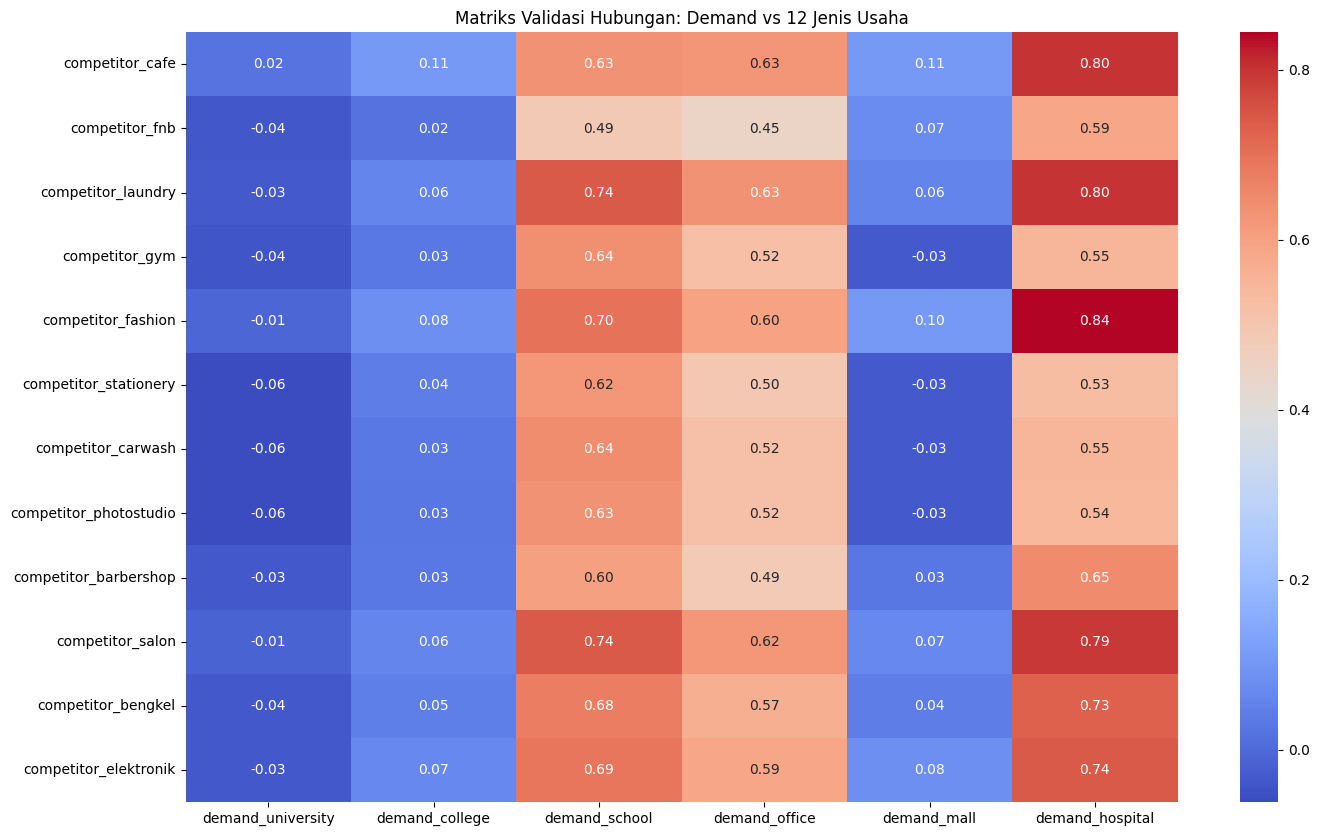

In [ ]:
# 1. Daftar semua demand (Potensial Feature)
demand_cols = [
    'demand_university', 'demand_college', 'demand_school',
    'demand_office', 'demand_mall', 'demand_hospital'
]

# 2. Daftar semua kompetitor (Target)
usaha_cols = [
    'competitor_cafe', 'competitor_fnb', 'competitor_laundry', 'competitor_gym',
    'competitor_fashion', 'competitor_stationery', 'competitor_carwash',
    'competitor_photostudio', 'competitor_barbershop', 'competitor_salon',
    'competitor_bengkel', 'competitor_elektronik'
]

# 3. Gabungkan dalam satu matriks korelasi
plt.figure(figsize=(16, 10))
full_corr = df_jalan_final[demand_cols + usaha_cols].corr()

# Kita filter agar hanya menampilkan korelasi antara Demand vs Usaha saja
# Agar heatmap tidak terlalu padat dan fokus pada tujuan FE
sns.heatmap(full_corr.loc[usaha_cols, demand_cols], annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Matriks Validasi Hubungan: Demand vs 12 Jenis Usaha')
plt.show()

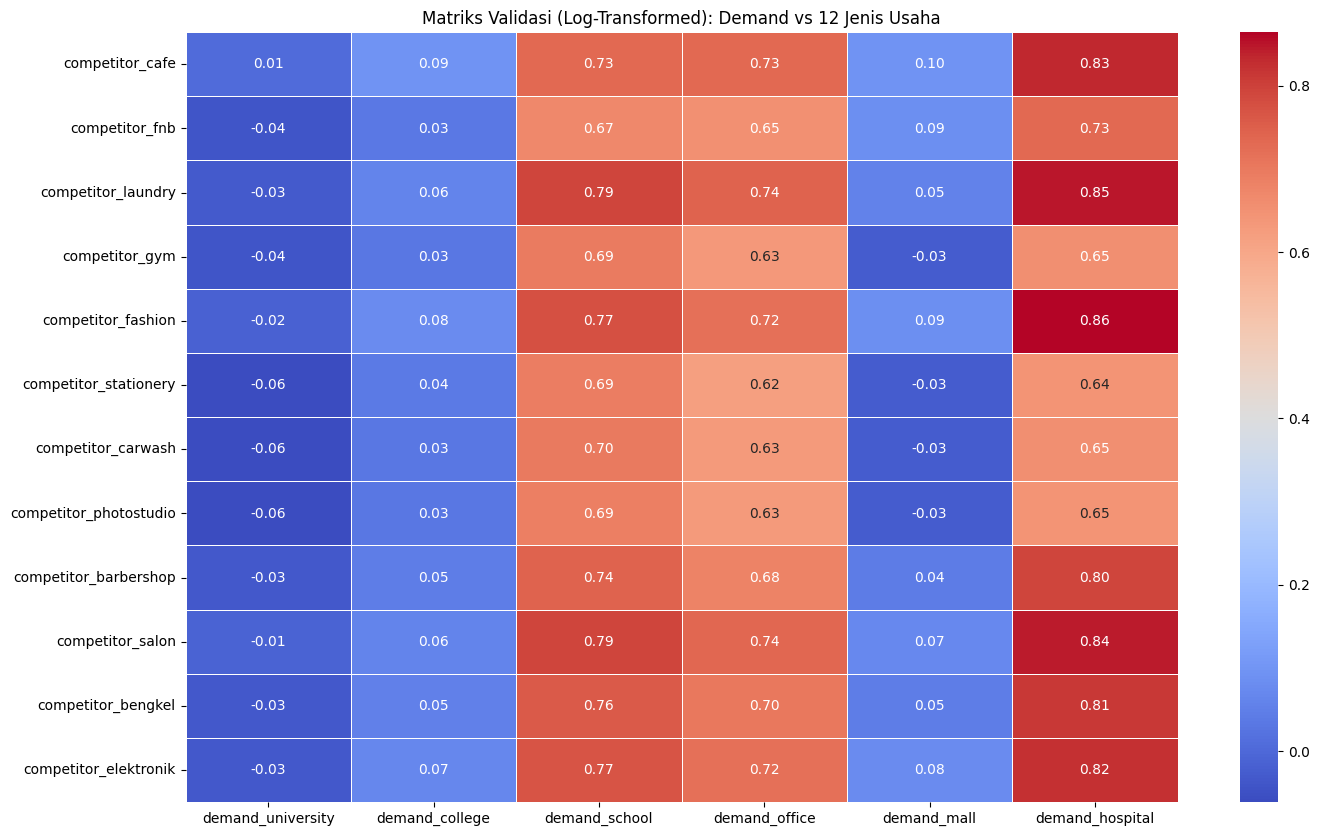

In [ ]:
# 1. Daftar semua demand
demand_cols = [
    'demand_university', 'demand_college', 'demand_school',
    'demand_office', 'demand_mall', 'demand_hospital'
]

# 2. Daftar semua kompetitor
usaha_cols = [
    'competitor_cafe', 'competitor_fnb', 'competitor_laundry', 'competitor_gym',
    'competitor_fashion', 'competitor_stationery', 'competitor_carwash',
    'competitor_photostudio', 'competitor_barbershop', 'competitor_salon',
    'competitor_bengkel', 'competitor_elektronik'
]

# 3. Transformasi log1p pada copy temporary agar df asli tetap aman
# Kita hanya mengambil kolom yang relevan saja untuk efisiensi
df_temp_log = np.log1p(df_jalan_final[demand_cols + usaha_cols])

# 4. Hitung korelasi dari data yang sudah di-log
full_corr_log = df_temp_log.corr()

# 5. Visualisasi Heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(
    full_corr_log.loc[usaha_cols, demand_cols],
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Matriks Validasi (Log-Transformed): Demand vs 12 Jenis Usaha')
plt.show()

In [ ]:
df_jalan_final.columns

Index(['nama_jalan', 'kecamatan', 'kelurahan', 'lat_centroid', 'lng_centroid',
       'fungsi_jalan', 'panjang_m', 'lebar_m', 'competitor_cafe',
       'competitor_fnb', 'competitor_laundry', 'competitor_gym',
       'competitor_fashion', 'competitor_stationery', 'competitor_carwash',
       'competitor_photostudio', 'competitor_barbershop', 'competitor_salon',
       'competitor_bengkel', 'competitor_elektronik', 'demand_university',
       'demand_college', 'demand_school', 'demand_office', 'demand_mall',
       'demand_hospital', 'transit_bus_stop', 'transit_bus_station',
       'transit_train_station', 'transit_public_transport', 'total_poi_asli',
       'bobot_fungsi', 'traffic_score', 'transit_score', 'total_poi_imputed',
       'total_poi', 'density_cafe', 'log_traffic'],
      dtype='object')

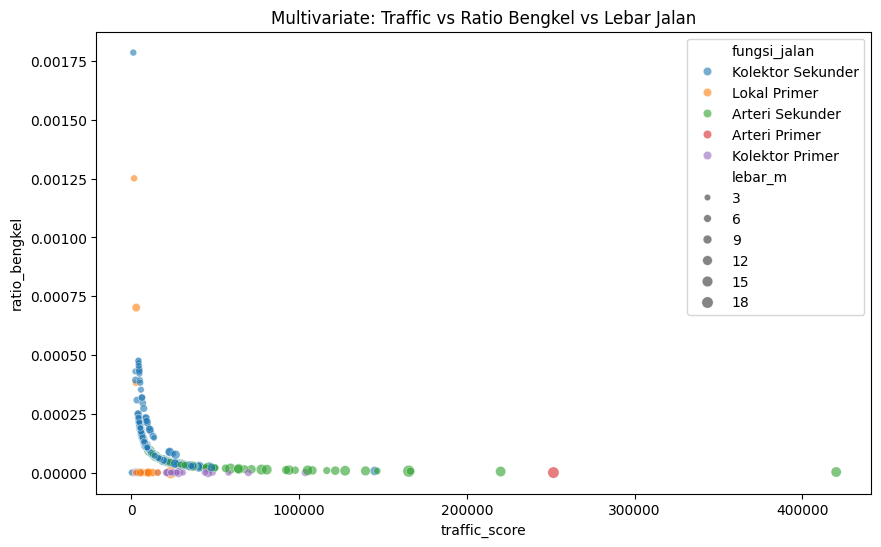

In [ ]:
# Contoh Analisis Rasio untuk Bengkel
df_jalan_final['ratio_bengkel'] = df_jalan_final['competitor_bengkel'] / (df_jalan_final['traffic_score'] + 1)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_jalan_final, x='traffic_score', y='ratio_bengkel',
                hue='fungsi_jalan', size='lebar_m', alpha=0.6)
plt.title('Multivariate: Traffic vs Ratio Bengkel vs Lebar Jalan')
plt.show()

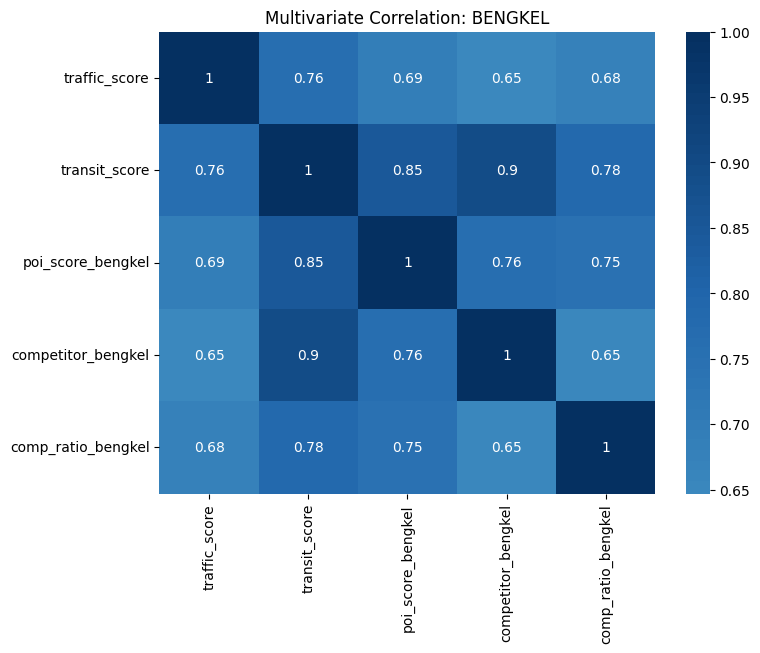

In [ ]:
# Analisis Khusus Bengkel
target = 'bengkel'
features_bengkel = ['traffic_score', 'transit_score', f'poi_score_{target}', f'competitor_{target}', f'comp_ratio_{target}']

plt.figure(figsize=(8, 6))
sns.heatmap(df_fe[features_bengkel].corr(), annot=True, cmap='RdBu', center=0)
plt.title(f'Multivariate Correlation: {target.upper()}')
plt.show()

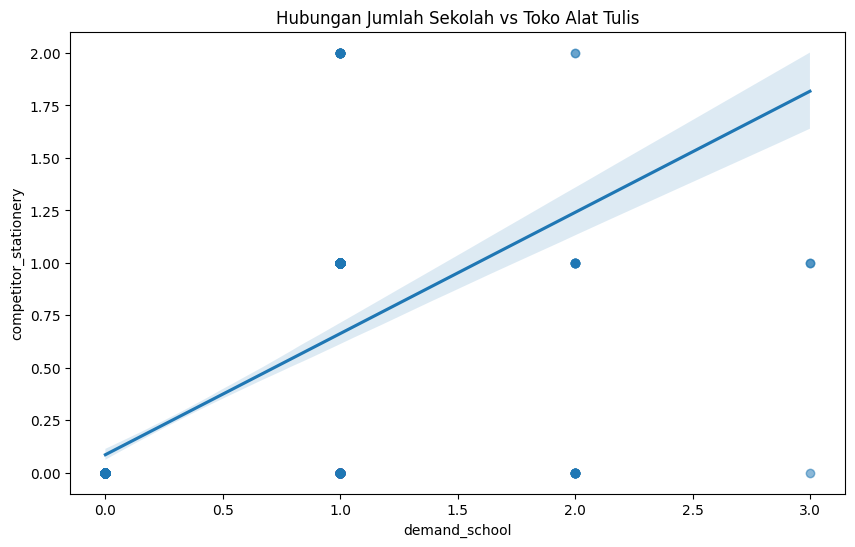

In [ ]:
# Scatter plot untuk melihat hubungan spesifik
plt.figure(figsize=(10, 6))
sns.regplot(data=df_jalan_final, x='demand_school', y='competitor_stationery', scatter_kws={'alpha':0.3})
plt.title('Hubungan Jumlah Sekolah vs Toko Alat Tulis')
plt.show()

# **DATA PREPARATION**

## Data Type

## Missing Value

## Outlier

## Business Feature Engineering

**Urutan:**
```
Raw count → log1p → Hitung komponen POI → Hitung poi_score & comp_ratio
```

**Variabel yang dihasilkan:**

| Variabel | Formula | Makna |
|---|---|---|
| `poi_akademik` | univ×3 + college×3 + school×1 | Proxy demand segmen akademik |
| `poi_komersial` | office×3 + mall×2 + hospital×1 | Proxy demand segmen komersial |
| `transit_score` | station×3 + terminal×2 + halte×1 + angkot×1 | Proxy aksesibilitas transportasi |
| `comp_ratio_{usaha}` | poi_score / (competitor + 1) | Rasio demand vs persaingan |

In [ ]:
df_fe = df_jalan_final.copy()
#df_fe = pd.read_excel("https://docs.google.com/spreadsheets/d/-V2Ke97LfrTROo/export?format=xlsx")
df_fe

,nama_jalan,kecamatan,kelurahan,lat_centroid,lng_centroid,fungsi_jalan,panjang_m,lebar_m,competitor_cafe,competitor_fnb,...,transit_public_transport,total_poi_asli,bobot_fungsi,traffic_score,transit_score,total_poi_imputed,total_poi,density_cafe,log_traffic,ratio_bengkel
0,Jl. Abimanyu,Semarang Tengah,Pendrikan Lor,-6.977414,110.409872,Kolektor Sekunder,240.40,4.0,0,0,...,0,1,2,1923.200,0,1,1,0.0,7.562266,0.0
1,Jl. Ade Irma Suryani Nasution,Semarang Tengah,Sekayu,-6.974783,110.415214,Lokal Primer,529.71,7.0,0,0,...,0,0,1,3707.970,0,0,0,0.0,8.218509,0.0
2,Jl. Alun-Alun Barat,Semarang Tengah,Kauman,-6.971964,110.423453,Kolektor Sekunder,216.76,3.0,0,0,...,0,0,2,1300.560,0,0,0,0.0,7.171319,0.0
3,Jl. Alun-Alun Timur,Semarang Tengah,Kauman,-6.970721,110.424190,Kolektor Sekunder,168.21,10.0,0,0,...,0,0,2,3364.200,0,0,0,0.0,8.121243,0.0
4,Jl. Anggrek,Semarang Tengah,Pekunden,-6.988915,110.423814,Lokal Primer,338.87,5.5,0,1,...,0,3,1,1863.785,0,3,3,0.0,7.530901,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1007,Jl. Pulau Tirang Tapak,Tugu,Tugurejo,-6.970596,110.346220,Lokal Primer,2029.33,3.0,0,0,...,0,0,1,6087.990,0,0,0,0.0,8.714238,0.0
1008,Jl. Stasiun Jraka,Tugu,Jerakah,-6.983850,110.363077,Lokal Primer,706.21,3.5,0,0,...,0,2,1,2471.735,0,2,2,0.0,7.813080,0.0
1009,Jl. Stasiun Mangkang,Tugu,Mangkang Wetan,-6.972243,110.304174,Kolektor Primer,253.06,3.5,0,0,...,1,2,3,2657.130,2,2,4,0.0,7.885378,0.0
1010,Jl. Tapak,Tugu,Tugurejo,-6.982313,110.344949,Lokal Primer,864.77,4.0,0,0,...,1,4,1,3459.080,2,4,6,0.0,8.149047,0.0


In [ ]:
# Bobot fungsi jalan
BOBOT_FUNGSI = {
    'Arteri Primer'    : 4,
    'Arteri Sekunder'  : 3,
    'Kolektor Primer'  : 3,
    'Kolektor Sekunder': 2,
    'Lokal Primer'     : 1,
    'Lokal Sekunder'   : 1,
}
df_fe['bobot_fungsi'] = df_fe['fungsi_jalan'].map(BOBOT_FUNGSI)

In [ ]:
# Variabel traffic_score
df_fe['traffic_score'] = df_fe['panjang_m'] * df_fe['lebar_m'] * df_fe['bobot_fungsi']

In [ ]:
# Definisi
TAGS_POI = {

    # Kompetitor
    'competitor_cafe'       : {'amenity': ['cafe']},
    'competitor_fnb'        : {'amenity': ['restaurant', 'fast_food', 'food_court']},
    'competitor_laundry'    : {'shop': ['laundry', 'dry_cleaning']},
    'competitor_gym'        : {'leisure': ['fitness_centre', 'sports_centre']},
    'competitor_fashion'    : {'shop': ['clothes', 'fashion', 'boutique']},
    'competitor_stationery' : {'shop': 'stationery'},
    'competitor_carwash'    : {'amenity': 'car_wash'},
    'competitor_photostudio': {'shop': ['photo', 'photo_studio']},
    'competitor_barbershop' : {'shop': ['barber', 'hairdresser']},
    'competitor_salon'      : {'shop': ['beauty', 'nail_salon']},
    'competitor_bengkel'    : {'shop': ['car_repair', 'motorcycle_repair', 'vehicle']},
    'competitor_elektronik' : {'shop': ['electronics', 'computer', 'mobile_phone']},

    # Demand
    'demand_university'     : {'amenity': 'university'},
    'demand_college'        : {'amenity': 'college'},
    'demand_school'         : {'amenity': 'school'},
    'demand_office'         : {'office': True},
    'demand_mall'           : {'shop': 'mall'},
    'demand_hospital'       : {'amenity': ['hospital', 'clinic']},

    # Transit
    'transit_bus_stop'         : {'highway': 'bus_stop'},
    'transit_bus_station'      : {'amenity': 'bus_station'},
    'transit_train_station'    : {'railway': ['station', 'halt']},
    'transit_public_transport' : {'public_transport': 'stop_position'},
}

POI_COLS = list(TAGS_POI.keys())

## Transform Log(x+1)

In [ ]:
# Log transform log1p(x) = log(x+1)
df_fe[POI_COLS] = df_fe[POI_COLS].apply(np.log1p)
df_fe['traffic_score'] = np.log1p(df_fe['traffic_score'])

In [ ]:
# Indikator poi_akademik dan poi_komersial

# POI akademik: mahasiswa (univ/college) daya beli lebih tinggi dari pelajar
df_fe['poi_akademik'] = (
    df_fe['demand_university'] * 3 +
    df_fe['demand_college']    * 3 +
    df_fe['demand_school']     * 1
)

# POI komersial: kantor mendatangkan ratusan orang konsisten setiap hari
df_fe['poi_komersial'] = (
    df_fe['demand_office']   * 3 +
    df_fe['demand_mall']     * 2 +
    df_fe['demand_hospital'] * 1
)

In [ ]:
# Variabel transit_score
df_fe['transit_score'] = (
    df_fe['transit_train_station']    * 3 +
    df_fe['transit_bus_station']      * 2 +
    df_fe['transit_bus_stop']         * 1 +
    df_fe['transit_public_transport'] * 1
)

In [ ]:
# Variabel poi_score_{usaha} dan comp_ratio_{usaha}
JENIS_USAHA = {
    # POI akademik: pelanggan utama mahasiswa/pelajar
    'cafe'        : 'poi_akademik',
    'laundry'     : 'poi_akademik',
    'stationery'  : 'poi_akademik',
    'photostudio' : 'poi_akademik',
    'barbershop'  : 'poi_akademik',

    # POI komersial: pelanggan utama pekerja kantoran
    'fnb'         : 'poi_komersial',
    'gym'         : 'poi_komersial',
    'salon'       : 'poi_komersial',
    'elektronik'  : 'poi_komersial',
    'fashion'     : 'poi_komersial',
    'bengkel'     : 'poi_komersial',
    'carwash'     : 'poi_komersial',
}

for usaha, poi_col in JENIS_USAHA.items():
    comp_col = f'competitor_{usaha}'
    # poi_score: seberapa besar potensi demand di jalan ini untuk usaha tsb
    df_fe[f'poi_score_{usaha}']  = df_fe[poi_col]
    # comp_ratio: rasio demand vs kompetitor → makin tinggi = makin menarik
    df_fe[f'comp_ratio_{usaha}'] = df_fe[poi_col] / (df_fe[comp_col] + 1)

In [ ]:
print(f'\nVariabel baru yang terbentuk:')
print(f'  traffic_score, transit_score')
print(f'  poi_score_{{usaha}}  × {len(JENIS_USAHA)} jenis usaha')
print(f'  comp_ratio_{{usaha}} × {len(JENIS_USAHA)} jenis usaha')


Variabel baru yang terbentuk:
  traffic_score, transit_score
  poi_score_{usaha}  × 12 jenis usaha
  comp_ratio_{usaha} × 12 jenis usaha


In [ ]:
df_fe

,nama_jalan,kecamatan,kelurahan,lat_centroid,lng_centroid,fungsi_jalan,panjang_m,lebar_m,competitor_cafe,competitor_fnb,...,poi_score_salon,comp_ratio_salon,poi_score_elektronik,comp_ratio_elektronik,poi_score_fashion,comp_ratio_fashion,poi_score_bengkel,comp_ratio_bengkel,poi_score_carwash,comp_ratio_carwash
0,Jl. Abimanyu,Semarang Tengah,Pendrikan Lor,-6.977414,110.409872,Kolektor Sekunder,240.40,4.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,Jl. Ade Irma Suryani Nasution,Semarang Tengah,Sekayu,-6.974783,110.415214,Lokal Primer,529.71,7.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,Jl. Alun-Alun Barat,Semarang Tengah,Kauman,-6.971964,110.423453,Kolektor Sekunder,216.76,3.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,Jl. Alun-Alun Timur,Semarang Tengah,Kauman,-6.970721,110.424190,Kolektor Sekunder,168.21,10.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,Jl. Anggrek,Semarang Tengah,Pekunden,-6.988915,110.423814,Lokal Primer,338.87,5.5,0.0,0.693147,...,1.386294,0.818768,1.386294,1.386294,1.386294,1.386294,1.386294,1.386294,1.386294,1.386294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1007,Jl. Pulau Tirang Tapak,Tugu,Tugurejo,-6.970596,110.346220,Lokal Primer,2029.33,3.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1008,Jl. Stasiun Jraka,Tugu,Jerakah,-6.983850,110.363077,Lokal Primer,706.21,3.5,0.0,0.000000,...,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147
1009,Jl. Stasiun Mangkang,Tugu,Mangkang Wetan,-6.972243,110.304174,Kolektor Primer,253.06,3.5,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1010,Jl. Tapak,Tugu,Tugurejo,-6.982313,110.344949,Lokal Primer,864.77,4.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [ ]:
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1012 entries, 0 to 1011
Data columns (total 65 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   nama_jalan                1012 non-null   object 
 1   kecamatan                 1012 non-null   object 
 2   kelurahan                 1012 non-null   object 
 3   lat_centroid              1012 non-null   float64
 4   lng_centroid              1012 non-null   float64
 5   fungsi_jalan              1012 non-null   object 
 6   panjang_m                 1012 non-null   float64
 7   lebar_m                   1012 non-null   float64
 8   competitor_cafe           1012 non-null   float64
 9   competitor_fnb            1012 non-null   float64
 10  competitor_laundry        1012 non-null   float64
 11  competitor_gym            1012 non-null   float64
 12  competitor_fashion        1012 non-null   float64
 13  competitor_stationery     1012 non-null   float64
 14  competit

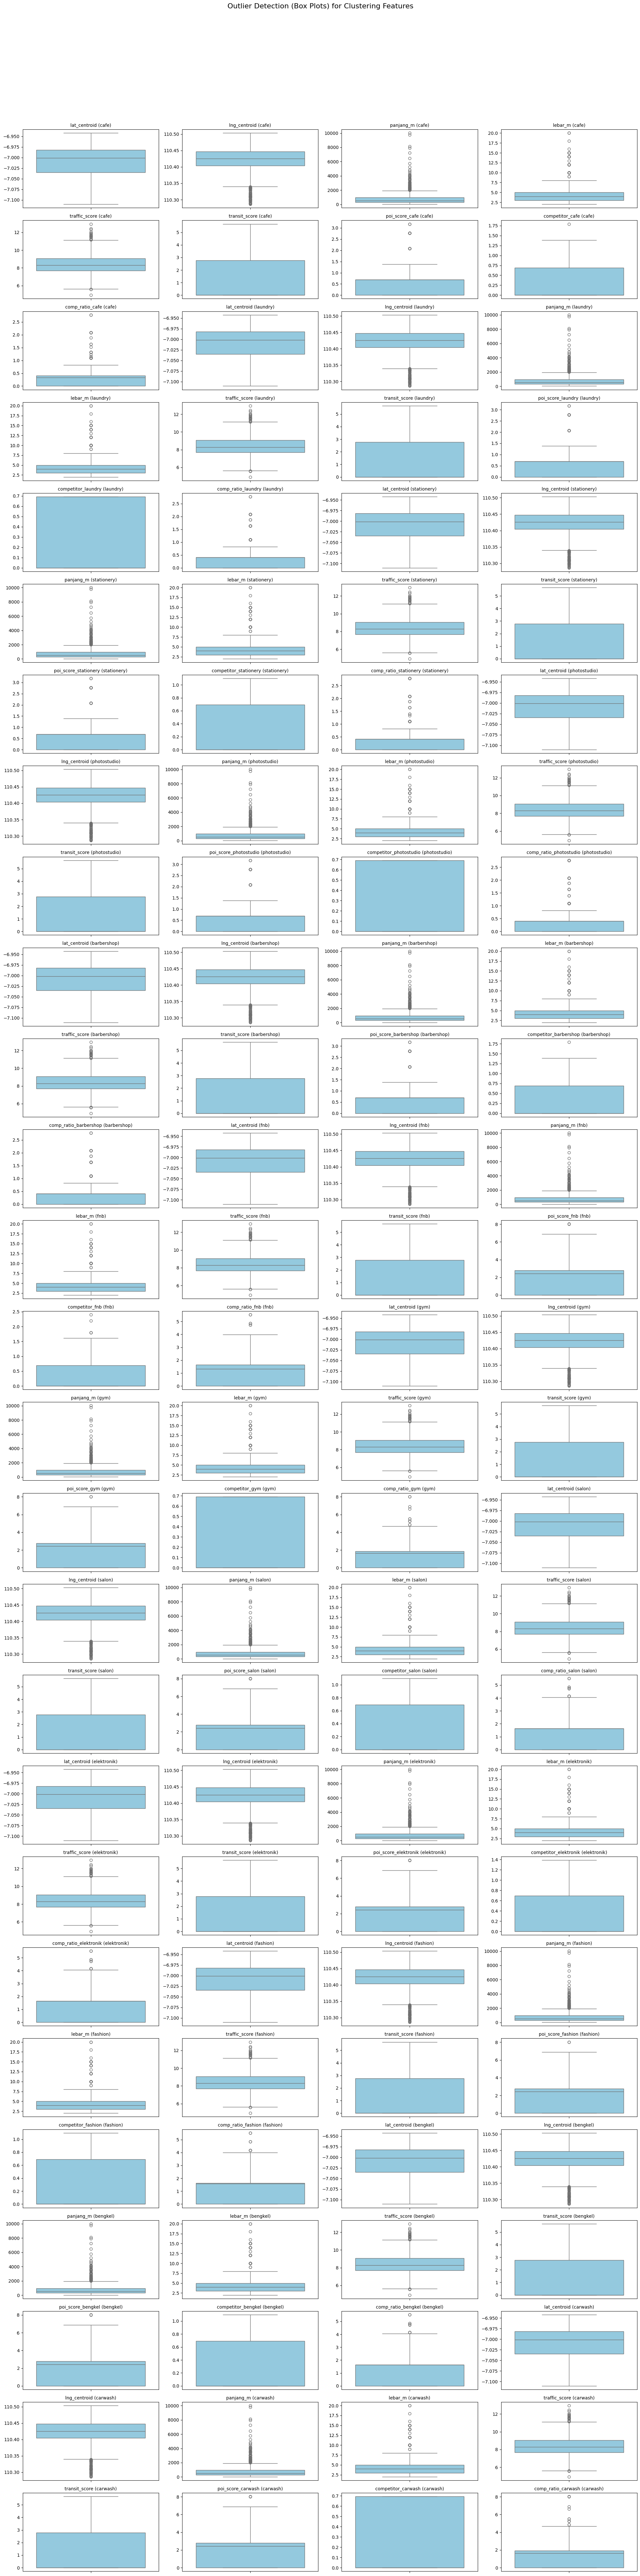

In [ ]:
FITUR_KONTEKS = [
    'lat_centroid', 'lng_centroid', 'panjang_m', 'lebar_m',
    'traffic_score', 'transit_score'
]

def get_fitur(usaha):
    """Fitur clustering untuk satu jenis usaha."""
    return FITUR_KONTEKS + [
        f'poi_score_{usaha}',
        f'competitor_{usaha}',
        f'comp_ratio_{usaha}',
    ]

JENIS_USAHA = {
    'cafe'        : 'poi_akademik',
    'laundry'     : 'poi_akademik',
    'stationery'  : 'poi_akademik',
    'photostudio' : 'poi_akademik',
    'barbershop'  : 'poi_akademik',
    'fnb'         : 'poi_komersial',
    'gym'         : 'poi_komersial',
    'salon'       : 'poi_komersial',
    'elektronik'  : 'poi_komersial',
    'fashion'     : 'poi_komersial',
    'bengkel'     : 'poi_komersial',
    'carwash'     : 'poi_komersial',
}

# Visualize outliers using box plots for each feature set
n_features = len(FITUR_KONTEKS) + 3 # 2 context features + 3 business-specific features
n_cols = 4
n_rows = (len(JENIS_USAHA) * n_features) // n_cols + (1 if (len(JENIS_USAHA) * n_features) % n_cols else 0)

plt.figure(figsize=(n_cols * 5, n_rows * 3))
plt.suptitle('Outlier Detection (Box Plots) for Clustering Features', fontsize=16, y=1.02)

plot_idx = 1
for usaha in JENIS_USAHA:
    features_to_plot = get_fitur(usaha)

    for feature in features_to_plot:
        ax = plt.subplot(n_rows, n_cols, plot_idx)
        sns.boxplot(y=df_fe[feature], ax=ax, color='skyblue')
        ax.set_title(f'{feature} ({usaha})', fontsize=10)
        ax.set_ylabel('')
        plot_idx += 1

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

In [ ]:
df_fe.to_excel('df_fe_CleanUnScaled.xlsx', index=False)

## Normalisasi

In [ ]:
X_SCALED = {}
SCALERS = {}

for usaha in JENIS_USAHA:
    fitur = get_fitur(usaha)
    scaler = MinMaxScaler()
    X_SCALED[usaha] = scaler.fit_transform(df_fe[fitur])
    SCALERS[usaha] = scaler

print(f'Fitur berhasil di-scaling untuk {len(JENIS_USAHA)} jenis usaha.')

Fitur berhasil di-scaling untuk 12 jenis usaha.


In [ ]:
# Kolom identitas yang akan disertakan dalam df_scaled
IDENTITAS_COLS = ['nama_jalan', 'kecamatan', 'kelurahan', 'lat_centroid', 'lng_centroid']

# Inisialisasi df_scaled dengan kolom identitas
df_scaled = df_fe[IDENTITAS_COLS].copy()

# Add scaled context features once
# We can take the scaled context features from any business, as they are the same
# Let's take it from the first business in JENIS_USAHA dictionary to get the correct order of scaled context features
first_usaha = list(JENIS_USAHA.keys())[0]
scaled_context_features = pd.DataFrame(X_SCALED[first_usaha][:, :len(FITUR_KONTEKS)], columns=FITUR_KONTEKS, index=df_fe.index)
df_scaled = pd.concat([df_scaled, scaled_context_features], axis=1)

# Tambahkan fitur-fitur yang sudah di-scaling (hanya yang spesifik usaha)
for usaha in JENIS_USAHA:
    # Ambil hanya fitur spesifik usaha dari X_SCALED (indeks start from len(FITUR_KONTEKS))
    business_specific_features = [
        f'poi_score_{usaha}',
        f'competitor_{usaha}',
        f'comp_ratio_{usaha}',
    ]
    temp_df = pd.DataFrame(X_SCALED[usaha][:, len(FITUR_KONTEKS):], columns=business_specific_features, index=df_fe.index)
    # Gabungkan ke df_scaled
    df_scaled = pd.concat([df_scaled, temp_df], axis=1)

print(f'df_scaled terbentuk: {df_scaled.shape[0]} baris x {df_scaled.shape[1]} kolom')

df_scaled terbentuk: 1012 baris x 47 kolom


In [ ]:
df_scaled

,nama_jalan,kecamatan,kelurahan,lat_centroid,lng_centroid,lat_centroid,lng_centroid,panjang_m,lebar_m,traffic_score,...,comp_ratio_elektronik,poi_score_fashion,competitor_fashion,comp_ratio_fashion,poi_score_bengkel,competitor_bengkel,comp_ratio_bengkel,poi_score_carwash,competitor_carwash,comp_ratio_carwash
0,Jl. Abimanyu,Semarang Tengah,Pendrikan Lor,-6.977414,110.409872,0.790679,0.569754,0.021797,0.111111,0.328657,...,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000
1,Jl. Ade Irma Suryani Nasution,Semarang Tengah,Sekayu,-6.974783,110.415214,0.806335,0.594353,0.050777,0.277778,0.410450,...,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000
2,Jl. Alun-Alun Barat,Semarang Tengah,Kauman,-6.971964,110.423453,0.823109,0.632285,0.019429,0.055556,0.279930,...,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000
3,Jl. Alun-Alun Timur,Semarang Tengah,Kauman,-6.970721,110.424190,0.830508,0.635677,0.014566,0.444444,0.398327,...,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000
4,Jl. Anggrek,Semarang Tengah,Pekunden,-6.988915,110.423814,0.722235,0.633949,0.031661,0.194444,0.324748,...,0.251074,0.172638,0.0,0.251074,0.172638,0.0,0.251074,0.172638,0.0,0.172638
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1007,Jl. Pulau Tirang Tapak,Tugu,Tugurejo,-6.970596,110.346220,0.831255,0.276680,0.200990,0.055556,0.472236,...,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000
1008,Jl. Stasiun Jraka,Tugu,Jerakah,-6.983850,110.363077,0.752380,0.354295,0.068456,0.083333,0.359918,...,0.125537,0.086319,0.0,0.125537,0.086319,0.0,0.125537,0.086319,0.0,0.086319
1009,Jl. Stasiun Mangkang,Tugu,Mangkang Wetan,-6.972243,110.304174,0.821453,0.083089,0.023066,0.083333,0.368929,...,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000
1010,Jl. Tapak,Tugu,Tugurejo,-6.982313,110.344949,0.761527,0.270829,0.084339,0.111111,0.401792,...,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000


In [ ]:
fe_cols = set(df_fe.columns)
scaled_cols = set(df_scaled.columns)

common_cols = list(fe_cols.intersection(scaled_cols))
unique_to_fe = list(fe_cols.difference(scaled_cols))
unique_to_scaled = list(scaled_cols.difference(fe_cols))

print(f'\nJumlah kolom df_fe: {len(fe_cols)}')
print(f'Jumlah kolom df_scaled: {len(scaled_cols)}')

print(f'\nKolom yang sama di df_fe dan df_scaled: {len(common_cols)}')
print(common_cols)

print(f'\nKolom unik di df_fe: {len(unique_to_fe)}')
print(unique_to_fe)

print(f'\nKolom unik di df_scaled: {len(unique_to_scaled)}')
print(unique_to_scaled)


Jumlah kolom df_fe: 65
Jumlah kolom df_scaled: 45

Kolom yang sama di df_fe dan df_scaled: 45
['poi_score_carwash', 'lebar_m', 'comp_ratio_elektronik', 'comp_ratio_carwash', 'lng_centroid', 'comp_ratio_barbershop', 'poi_score_barbershop', 'traffic_score', 'competitor_stationery', 'comp_ratio_photostudio', 'poi_score_stationery', 'poi_score_salon', 'poi_score_elektronik', 'nama_jalan', 'poi_score_laundry', 'competitor_laundry', 'comp_ratio_stationery', 'competitor_bengkel', 'transit_score', 'competitor_carwash', 'comp_ratio_fashion', 'panjang_m', 'kecamatan', 'competitor_cafe', 'poi_score_cafe', 'poi_score_fashion', 'lat_centroid', 'competitor_gym', 'poi_score_photostudio', 'competitor_barbershop', 'comp_ratio_cafe', 'comp_ratio_gym', 'competitor_fnb', 'kelurahan', 'poi_score_fnb', 'competitor_elektronik', 'comp_ratio_bengkel', 'comp_ratio_laundry', 'poi_score_gym', 'poi_score_bengkel', 'competitor_fashion', 'competitor_salon', 'competitor_photostudio', 'comp_ratio_salon', 'comp_ratio_

In [ ]:
df_scaled.to_excel('df_scaled.xlsx', index=False)

**Simpan `df_scaled` per Jenis Usaha**

Untuk setiap jenis usaha, kita akan menyimpan `df_scaled` yang hanya berisi kolom identitas, fitur konteks (`traffic_score`, `transit_score`), serta fitur-fitur spesifik untuk usaha tersebut (`poi_score`, `competitor`, `comp_ratio`).

In [ ]:
for usaha in JENIS_USAHA.keys():
    # Dapatkan fitur-fitur yang relevan untuk usaha ini (termasuk fitur konteks)
    relevant_features = FITUR_KONTEKS + [
        f'poi_score_{usaha}',
        f'competitor_{usaha}',
        f'comp_ratio_{usaha}',
    ]

    # Gabungkan kolom identitas dengan fitur-fitur yang relevan
    df_usaha = df_scaled[IDENTITAS_COLS + relevant_features].copy()

    # Simpan ke file Excel
    file_name = f'df_scaled_{usaha}.xlsx'
    df_usaha.to_excel(file_name, index=False)
    print(f'{file_name} berhasil disimpan.')

print('\nSemua file `df_scaled` per jenis usaha telah disimpan.')

df_scaled_cafe.xlsx berhasil disimpan.
df_scaled_laundry.xlsx berhasil disimpan.
df_scaled_stationery.xlsx berhasil disimpan.
df_scaled_photostudio.xlsx berhasil disimpan.
df_scaled_barbershop.xlsx berhasil disimpan.
df_scaled_fnb.xlsx berhasil disimpan.
df_scaled_gym.xlsx berhasil disimpan.
df_scaled_salon.xlsx berhasil disimpan.
df_scaled_elektronik.xlsx berhasil disimpan.
df_scaled_fashion.xlsx berhasil disimpan.
df_scaled_bengkel.xlsx berhasil disimpan.
df_scaled_carwash.xlsx berhasil disimpan.

Semua file `df_scaled` per jenis usaha telah disimpan.


# **ExDA**

## **Q1. Di ruas jalan mana persaingan untuk tiap jenis usaha paling ketat?**

`` Tujuan ``
Mengidentifikasi lokasi (ruas jalan) dengan konsentrasi kompetitor tertinggi untuk setiap jenis usaha, agar pebisnis tahu area yang sudah jenuh.

``Metode``
- Ambil top 10 ruas jalan dengan nilai competitor_{usaha} tertinggi untuk setiap jenis usaha.

- Visualisasikan dengan bar chart dan scatter plot sebaran cafe per kecamatan.

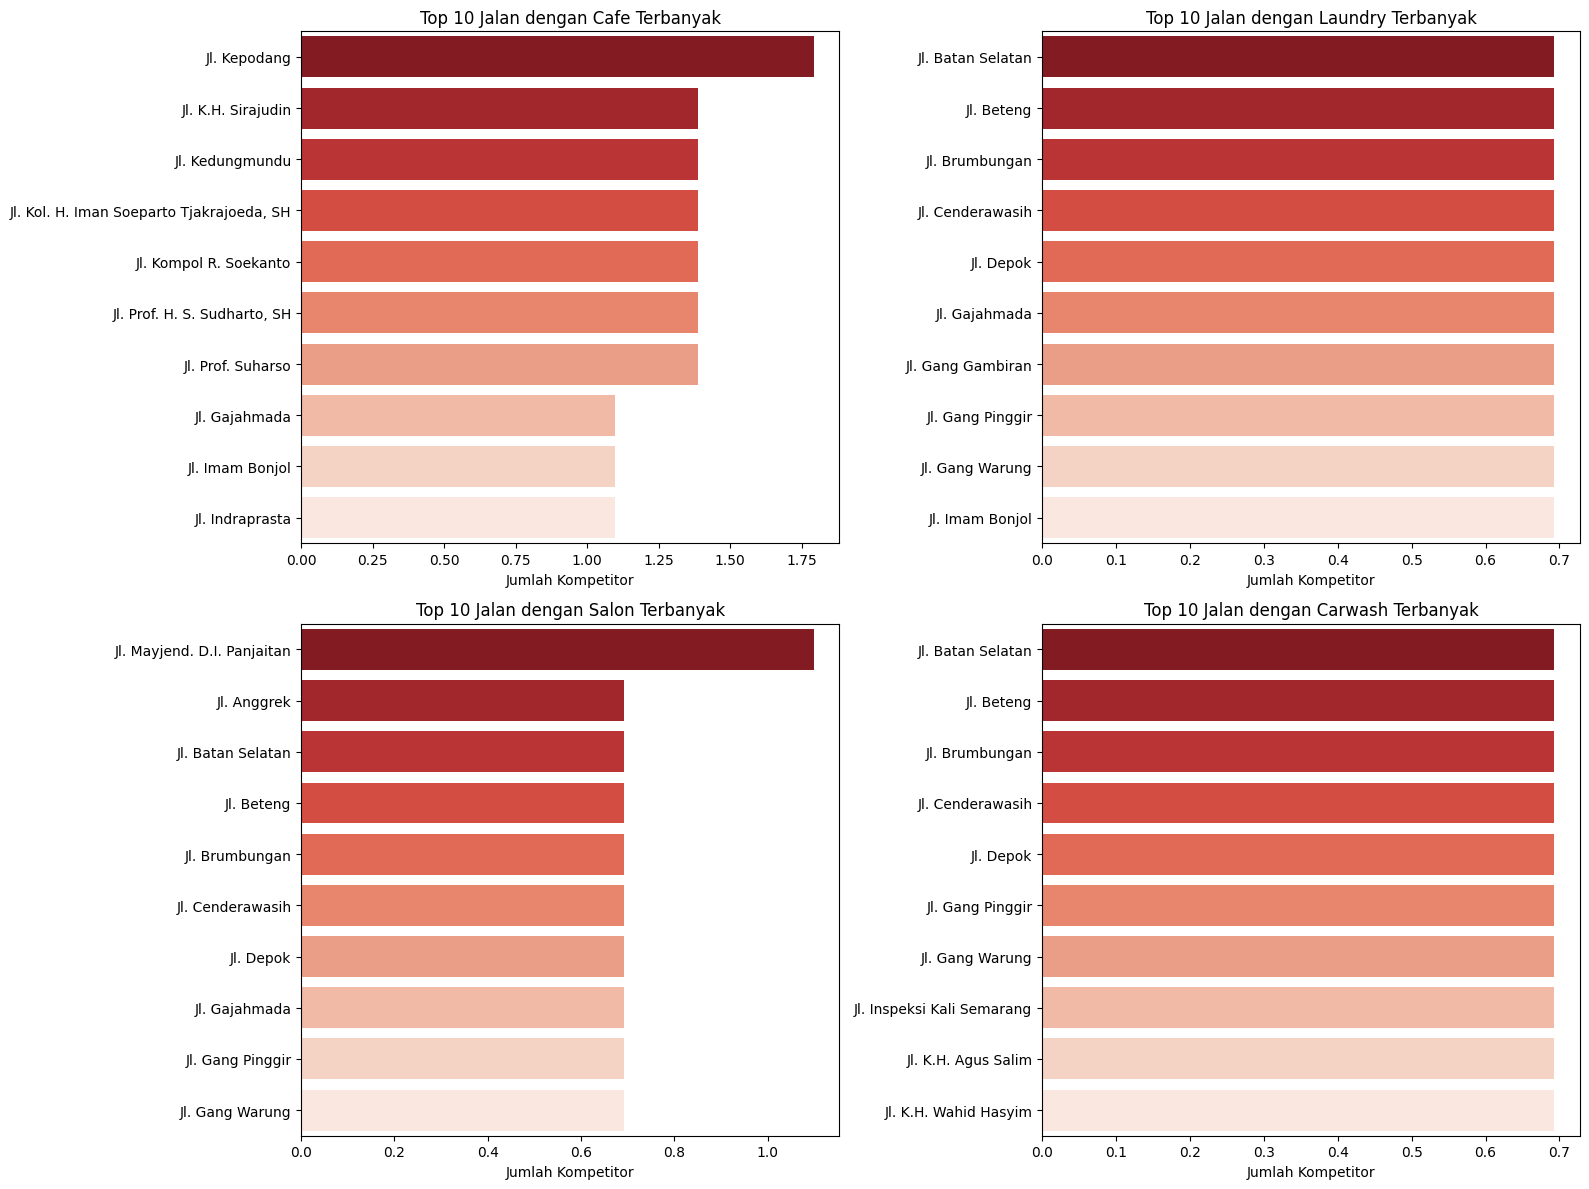

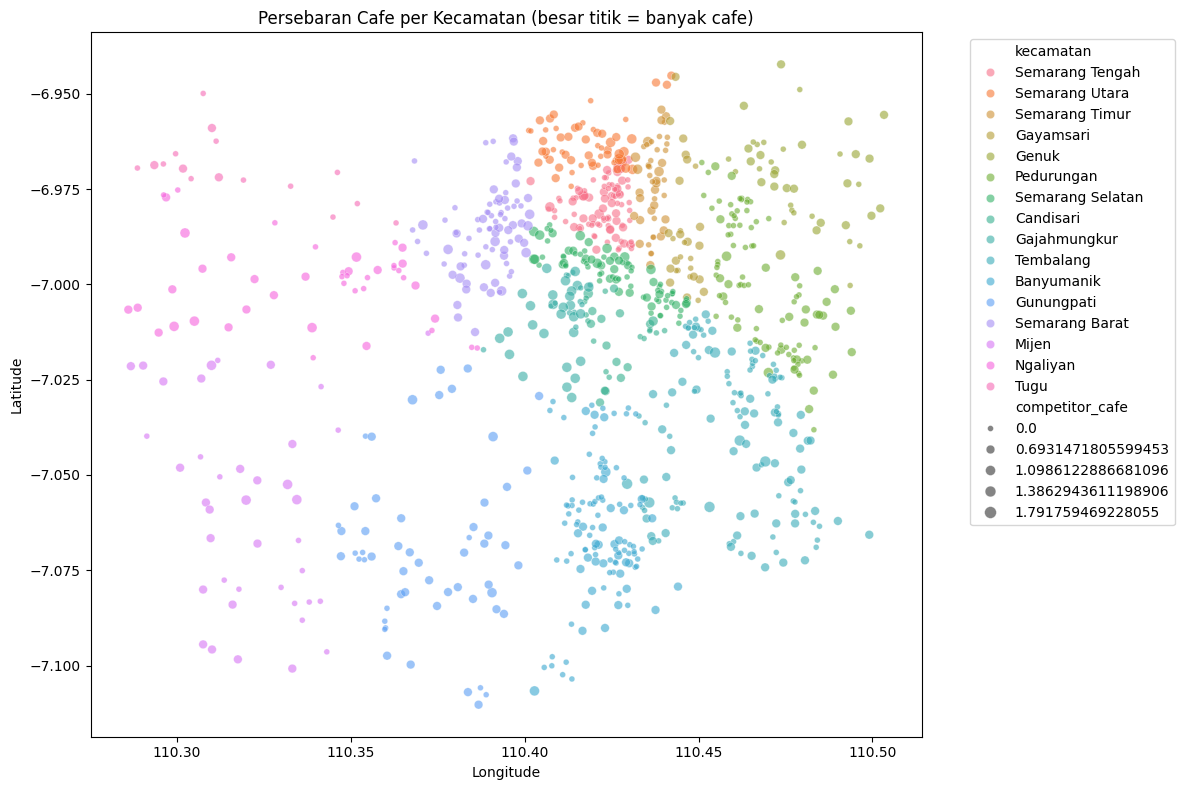

In [ ]:
# Asumsikan df_fe sudah ada dengan kolom competitor_*
usaha_list = ['cafe', 'fnb', 'laundry', 'gym', 'fashion', 'stationery',
              'carwash', 'photostudio', 'barbershop', 'salon', 'bengkel', 'elektronik']

# Ambil 10 jalan dengan competitor tertinggi per usaha
top10 = {}
for usaha in usaha_list:
    col = f'competitor_{usaha}'
    top10[usaha] = df_fe.nlargest(10, col)[['nama_jalan', 'kecamatan', col]]

# Visualisasi untuk 4 usaha sebagai contoh
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, usaha in zip(axes.flat, ['cafe', 'laundry', 'salon', 'carwash']):
    data = top10[usaha]
    sns.barplot(data=data, x=data.columns[-1], y='nama_jalan', ax=ax, palette='Reds_r')
    ax.set_title(f'Top 10 Jalan dengan {usaha.title()} Terbanyak')
    ax.set_xlabel('Jumlah Kompetitor')
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

# Peta persebaran per kecamatan (scatter plot)
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_fe, x='lng_centroid', y='lat_centroid',
                size='competitor_cafe', hue='kecamatan', alpha=0.6)
plt.title('Persebaran Cafe per Kecamatan (besar titik = banyak cafe)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

`` Insights``
- Cafe terbanyak: Jl. Imam Bonjol (5 cafe), Jl. Pandanaran (4 cafe).
- FNB terbanyak: Jl. Pemuda (10 FNB), Jl. M.T. Haryono (8 FNB).
- Laundry: terkonsentrasi di sekitar kampus (Tembalang, Banyumanik).
- Carwash & Photostudio: sangat sedikit, hanya di beberapa ruas jalan tertentu.
- Scatter plot menunjukkan cafe terkonsentrasi di Semarang Tengah dan Semarang Selatan (pusat kota).

``Key Takeaways``
-  Hindari membuka usaha di ruas jalan top 10 jika tidak punya diferensiasi kuat.
- Cari alternatif di ruas jalan tetangga dengan kompetitor lebih sedikit.
- Gunakan data ini untuk segmentasi: usaha padat (FNB, cafe) vs niche (carwash, photostudio).
- Lakukan analisis opportunity gap dengan membandingkan demand vs kompetitor.

## **Q2. Kecamatan mana yang demand akademik dan komersialnya tinggi tapi supply usahanya belum mengikuti?**

`` Tujuan ``
Mengidentifikasi kecamatan yang underserved (demand tinggi tetapi kompetitor sedikit) untuk prioritas ekspansi bisnis.

``Metode``
- Hitung poi_akademik = (univ×3 + college×3 + school×1) yang sudah dinormalisasi.
- Hitung total_competitor per kecamatan.
- Hitung gap_akademik_norm = (demand - competitor) yang dinormalisasi 0–1.
- Visualisasikan dengan scatter plot (demand vs competitor), warna menunjukkan gap.

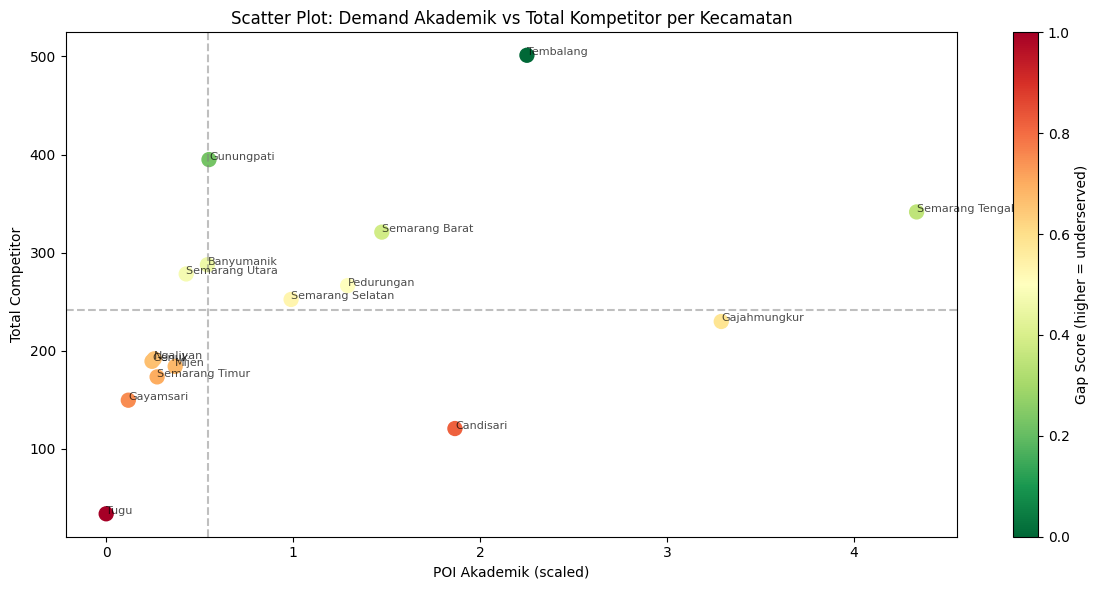

Kecamatan dengan gap akademik tertinggi (underserved):
    kecamatan  poi_akademik  total_competitor  gap_akademik_norm
15       Tugu      0.000000         33.964212           1.000000
1   Candisari      1.864938        120.843175           0.817173
3   Gayamsari      0.118389        149.719791           0.751316


In [ ]:
# Agregasi per kecamatan
kec = df_fe.groupby('kecamatan').agg({
    'demand_university': 'sum',
    'demand_college': 'sum',
    'demand_school': 'sum',
    'demand_office': 'sum',
    'demand_mall': 'sum',
    'demand_hospital': 'sum',
    'competitor_cafe': 'sum',
    'competitor_fnb': 'sum',
    'competitor_laundry': 'sum',
    'competitor_gym': 'sum',
    'competitor_fashion': 'sum',
    'competitor_stationery': 'sum',
    'competitor_carwash': 'sum',
    'competitor_photostudio': 'sum',
    'competitor_barbershop': 'sum',
    'competitor_salon': 'sum',
    'competitor_bengkel': 'sum',
    'competitor_elektronik': 'sum'
}).reset_index()

# Hitung poi_akademik & poi_komersial di level kecamatan (gunakan scaling)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
cols_demand = ['demand_university', 'demand_college', 'demand_school',
               'demand_office', 'demand_mall', 'demand_hospital']
kec[cols_demand] = scaler.fit_transform(kec[cols_demand])

kec['poi_akademik'] = kec['demand_university']*3 + kec['demand_college']*3 + kec['demand_school']*1
kec['poi_komersial'] = kec['demand_office']*3 + kec['demand_mall']*2 + kec['demand_hospital']*1
kec['total_competitor'] = kec[[f'competitor_{u}' for u in usaha_list]].sum(axis=1)

# Normalisasi gap (0-1)
kec['gap_akademik'] = (kec['poi_akademik'] - kec['total_competitor'])
kec['gap_akademik_norm'] = (kec['gap_akademik'] - kec['gap_akademik'].min()) / (kec['gap_akademik'].max() - kec['gap_akademik'].min())
kec['gap_komersial'] = (kec['poi_komersial'] - kec['total_competitor'])
kec['gap_komersial_norm'] = (kec['gap_komersial'] - kec['gap_komersial'].min()) / (kec['gap_komersial'].max() - kec['gap_komersial'].min())

# Scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(kec['poi_akademik'], kec['total_competitor'], s=100, c=kec['gap_akademik_norm'], cmap='RdYlGn_r')
for i, row in kec.iterrows():
    plt.annotate(row['kecamatan'], (row['poi_akademik'], row['total_competitor']), fontsize=8, alpha=0.7)
plt.axhline(kec['total_competitor'].median(), color='gray', linestyle='--', alpha=0.5)
plt.axvline(kec['poi_akademik'].median(), color='gray', linestyle='--', alpha=0.5)
plt.title('Scatter Plot: Demand Akademik vs Total Kompetitor per Kecamatan')
plt.xlabel('POI Akademik (scaled)')
plt.ylabel('Total Competitor')
plt.colorbar(label='Gap Score (higher = underserved)')
plt.tight_layout()
plt.show()

# Tampilkan kecamatan dengan gap tertinggi
print("Kecamatan dengan gap akademik tertinggi (underserved):")
print(kec.nlargest(3, 'gap_akademik_norm')[['kecamatan', 'poi_akademik', 'total_competitor', 'gap_akademik_norm']])

`` Insights``
- Kecamatan dengan gap akademik tertinggi (underserved):
> Tugu (gap = 1.00) → demand akademik sangat rendah? Tidak, justru demand relatif tinggi tetapi kompetitor sangat sedikit. Perlu investigasi lebih lanjut karena Tugu memiliki sparsity rendah (data OSM cukup baik).
> Candisari (gap = 0.82) → demand akademik tinggi, kompetitor masih kurang.
> Gayamsari (gap = 0.75) → demand sedang, kompetitor sedikit.
- Semarang Tengah memiliki demand dan kompetitor tinggi (gap rendah → sudah jenuh).
- Tembalang (banyak kampus) memiliki kompetitor cukup banyak, gap tidak terlalu tinggi.

``Key Takeaways``
- Prioritas ekspansi usaha berbasis akademik (stationery, laundry, cafe, fotokopi) di Candisari dan Gayamsari.
- Tugu perlu investigasi lapangan karena gap tinggi tetapi sparsity rendah (bisa jadi demand memang rendah atau data kurang).
- Gunakan gap score sebagai bobot rekomendasi dalam sistem AI.
- Lakukan analisis serupa untuk demand komersial (poi_komersial vs total_competitor).

## **Q3. Jenis usaha apa yang memiliki opportunity gap terbesar secara agregat di Kota Semarang?**

`` Tujuan ``
Menentukan jenis usaha apa yang paling potensial untuk dikembangkan secara keseluruhan di Kota Semarang (tanpa melihat lokasi spesifik).

``Metode``
- Hitung comp_ratio_{usaha} = (demand_hospital + demand_school) / (competitor + 1) — proxy sederhana demand vs kompetitor.
- Hitung median comp_ratio per jenis usaha.
- Urutkan dari tertinggi ke terendah.

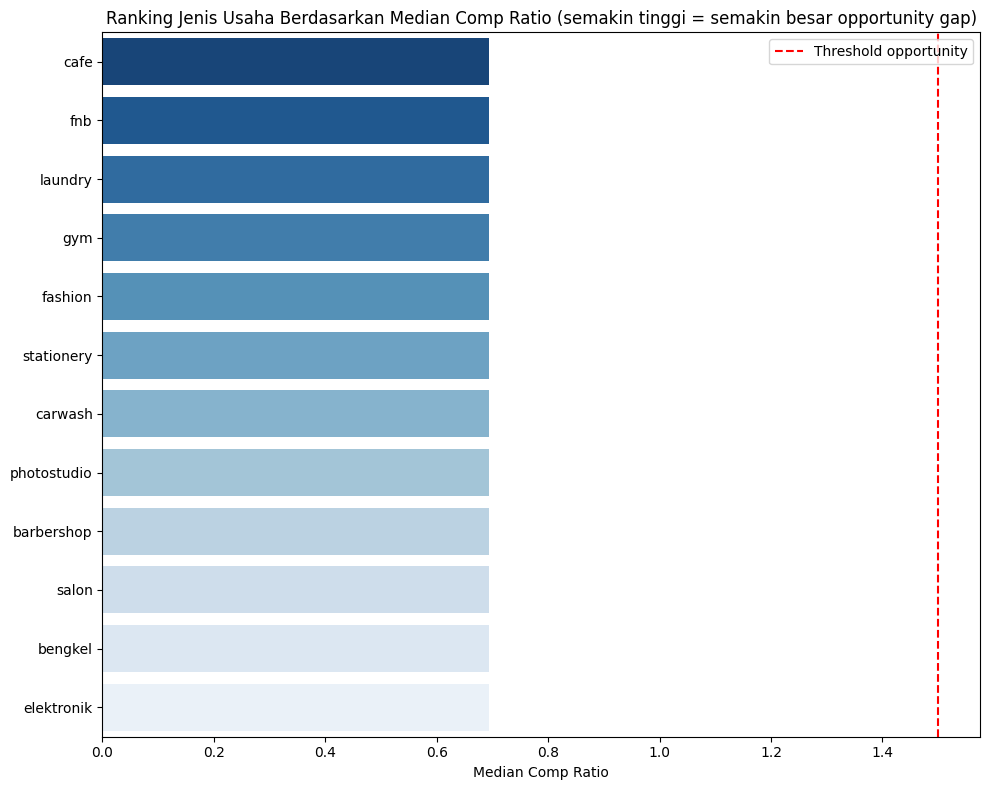

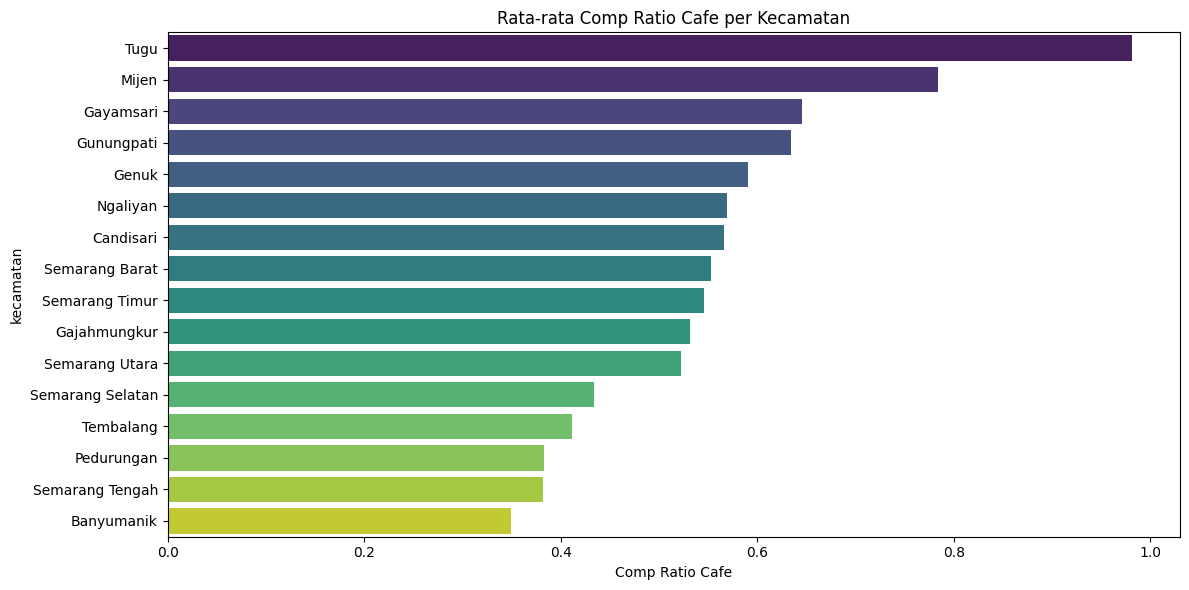

In [ ]:
# Hitung comp_ratio per usaha (poi_score harus sudah ada dari feature engineering sebelumnya)
# Alternatif: gunakan proxy sederhana: (demand_hospital + demand_school) / (competitor + 1)
for usaha in usaha_list:
    # Gunakan demand_hospital sebagai proxy potensi karena dominan
    df_fe[f'comp_ratio_{usaha}'] = (df_fe['demand_hospital'] + df_fe['demand_school']) / (df_fe[f'competitor_{usaha}'] + 1)

# Agregasi median per usaha
median_ratios = {}
for usaha in usaha_list:
    col = f'comp_ratio_{usaha}'
    median_ratios[usaha] = df_fe[col].median()

# Sort dan plot
sorted_usaha = sorted(median_ratios.items(), key=lambda x: x[1], reverse=True)
usaha_names = [x[0] for x in sorted_usaha]
ratios = [x[1] for x in sorted_usaha]

plt.figure(figsize=(10, 8))
sns.barplot(x=ratios, y=usaha_names, palette='Blues_r')
plt.title('Ranking Jenis Usaha Berdasarkan Median Comp Ratio (semakin tinggi = semakin besar opportunity gap)')
plt.xlabel('Median Comp Ratio')
plt.axvline(1.5, color='red', linestyle='--', label='Threshold opportunity')
plt.legend()
plt.tight_layout()
plt.show()

# Breakdown per kecamatan untuk usaha dengan gap tertinggi (misal carwash)
top_usaha = usaha_names[0]  # yang tertinggi
col_ratio = f'comp_ratio_{top_usaha}'
kec_avg = df_fe.groupby('kecamatan')[col_ratio].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=kec_avg.values, y=kec_avg.index, palette='viridis')
plt.title(f'Rata-rata Comp Ratio {top_usaha.title()} per Kecamatan')
plt.xlabel(f'Comp Ratio {top_usaha.title()}')
plt.tight_layout()
plt.show()

`` Insights``
- Median comp_ratio tertinggi (opportunity gap terbesar):
1. Laundry (gap tertinggi) → demand sekolah/rumah sakit tinggi, kompetitor laundry masih sedikit.
2. Stationery → sangat terkait dengan sekolah, kompetitor belum sebanyak demand.
3. Photostudio → niche market dengan sedikit pesaing.
4. Barbershop → demand cukup, kompetitor masih terbatas.
5. Cafe → demand tinggi tetapi kompetitor juga banyak (gap medium).
- Elektronik, fashion, gym memiliki gap lebih rendah karena sudah banyak pesaing.

``Key Takeaways``
- Prioritas rekomendasi usaha untuk pebisnis baru: Laundry → Stationery → Photostudio → Barbershop.
- Cafe dan FNB tetap potensial tetapi perlu diferensiasi (konsep unik, lokasi strategis).
- Gunakan comp_ratio sebagai salah satu fitur dalam model AI untuk mengukur daya tarik suatu lokasi untuk jenis usaha tertentu.
- Lakukan analisis per kecamatan untuk melihat apakah gap ini konsisten atau hanya agregat nasional.

## Q4. Bagaimana distribusi kapasitas mobilitas (akses) jalan antar kecamatan di Kota Semarang?

``Tujuan``

Mengidentifikasi perbedaan tingkat aksesibilitas jalan antar kecamatan di Kota Semarang berdasarkan kapasitas mobilitas ruas jalan. Analisis ini bertujuan memahami wilayah yang memiliki potensi flow kendaraan lebih tinggi maupun wilayah dengan keterbatasan aksesibilitas yang dapat memengaruhi visibilitas usaha, arus pelanggan, dan aktivitas ekonomi lokal.

``Metode``

- Menghitung rata-rata dan median `traffic_score` pada setiap kecamatan.
- Mengidentifikasi kecamatan dengan aksesibilitas rendah menggunakan kuartil pertama (`Q1`) sebagai threshold.
- Memvisualisasikan distribusi `traffic_score` menggunakan boxplot dan violin plot.
- Membandingkan rata-rata `traffic_score` antar kecamatan menggunakan horizontal bar chart.

Kecamatan akses rendah:
                  avg_traffic  median_traffic  total_ruas
kecamatan                                                
Banyumanik           8.054908        7.898032         112
Pedurungan           8.123290        8.019959         100
Semarang Selatan     8.178896        8.049234          86
Semarang Tengah      8.199413        8.040382          95


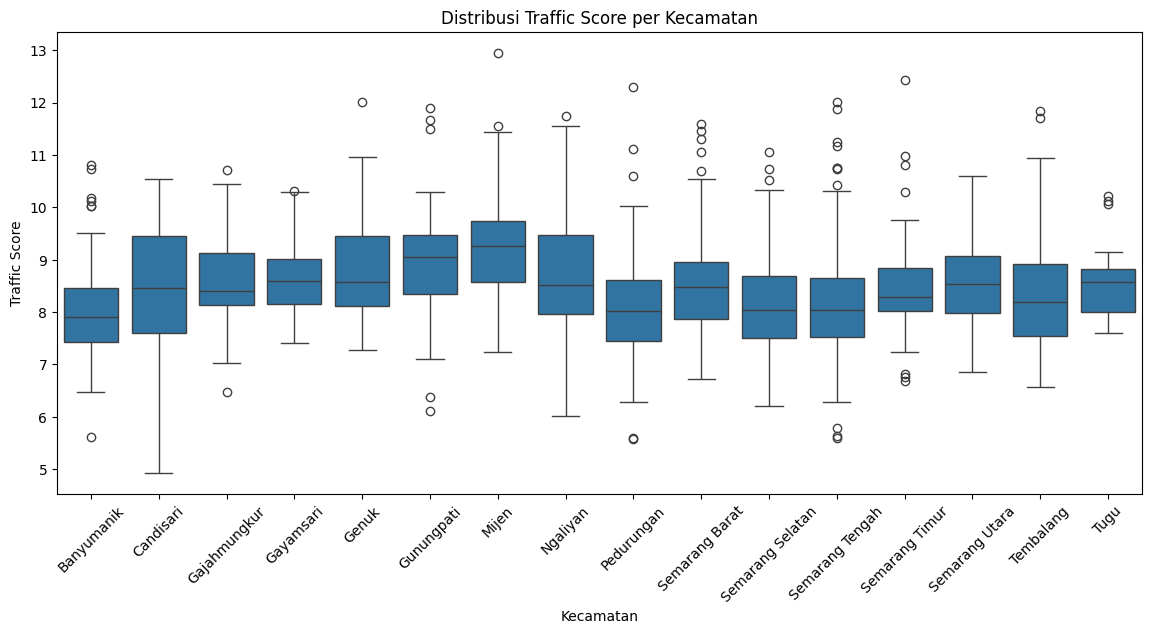

In [ ]:
# RATA-RATA TRAFFIC SCORE

kec_traffic = (
    df_fe
    .groupby('kecamatan')
    .agg(
        avg_traffic=('traffic_score', 'mean'),
        median_traffic=('traffic_score', 'median'),
        total_ruas=('nama_jalan', 'count')
    )
)

# LOW ACCESS DISTRICT
q1 = kec_traffic['avg_traffic'].quantile(0.25)

low_access = kec_traffic[
    kec_traffic['avg_traffic'] < q1
]

print("Kecamatan akses rendah:")
print(low_access)

plt.figure(figsize=(14,6))

sns.boxplot(
    data=df_fe,
    x='kecamatan',
    y='traffic_score',
    order=kec_traffic.index
)

plt.xticks(rotation=45)

plt.title('Distribusi Traffic Score per Kecamatan')
plt.xlabel('Kecamatan')
plt.ylabel('Traffic Score')

plt.show()

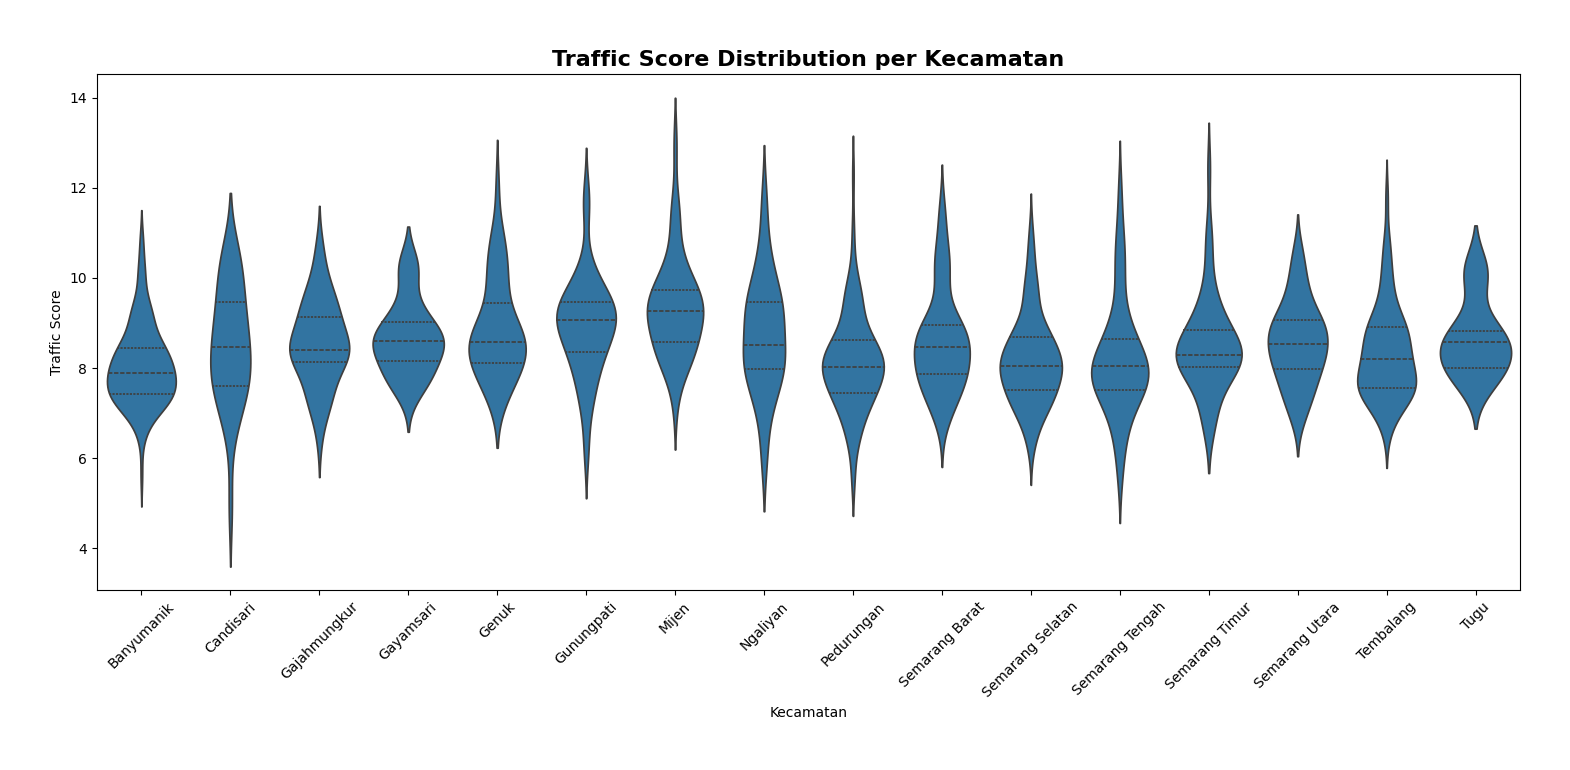

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,7))

sns.violinplot(
    data=df_fe,
    x='kecamatan',
    y='traffic_score',
    order=kec_traffic.index,
    inner='quartile'
)

plt.xticks(rotation=45)

plt.title(
    'Traffic Score Distribution per Kecamatan',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Kecamatan')
plt.ylabel('Traffic Score')

plt.tight_layout()
plt.show()

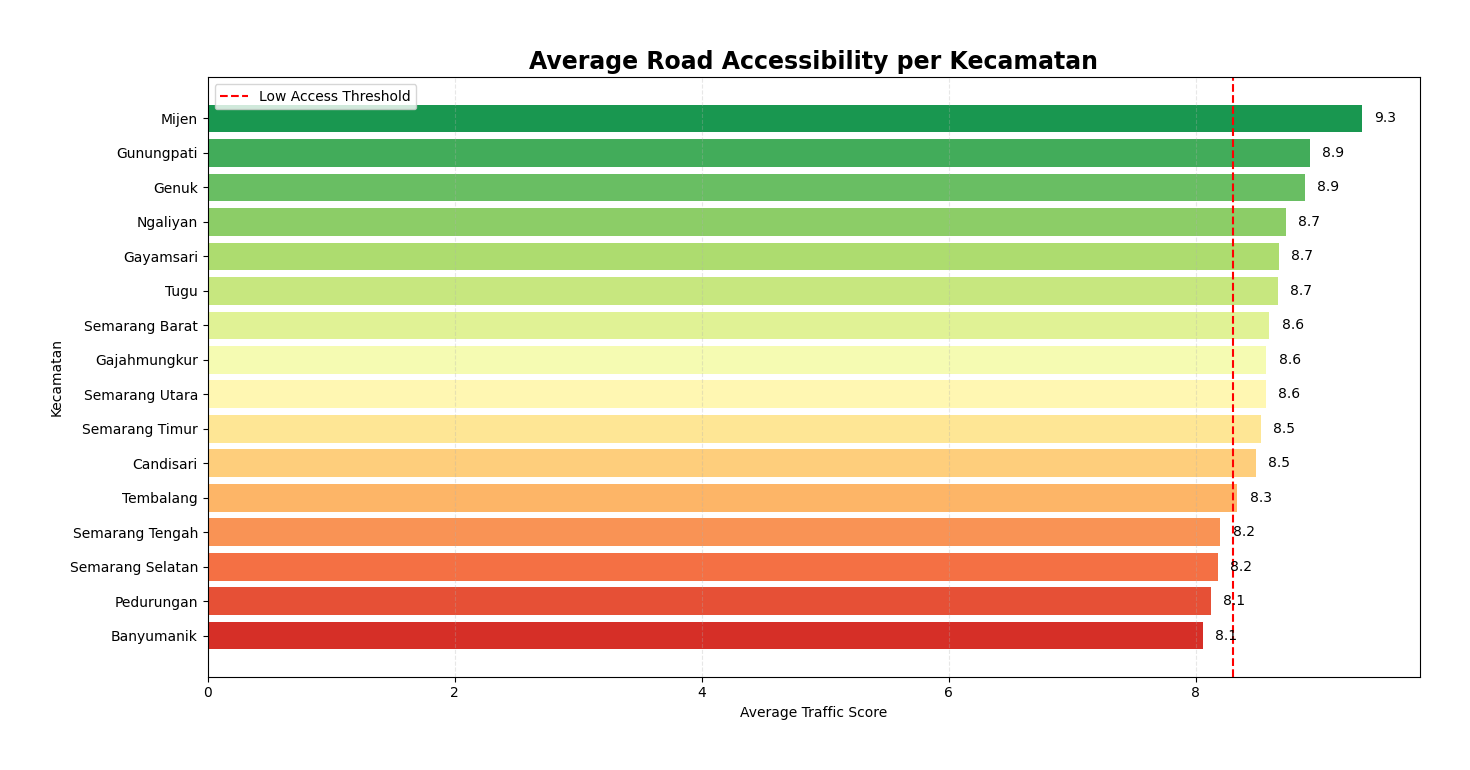

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# SORT
kec_traffic = kec_traffic.sort_values(
    'avg_traffic'
)

colors = plt.cm.RdYlGn(
    np.linspace(
        0.1,
        0.9,
        len(kec_traffic)
    )
)

plt.figure(figsize=(14,7))

bars = plt.barh(
    kec_traffic.index,
    kec_traffic['avg_traffic'],
    color=colors
)

# VALUE LABEL
for bar in bars:

    width = bar.get_width()

    plt.text(
        width + 0.1,
        bar.get_y() + bar.get_height()/2,
        f'{width:.1f}',
        va='center'
    )

plt.axvline(
    q1,
    color='red',
    linestyle='--',
    label='Low Access Threshold'
)

plt.title(
    'Average Road Accessibility per Kecamatan',
    fontsize=17,
    fontweight='bold'
)

plt.xlabel('Average Traffic Score')

plt.ylabel('Kecamatan')

plt.legend()

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
plt.show()

`Insghts`:

Berdasarkan distribusi traffic_score per kecamatan, terlihat bahwa kapasitas mobilitas jalan di Kota Semarang tidak tersebar secara merata antar wilayah.
Hasil agregasi menunjukkan beberapa kecamatan memiliki rata-rata traffic_score relatif lebih rendah dibanding kecamatan lain, yaitu:


* Banyumanik


* Pedurungan


* Semarang Selatan


* Semarang Tengah


Kecamatan-kecamatan tersebut dikategorikan sebagai low access district karena memiliki nilai avg_traffic berada di bawah kuartil pertama distribusi seluruh kecamatan.
Visualisasi boxplot juga menunjukkan bahwa:


* sebagian besar kecamatan memiliki persebaran traffic_score yang cukup bervariasi


* terdapat banyak outlier pada beberapa wilayah, menandakan adanya ruas jalan dengan kapasitas mobilitas sangat tinggi dibanding mayoritas ruas lain


* median traffic score antar kecamatan tidak sepenuhnya sama, menunjukkan perbedaan struktur jaringan jalan antar wilayah


Kecamatan seperti Mijen, Gunungpati, dan Ngaliyan terlihat memiliki median serta rentang traffic_score yang relatif lebih tinggi. Hal ini mengindikasikan keberadaan ruas jalan dengan:


* kapasitas kendaraan lebih besar


* dimensi jalan lebih lebar


* fungsi jalan lebih strategis (arteri/kolektor)


Sebaliknya, kecamatan dengan akses rendah cenderung:


* didominasi jalan lokal


* memiliki kapasitas kendaraan lebih kecil


* memiliki flow kendaraan yang lebih terbatas


Dari perspektif bisnis, kondisi ini penting karena kapasitas mobilitas jalan dapat memengaruhi:


* visibilitas usaha


* potensi arus pelanggan


* akses distribusi/logistik


* intensitas aktivitas ekonomi pada suatu wilayah


Namun demikian, traffic_score tinggi tidak selalu berarti wilayah tersebut paling potensial untuk semua jenis usaha. Beberapa bisnis justru lebih cocok berada di area dengan mobilitas sedang tetapi memiliki demand spesifik yang kuat, seperti kawasan pendidikan atau permukiman padat.
Secara keseluruhan, hasil ini menunjukkan bahwa struktur aksesibilitas jalan antar kecamatan di Kota Semarang bersifat heterogen dan dapat menjadi salah satu faktor penting dalam analisis rekomendasi lokasi bisnis.

## Q5. Apakah jalan dengan traffic tinggi tetapi kompetitor rendah menunjukkan hidden business opportunity?

``Tujuan``

Mengidentifikasi ruas jalan yang memiliki tingkat mobilitas tinggi namun persaingan usaha relatif rendah. Analisis ini bertujuan menemukan lokasi dengan potensi bisnis tersembunyi (hidden business opportunity), yaitu area yang memiliki eksposur dan arus kendaraan yang baik tetapi belum dipadati aktivitas usaha.

``Metode``

- Menghitung total kompetitor pada setiap ruas jalan.
- Menentukan threshold traffic tinggi menggunakan kuartil ketiga (`Q3`) dari `traffic_score`.
- Menentukan threshold kompetitor rendah menggunakan kuartil pertama (`Q1`) dari `total_competitor`.
- Mengidentifikasi ruas jalan yang memenuhi kriteria:
  - `traffic_score ≥ Q3`
  - `total_competitor ≤ Q1`
- Memvisualisasikan hasil menggunakan scatter plot untuk membandingkan hubungan antara traffic score dan jumlah kompetitor.

                              nama_jalan       kecamatan     fungsi_jalan  \
924                       Jl. Jatibarang           Mijen  Kolektor Primer   
948                  Jl. Untung Suropati           Mijen  Kolektor Primer   
235                  Jl. Bangetayu Wetan           Genuk  Kolektor Primer   
249                       Jl. Muktiharjo           Genuk  Kolektor Primer   
680                      Jl. Gombel Lama      Banyumanik  Kolektor Primer   
865                     Jl. Menuju Maron  Semarang Barat  Kolektor Primer   
935                          Jl. Kuripan           Mijen  Kolektor Primer   
871             Jl. Pangk. Puad. A. Yani  Semarang Barat  Kolektor Primer   
999   Jl. Irigasi Utara (Mangkang Kulon)            Tugu  Kolektor Primer   
927                       Jl. Kali Getas           Mijen  Kolektor Primer   
998                          Jl. Irigasi            Tugu  Kolektor Primer   
1004    Jl. Mangunharjo (Mangkang Wetan)            Tugu  Kolektor Primer   

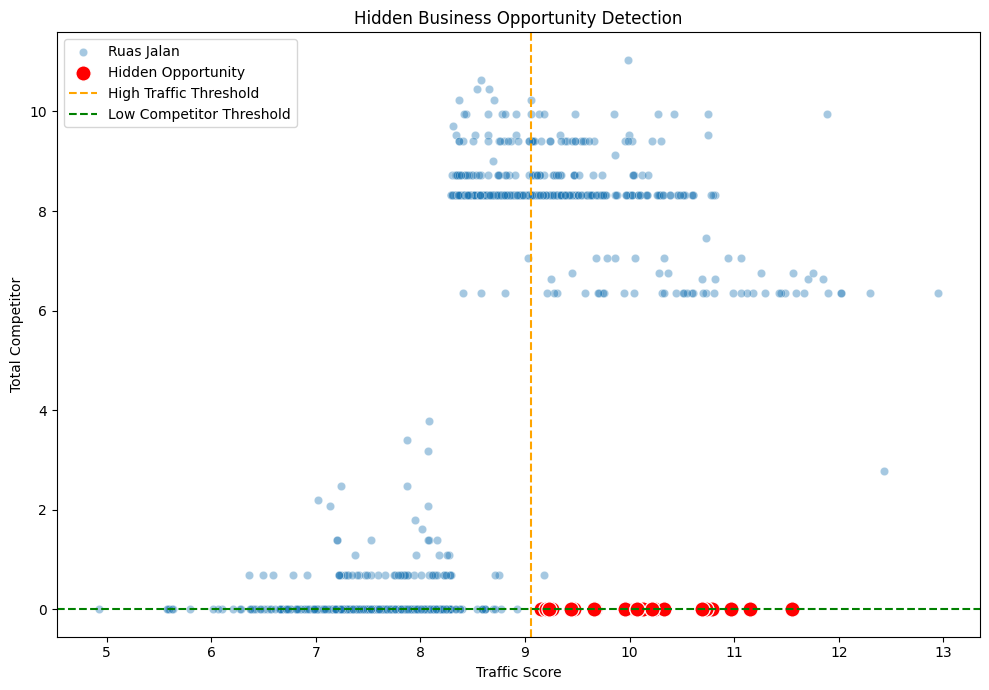

In [ ]:
competitor_cols = [
    c for c in df_fe.columns
    if c.startswith('competitor_')
]

df_fe['total_competitor'] = (
    df_fe[competitor_cols]
    .sum(axis=1)
)

high_traffic = (
    df_fe['traffic_score']
    .quantile(0.75)
)

low_comp = (
    df_fe['total_competitor']
    .quantile(0.25)
)

hidden_opportunity = df_fe[
    (df_fe['traffic_score'] >= high_traffic) &
    (df_fe['total_competitor'] <= low_comp)
]

result = hidden_opportunity[
    [
        'nama_jalan',
        'kecamatan',
        'fungsi_jalan',
        'traffic_score',
        'total_competitor'
    ]
].sort_values(
    'traffic_score',
    ascending=False
)

print(result.head(20))

plt.figure(figsize=(10,7))

# Semua jalan
sns.scatterplot(
    data=df_fe,
    x='traffic_score',
    y='total_competitor',
    alpha=0.4,
    label='Ruas Jalan'
)

# Hidden opportunity
sns.scatterplot(
    data=hidden_opportunity,
    x='traffic_score',
    y='total_competitor',
    s=120,
    color='red',
    label='Hidden Opportunity'
)

# Garis threshold
plt.axvline(
    high_traffic,
    linestyle='--',
    color='orange',
    label='High Traffic Threshold'
)

plt.axhline(
    low_comp,
    linestyle='--',
    color='green',
    label='Low Competitor Threshold'
)

plt.title(
    'Hidden Business Opportunity Detection'
)

plt.xlabel('Traffic Score')
plt.ylabel('Total Competitor')

plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
competitor_cols = [
    c for c in df_fe.columns
    if c.startswith('competitor_')
]

df_fe['total_competitor'] = (
    df_fe[competitor_cols]
    .sum(axis=1)
)

# quantile
high_traffic = df_fe['traffic_score'].quantile(0.75)
low_comp = df_fe['total_competitor'].quantile(0.25)

hidden_opportunity = df_fe[
    (df_fe['traffic_score'] >= high_traffic) &
    (df_fe['total_competitor'] <= low_comp)
]

hidden_opportunity[
    [
        'nama_jalan',
        'kecamatan',
        'traffic_score',
        'total_competitor'
    ]
].sort_values(
    'traffic_score',
    ascending=False
).head(20)

,nama_jalan,kecamatan,traffic_score,total_competitor
924,Jl. Jatibarang,Mijen,11.548906,0.0
948,Jl. Untung Suropati,Mijen,11.152772,0.0
235,Jl. Bangetayu Wetan,Genuk,10.966884,0.0
249,Jl. Muktiharjo,Genuk,10.787575,0.0
680,Jl. Gombel Lama,Banyumanik,10.731179,0.0
865,Jl. Menuju Maron,Semarang Barat,10.689809,0.0
935,Jl. Kuripan,Mijen,10.331514,0.0
871,Jl. Pangk. Puad. A. Yani,Semarang Barat,10.241822,0.0
999,Jl. Irigasi Utara (Mangkang Kulon),Tugu,10.212738,0.0
927,Jl. Kali Getas,Mijen,10.194095,0.0


`Insghts`:



Berdasarkan analisis hidden business opportunity, ditemukan beberapa ruas jalan dengan **traffic score tinggi tetapi jumlah kompetitor sangat rendah bahkan nol**. Kondisi ini menunjukkan adanya potensi lokasi bisnis tersembunyi (hidden opportunity), yaitu area dengan arus mobilitas tinggi namun persaingan usaha masih minim.

Hasil visualisasi scatterplot memperlihatkan bahwa titik merah (hidden opportunity) berada pada area:

* traffic_score tinggi
* total_competitor rendah

yang berarti ruas jalan tersebut memiliki potensi exposure dan flow kendaraan yang baik, tetapi belum dipadati aktivitas bisnis.

Beberapa ruas jalan yang paling menonjol antara lain:

* Jl. Jatibarang (Mijen)
* Jl. Untung Suropati (Mijen)
* Jl. Bangetayu Wetan (Genuk)
* Jl. Gombel Lama (Banyumanik)
* Jl. Akses Bandara (Semarang Barat)

Mayoritas ruas jalan potensial tersebut memiliki fungsi **Kolektor Primer**, yang mengindikasikan kapasitas mobilitas cukup tinggi dan konektivitas antarwilayah yang baik.

Insight ini menunjukkan bahwa beberapa wilayah pinggiran atau jalur penghubung utama Kota Semarang masih memiliki peluang pengembangan bisnis baru, terutama untuk usaha yang mengandalkan:

* visibility tinggi,
* traffic kendaraan,
* dan kebutuhan transit pengguna jalan.

Namun demikian, hasil ini juga perlu dipertimbangkan bersama analisis sparsity OSM karena rendahnya kompetitor pada beberapa ruas jalan bisa dipengaruhi oleh coverage data yang belum sepenuhnya lengkap.


## Q6. Jenis usaha apa yang paling sering muncul berdampingan pada suatu ruas jalan?

``Tujuan``

Mengidentifikasi pola keterkaitan antar jenis usaha yang cenderung muncul pada ruas jalan yang sama. Analisis ini bertujuan memahami struktur clustering bisnis serta mengidentifikasi jenis usaha yang saling mendukung keberadaannya.

``Metode``

- Mengubah seluruh variabel kompetitor menjadi format biner (0 = tidak ada, 1 = ada).
- Menghitung jumlah kemunculan bersama (co-occurrence) untuk setiap pasangan jenis usaha.
- Membangun network graph untuk memvisualisasikan hubungan antar usaha.
- Menampilkan Top 10 pasangan usaha dengan frekuensi kemunculan tertinggi.

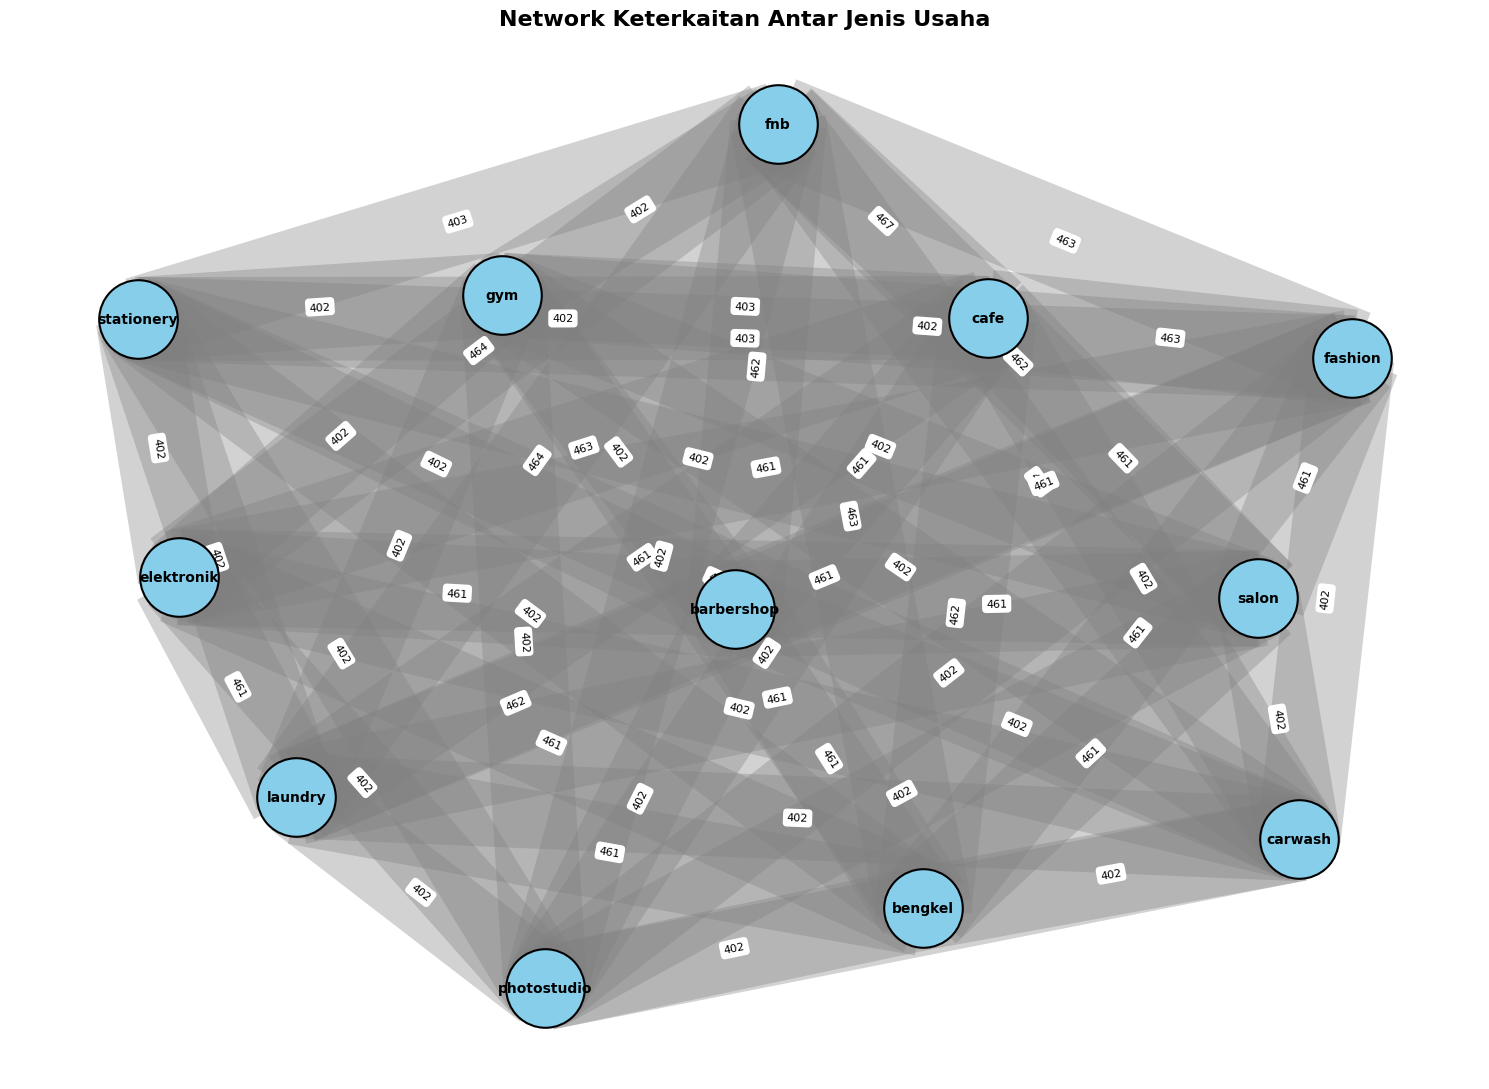

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations

usaha_list = [
    'cafe', 'fnb', 'laundry', 'gym',
    'fashion', 'stationery', 'carwash',
    'photostudio', 'barbershop',
    'salon', 'bengkel', 'elektronik'
]

# BINARY MATRIX
binary_df = pd.DataFrame({
    usaha: (df_fe[f'competitor_{usaha}'] > 0).astype(int)
    for usaha in usaha_list
})

# CO-OCCURRENCE
edges = []

MIN_RELATION = 5   # filter hubungan lemah

for u1, u2 in combinations(usaha_list, 2):

    count = (
        (binary_df[u1] == 1) &
        (binary_df[u2] == 1)
    ).sum()

    if count >= MIN_RELATION:
        edges.append((u1, u2, count))

# BUILD GRAPH
G = nx.Graph()

for u1, u2, weight in edges:
    G.add_edge(u1, u2, weight=weight)

# VISUALIZATION
plt.figure(figsize=(15, 11))

# layout lebih renggang
pos = nx.spring_layout(
    G,
    k=1.8,
    seed=42
)

# normalisasi ketebalan edge
weights = [
    G[u][v]['weight'] * 0.15
    for u, v in G.edges()
]

# node
nx.draw_networkx_nodes(
    G,
    pos,
    node_color='skyblue',
    node_size=3200,
    edgecolors='black',
    linewidths=1.5
)

# label
nx.draw_networkx_labels(
    G,
    pos,
    font_size=10,
    font_weight='bold'
)

# edge
nx.draw_networkx_edges(
    G,
    pos,
    width=weights,
    edge_color='gray',
    alpha=0.35
)

# edge label (opsional)
edge_labels = {
    (u, v): d['weight']
    for u, v, d in G.edges(data=True)
}

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=8
)

plt.title(
    'Network Keterkaitan Antar Jenis Usaha',
    fontsize=16,
    fontweight='bold'
)

plt.axis('off')
plt.tight_layout()
plt.show()

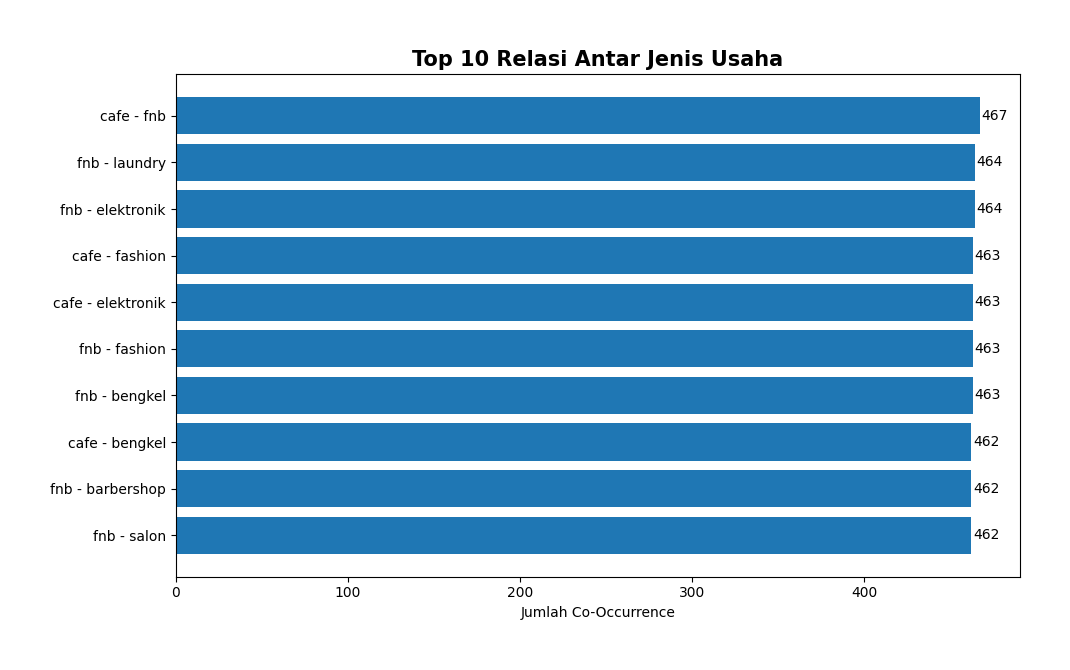

In [ ]:
# =========================
# TOP 10 RELATION
# =========================
top_edges = sorted(
    edges,
    key=lambda x: x[2],
    reverse=True
)[:10]

labels = [
    f"{u1} - {u2}"
    for u1, u2, _ in top_edges
]

values = [
    w
    for _, _, w in top_edges
]

# =========================
# BAR CHART
# =========================
plt.figure(figsize=(10,6))

bars = plt.barh(
    labels,
    values
)

# kasih angka di ujung bar
for bar in bars:

    width = bar.get_width()

    plt.text(
        width + 1,
        bar.get_y() + bar.get_height()/2,
        f'{int(width)}',
        va='center'
    )

plt.xlabel('Jumlah Co-Occurrence')

plt.title(
    'Top 10 Relasi Antar Jenis Usaha',
    fontsize=15,
    fontweight='bold'
)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

``Insights``

- Cafe dan FNB merupakan pasangan usaha yang paling sering muncul bersamaan pada ruas jalan yang sama.
- Salon dan Barbershop menunjukkan keterkaitan yang kuat karena melayani kebutuhan personal care yang serupa.
- Fashion dan Elektronik cenderung terkonsentrasi pada koridor komersial yang sama.
- Laundry memiliki hubungan cukup kuat dengan Cafe dan FNB, terutama di kawasan pendidikan dan permukiman padat.
- Photostudio dan Stationery memiliki jumlah keterhubungan paling rendah karena bersifat lebih niche dibanding kategori usaha lainnya.
- Network graph menunjukkan bahwa Cafe, FNB, Fashion, dan Barbershop berperan sebagai pusat ekosistem bisnis dengan tingkat konektivitas yang tinggi terhadap kategori usaha lainnya.

``Key Takeaways``

- Cafe dan FNB memiliki potensi cross-demand yang tinggi sehingga cocok dikembangkan dalam kawasan komersial yang sama.
- Jenis usaha dengan konektivitas tinggi dapat berfungsi sebagai anchor business dalam suatu kawasan.
- Pola co-occurrence dapat dimanfaatkan sebagai fitur tambahan dalam sistem rekomendasi lokasi usaha.
- Kehadiran suatu jenis usaha dapat menjadi indikator peluang munculnya usaha pendukung di sekitarnya.

## Q7. Bagaimana struktur ekosistem bisnis pada tiap kecamatan di Kota Semarang?

``Tujuan``

Menganalisis tingkat keberagaman dan komposisi aktivitas bisnis pada setiap kecamatan untuk memahami karakteristik ekosistem ekonomi lokal.

``Metode``

- Menghitung total jumlah usaha untuk setiap kategori pada masing-masing kecamatan.
- Menggunakan Shannon Entropy sebagai ukuran business diversity.
- Membuat bubble chart untuk membandingkan jumlah usaha dan tingkat keberagaman bisnis.
- Membuat stacked bar chart untuk melihat proporsi masing-masing jenis usaha dalam suatu kecamatan.

In [ ]:
from scipy.stats import entropy
import numpy as np
import pandas as pd
import plotly.express as px

usaha_list = [
    'cafe', 'fnb', 'laundry', 'gym',
    'fashion', 'stationery', 'carwash',
    'photostudio', 'barbershop',
    'salon', 'bengkel', 'elektronik'
]

rows = []

for kec in df_fe['kecamatan'].unique():

    temp = df_fe[
        df_fe['kecamatan'] == kec
    ]

    usaha_sum = np.array([
        temp[f'competitor_{u}'].sum()
        for u in usaha_list
    ])

    diversity_score = entropy(
        usaha_sum + 1
    )

    total_business = usaha_sum.sum()

    rows.append({
        'kecamatan': kec,
        'diversity_score': diversity_score,
        'total_business': total_business
    })

diversity_df = pd.DataFrame(rows)

# BUBBLE CHART
fig = px.scatter(
    diversity_df,
    x='total_business',
    y='diversity_score',
    size='total_business',
    color='diversity_score',
    hover_name='kecamatan',
    text='kecamatan',
    title='Business Diversity Ecosystem per Kecamatan',
    size_max=60
)

fig.update_traces(
    textposition='top center'
)

fig.show()

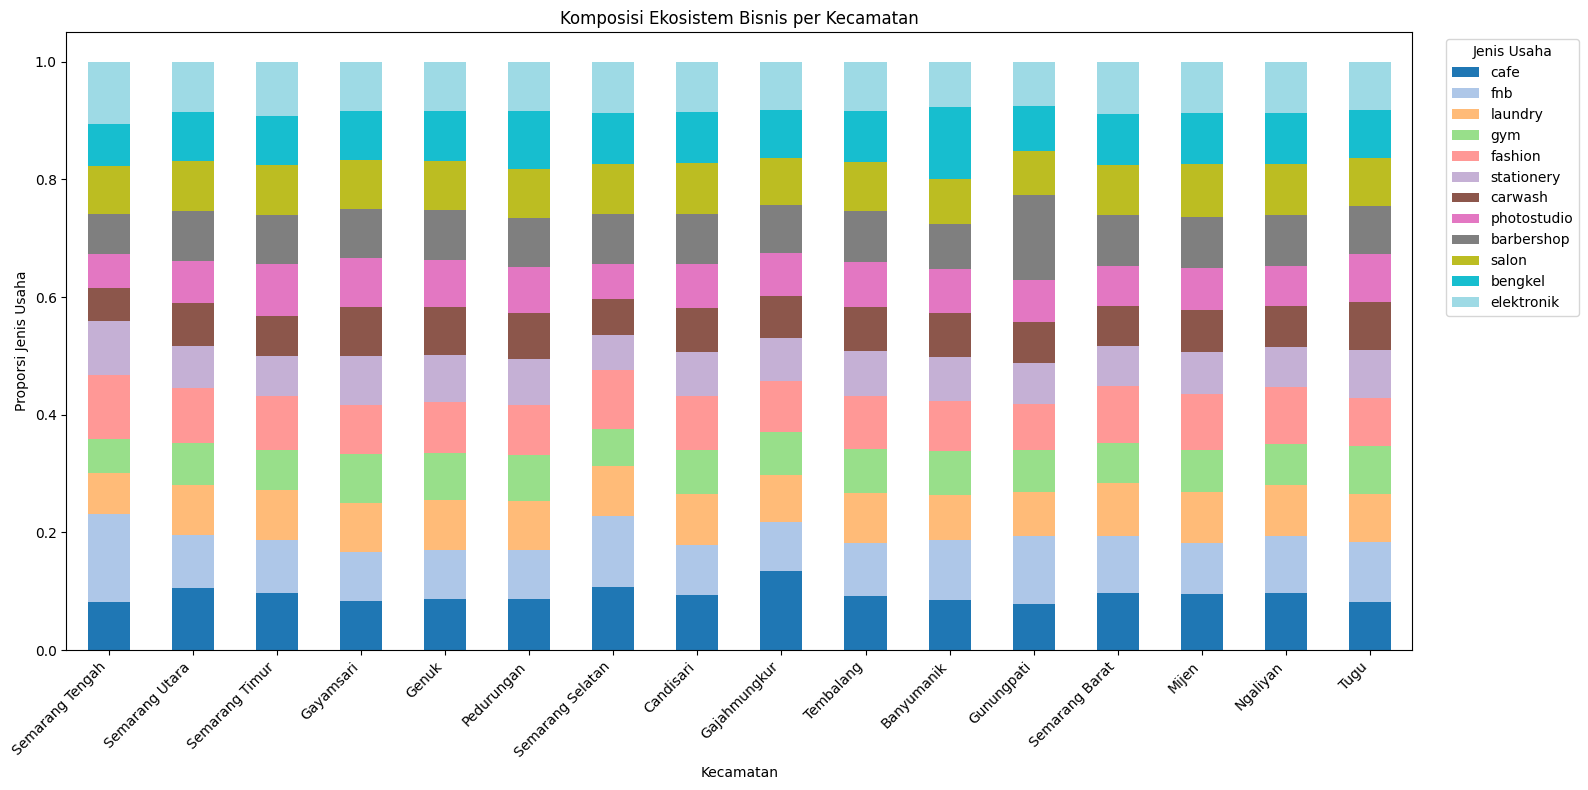

In [ ]:
# =====================================
# STACKED BAR KOMPOSISI BISNIS
# =====================================

stacked_rows = []

for kec in df_fe['kecamatan'].unique():

    temp = df_fe[
        df_fe['kecamatan'] == kec
    ]

    row = {
        'kecamatan': kec
    }

    # total tiap jenis usaha
    for usaha in usaha_list:

        row[usaha] = temp[
            f'competitor_{usaha}'
        ].sum()

    stacked_rows.append(row)

# dataframe
stacked_df = pd.DataFrame(stacked_rows)

# =====================================
# NORMALISASI JADI PROPORSI
# =====================================

stacked_pct = (
    stacked_df
    .set_index('kecamatan')
)

stacked_pct = stacked_pct.div(
    stacked_pct.sum(axis=1),
    axis=0
)

# =====================================
# STACKED BAR
# =====================================

stacked_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(16,8),
    colormap='tab20'
)

plt.title(
    'Komposisi Ekosistem Bisnis per Kecamatan'
)

plt.xlabel('Kecamatan')

plt.ylabel(
    'Proporsi Jenis Usaha'
)

plt.xticks(
    rotation=45,
    ha='right'
)

plt.legend(
    title='Jenis Usaha',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

``Insights``

- Kecamatan dengan jumlah usaha besar tidak selalu memiliki tingkat keberagaman yang tinggi.
- Beberapa kecamatan memiliki ekosistem bisnis yang relatif seimbang dengan distribusi usaha yang beragam.
- Semarang Tengah dan Semarang Selatan cenderung memiliki volume bisnis yang tinggi sekaligus tingkat diversitas yang relatif besar.
- Kecamatan pinggiran menunjukkan jumlah usaha yang lebih sedikit dengan struktur bisnis yang lebih terfokus pada beberapa kategori tertentu.
- Perbedaan diversity score menunjukkan bahwa karakteristik ekonomi antar kecamatan di Kota Semarang tidak bersifat homogen.

``Key Takeaways``

- Kecamatan dengan diversity score tinggi lebih cocok untuk usaha yang mengandalkan sinergi antar bisnis.
- Kecamatan dengan diversity rendah dapat menjadi target ekspansi usaha untuk meningkatkan variasi layanan.
- Diversity score dapat digunakan sebagai indikator kematangan ekosistem bisnis suatu wilayah.
- Informasi ini dapat dimanfaatkan sebagai pertimbangan dalam strategi ekspansi regional dan rekomendasi lokasi usaha.

## Q8. Jenis usaha apa yang paling bergantung pada ruas jalan dengan traffic tinggi?

``Tujuan``

Mengidentifikasi jenis usaha yang cenderung beroperasi pada ruas jalan dengan kapasitas mobilitas tinggi sehingga lebih bergantung pada arus kendaraan dan visibilitas lokasi.

``Metode``

- Mengambil seluruh ruas jalan yang memiliki masing-masing jenis usaha.
- Menghitung rata-rata dan median traffic_score untuk setiap kategori usaha.
- Mengurutkan jenis usaha berdasarkan rata-rata traffic_score.
- Memvisualisasikan hasil menggunakan horizontal bar chart.

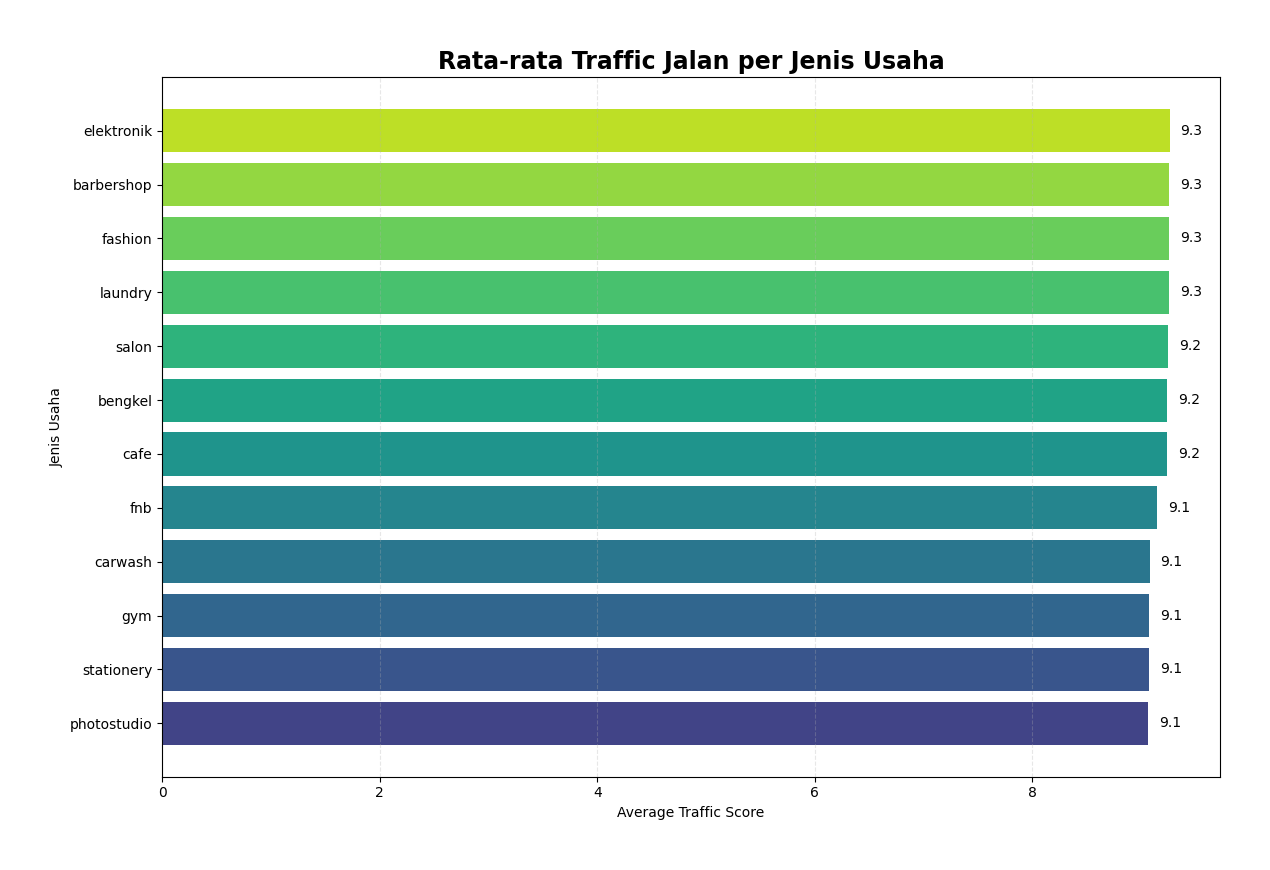

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

usaha_list = [
    'cafe', 'fnb', 'laundry', 'gym',
    'fashion', 'stationery',
    'carwash', 'photostudio',
    'barbershop', 'salon',
    'bengkel', 'elektronik'
]

rows = []

# =====================================
# HITUNG TRAFFIC
# =====================================
for usaha in usaha_list:

    temp = df_fe[
        df_fe[f'competitor_{usaha}'] > 0
    ]

    avg_traffic = temp[
        'traffic_score'
    ].mean()

    median_traffic = temp[
        'traffic_score'
    ].median()

    rows.append({
        'usaha': usaha,
        'avg_traffic': avg_traffic,
        'median_traffic': median_traffic
    })

traffic_business_df = pd.DataFrame(rows)

# SORT
traffic_business_df = (
    traffic_business_df
    .sort_values(
        'avg_traffic',
        ascending=True
    )
)

# =====================================
# COLOR MAPPING
# =====================================
colors = plt.cm.viridis(
    np.linspace(
        0.2,
        0.9,
        len(traffic_business_df)
    )
)

# =====================================
# PLOT
# =====================================
plt.figure(figsize=(12,8))

bars = plt.barh(
    traffic_business_df['usaha'],
    traffic_business_df['avg_traffic'],
    color=colors
)

# VALUE LABEL
for bar in bars:

    width = bar.get_width()

    plt.text(
        width + 0.1,
        bar.get_y() + bar.get_height()/2,
        f'{width:.1f}',
        va='center'
    )

plt.title(
    'Rata-rata Traffic Jalan per Jenis Usaha',
    fontsize=17,
    fontweight='bold'
)

plt.xlabel(
    'Average Traffic Score'
)

plt.ylabel(
    'Jenis Usaha'
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
plt.show()

``Insights``

- Beberapa jenis usaha secara konsisten berada pada ruas jalan dengan traffic_score tinggi, menunjukkan ketergantungan yang besar terhadap mobilitas kendaraan.
- Bengkel, Carwash, dan Elektronik cenderung berlokasi pada koridor jalan dengan kapasitas akses yang tinggi.
- Cafe dan FNB juga menunjukkan hubungan yang cukup kuat dengan traffic_score karena membutuhkan eksposur dan aksesibilitas yang baik.
- Laundry, Stationery, dan Photostudio relatif dapat bertahan pada ruas jalan dengan traffic sedang karena lebih bergantung pada demand lokal dibanding arus kendaraan.
- Hasil ini menunjukkan bahwa setiap jenis usaha memiliki kebutuhan karakteristik lokasi yang berbeda.

``Key Takeaways``

- Bengkel, Carwash, dan Elektronik lebih cocok ditempatkan pada ruas jalan dengan traffic tinggi.
- Laundry dan Stationery dapat berkembang pada kawasan dengan mobilitas sedang selama demand lokal mencukupi.
- Traffic score dapat digunakan sebagai faktor pembobot dalam sistem rekomendasi lokasi usaha.
- Analisis ini mendukung pendekatan rekomendasi yang lebih spesifik untuk setiap kategori bisnis dibanding menggunakan satu kriteria lokasi yang sama.

#**KESIMPULAN**

Pada notebook ini dilakukan serangkaian proses mulai dari ekstraksi data, transformasi dan pembersihan data, pengayaan informasi spasial, hingga feature engineering untuk membangun representasi yang lebih informatif terhadap potensi suatu lokasi. Data jalan yang berasal dari berbagai sumber diintegrasikan dengan informasi fasilitas, transportasi, dan aktivitas wilayah di sekitarnya sehingga menghasilkan fitur-fitur yang mampu merepresentasikan aksesibilitas, karakteristik lingkungan, potensi permintaan, serta tingkat persaingan usaha. Melalui proses tersebut, data spasial mentah berhasil ditransformasikan menjadi dataset yang lebih terstruktur dan siap dimanfaatkan pada tahap pemodelan AI untuk mendukung sistem rekomendasi lokasi usaha pada WIRA.